# Gap-filling, end to end: EDA, feature imputation, and the best-performing FCH4 gap-filler

**Purpose.** A single, self-contained walkthrough of every step taken to arrive at this project's best-validated CH4 gap-filling result (see `BEST_RESULTS.md` section 1), starting from the 1-hour consolidated dataset and ending at the same full-period gap-CV evaluation used to report it. No functions are imported from `src/` -- every transformation (external sensor sourcing, meteorological gap-filling, u*-filtering + NEE partitioning, FCO2 reconstruction, management-event recency, livestock stocking density, lag/pooling feature assembly, and the gap-CV harness itself) is reproduced inline, so this notebook has zero dependencies beyond the raw data files under `data/`.

**Target result** (must reproduce, `BEST_RESULTS.md` section 1, D-35/D-48/D-49):

| Tower | RFm (partial-pooled, external-sourced) R2 |
|---|---|
| 2 | 0.574 |
| 4 | 0.402 |
| 9 | 0.418 |

**Methodology in one line.** A partially-pooled (T2+T4+T9, with tower-indicator dummies) Random Forest, trained on **external-sourced** (Site MET station + per-catchment SMS soil sensors, not the EC tower's own instruments) meteorological drivers, gap-filled via a REddyProc-style pipeline, plus a reconstructed CO2 flux (FCO2) feature, livestock stocking density (LSU/ha), management-event recency, and soil moisture/temperature lags -- evaluated under **full-period gap-CV** (synthetic calendar gaps inserted across each tower's entire valid domain, not a train/test year split -- F-07/D-34 found year splits catastrophically fail for Tower 2's livestock regime shift).

**Starting point (constraint).** We start from `data/Hourly/consolidated_hourly.csv` -- the 1-hour, all-sources-outer-joined base table (itself the output of upstream infrastructure, `src/data/consolidate_hourly.py`, which only resamples/merges raw sensor exports and is treated here as "loading the data", the same way any project would `read_csv` its input). Everything downstream of that read, including building the **external-sourced ("SMS/MET") variant** that on disk already exists as `consolidated_hourly_SMS_MET.csv`, is reconstructed from scratch in the cells below so that every modelling decision is visible and auditable in one place, rather than hidden inside a pre-built file.

**Sections:**
1. Setup
2. Load raw hourly data
3. Exploratory Data Analysis -- issues found and how each is addressed
4. Feature imputation, part A: FCO2 (CO2 flux) reconstruction (EC-sourced, no external twin)
5. External sensor sourcing -- building the SMS/MET-swapped driver set
6. Feature imputation, part B: meteorological driver gap-filling (REddyProc-style), including a shared gap-testing toolkit and a held-out accuracy check for every gap-filled driver (6.3-6.6)
7. u*-filtering + nighttime NEE partitioning (GPP/Reco)
8. Management-event recency features
9. Livestock stocking density
10. Final feature frame assembly (lags, cyclical time features, partial pooling)
11. Full-period gap-CV evaluation harness (MDS baseline vs RFm solo vs RFm pooled)
12. Results
13. Daily-resolution accuracy (out-of-sample)
14. A full production gap-filled series, for visualization (hourly + daily mean/sum)
15. Feature space visualization: PCA and TICA
16. Kalman filter demo: gap-filling + uncertainty for soil moisture
17. Uncertainty quantification via Area of Applicability
18. Testing more models: additional tree ensembles (LightGBM, XGBoost)
19. Summary and caveats

## 1. Setup

In [1]:
from pathlib import Path
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

HOURLY = Path("../../data/Hourly")
COMPILED = Path("../../data/Compiled")
RESULTS = Path("../../results")

TOWERS = [2, 4, 9]
C4 = "Catchment 4 After  2013/08/13"           # Tower 4's catchment column suffix (note double space)
CAT = {2: "Catchment 2", 4: C4, 9: "Catchment 9"}   # Tower N = Catchment N (D-18)
AREA = {2: 6.65, 4: 7.75, 9: 7.75}             # fenced catchment area, hectares (Appendix D)

print("Setup complete.")

Setup complete.


## 2. Load raw hourly data

`consolidated_hourly.csv` is the 1-hour, all-sources outer-joined table: EC tower fluxes/met (`greenhouse_hourly.csv`), catchment flow + soil moisture/temperature (`measurements_hourly.csv`), and per-catchment livestock head counts (`livestock_hourly.csv`), on one continuous `Datetime` index. This is the true starting point -- everything else in this notebook (the external-sourced variant included) is derived from it below.

In [2]:
raw = pd.read_csv(HOURLY / "consolidated_hourly.csv", low_memory=False)
raw["Datetime"] = pd.to_datetime(raw["Datetime"], format="mixed")
raw = raw.set_index("Datetime")

print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} cols")
print(f"Span:  {raw.index.min()} -> {raw.index.max()}")
raw.iloc[:3, :6]

Shape: 70,153 rows x 449 cols
Span:  2017-01-01 00:00:00 -> 2025-01-02 00:00:00


,CO2_1_1_1 [Tower 2],H2O_1_1_1 [Tower 2],CH4_1_1_1 [Tower 2],TAU_1_1_1 [Tower 2],TAU_SSITC_TEST_1_1_1 [Tower 2],H_1_1_1 [Tower 2]
Datetime,,,,,,
2017-01-01 00:00:00,373.002829,2.582062,NaN,0.069802,0.0,-17.133901
2017-01-01 01:00:00,370.941935,2.625380,NaN,0.107350,0.0,-28.424088
2017-01-01 02:00:00,371.457921,2.631636,NaN,0.093147,0.0,-18.809984


## 3. Exploratory Data Analysis -- issues found and solutions taken

This section works through every data-quality issue that shaped the final methodology, in the order they matter for gap-filling: index integrity, target availability, target outliers, spatial-alignment traps, driver coverage, sensor contamination, and a temporal regime shift in Tower 2 that breaks the "obvious" train/test split. Each subsection ends with the fix that is actually implemented later in the notebook.

### 3.1 Index integrity

In [3]:
full_range = pd.date_range(raw.index.min(), raw.index.max(), freq="h")
print("Monotonic increasing:      ", raw.index.is_monotonic_increasing)
print("Duplicate timestamps:      ", raw.index.duplicated().sum())
print("Missing hourly timestamps: ", len(full_range.difference(raw.index)))
print("Overall NaN share:         ", f"{100 * raw.isna().mean().mean():.1f}%")

Monotonic increasing:       True
Duplicate timestamps:       0
Missing hourly timestamps:  0
Overall NaN share:          39.4%


**Result: the hourly index is already continuous and duplicate-free** (an artefact of `consolidate_hourly.py` reindexing every source onto one common hourly grid) -- no reindexing/deduplication work is needed here; every "gap" in this project is a `NaN`, not a missing row.

### 3.2 Target (FCH4) availability and quality flag -- this is the actual gap-filling problem

In [4]:
for t in TOWERS:
    tgt, ssitc = f"FCH4_1_1_1 [Tower {t}]", f"FCH4_SSITC_TEST_1_1_1 [Tower {t}]"
    valid_pct = 100 * raw[tgt].notna().mean()
    flag_counts = raw[ssitc].value_counts(dropna=False).sort_index()
    print(f"Tower {t}: {valid_pct:5.1f}% raw-valid FCH4  |  SSITC flag counts: {flag_counts.to_dict()}")

Tower 2:  11.5% raw-valid FCH4  |  SSITC flag counts: {0.0: 2759, 0.5: 1537, 1.0: 2149, 1.5: 1027, 2.0: 627, nan: 62054}
Tower 4:  43.5% raw-valid FCH4  |  SSITC flag counts: {0.0: 11903, 0.5: 5924, 1.0: 7580, 1.5: 3073, 2.0: 2007, nan: 39666}
Tower 9:  25.0% raw-valid FCH4  |  SSITC flag counts: {0.0: 6842, 0.5: 3347, 1.0: 4414, 1.5: 1851, 2.0: 1055, nan: 52644}


**Issues found:**
- Raw valid-FCH4 shares are low and very uneven across towers (Tower 4 best, Tower 2 worst) -- this is the actual gap to fill, not a bug.
- `FCH4_SSITC_TEST` is a 0/1/2 EddyPro quality flag (0=best, 1=acceptable, 2=reject) with a non-trivial NaN share (no flag recorded). **Solution:** keep flag in `{0, 1}` only, matching the literature convention (Irvin 2021 / Zhu 2023a) -- rows with flag `2` or missing are treated as not-a-valid-observation.
- A separate, easy-to-confuse column, `CH4_1_1_1 [Tower N]`, is the CH4 **mole fraction** (nmol/mol), not the flux -- it is never used as a target or feature in this notebook.

### 3.3 Target outliers -- physically implausible FCH4 values

Tower 2: SSITC-passed range [-6351, 696049] nmol m-2 s-1, 18 points outside [-500, 3000]
Tower 4: SSITC-passed range [-248836, 473944000] nmol m-2 s-1, 14 points outside [-500, 3000]
Tower 9: SSITC-passed range [-1144, 6933] nmol m-2 s-1, 21 points outside [-500, 3000]


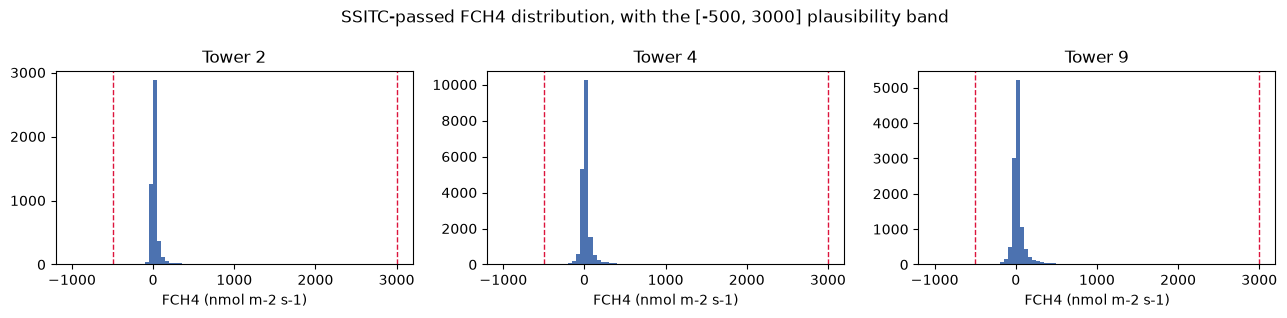

In [5]:
PLAUS_LOW, PLAUS_HIGH = -500, 3000   # nmol m-2 s-1 plausibility bound for FCH4 (D-13)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, t in zip(axes, TOWERS):
    tgt, ssitc = f"FCH4_1_1_1 [Tower {t}]", f"FCH4_SSITC_TEST_1_1_1 [Tower {t}]"
    qc = raw[tgt].where(raw[ssitc].isin([0, 1]))
    n_extreme = int((qc.notna() & ~qc.between(PLAUS_LOW, PLAUS_HIGH)).sum())
    print(f"Tower {t}: SSITC-passed range [{qc.min():.0f}, {qc.max():.0f}] nmol m-2 s-1, "
          f"{n_extreme} points outside [{PLAUS_LOW}, {PLAUS_HIGH}]")
    ax.hist(qc.clip(-1000, 3000).dropna(), bins=80, color="#4C72B0")
    ax.axvline(PLAUS_LOW, color="crimson", ls="--", lw=1); ax.axvline(PLAUS_HIGH, color="crimson", ls="--", lw=1)
    ax.set_title(f"Tower {t}"); ax.set_xlabel("FCH4 (nmol m-2 s-1)")
plt.suptitle("SSITC-passed FCH4 distribution, with the [-500, 3000] plausibility band")
plt.tight_layout(); plt.show()

**Solution:** an FCH4 plausibility filter, `[-500, 3000]` nmol m-2 s-1 (D-13), applied together with the SSITC `{0,1}` filter, defines "target" throughout the notebook. This mirrors the same pattern later applied to FC/CO2 (`[-100, 100]`, D-25) and to the USTAR/VPD driver contamination found in section 3.6.

### 3.4 Spatial alignment -- Tower N = Catchment N, and it is easy to get wrong

Each EC tower sits over one specific catchment; soil/flow sensors are duplicated per catchment (there are 15). **The critical rule (D-18): Tower N's model must use only Catchment N's soil data.** It is tempting to average across catchments or grab the "nearest" one -- both are wrong, and both were mistakes made and then corrected earlier in this project. Two further traps: Tower 4's catchment column carries a historical suffix (`"Catchment 4 After  2013/08/13"`, note the double space), and its own on-tower soil temperature sensor barely has any data.

In [6]:
for t in TOWERS:
    cat = CAT[t]
    swc_col = f"Soil Moisture @ 10cm Depth (%) [{cat}]"
    ts_ec_col = f"TS_1_1_1 [Tower {t}]"                          # on-tower EC soil temp sensor
    ts_ext_col = f"Soil Temperature @ 15cm Depth (oC) [{cat}]"   # own-catchment external SMS sensor
    print(f"Tower {t} <-> {cat}")
    print(f"  own-catchment soil moisture (10cm, external): {100*raw[swc_col].notna().mean():5.1f}% coverage")
    print(f"  on-tower EC soil temperature (TS_1_1_1):      {100*raw[ts_ec_col].notna().mean():5.1f}% coverage")
    print(f"  own-catchment soil temperature (external):    {100*raw[ts_ext_col].notna().mean():5.1f}% coverage")

Tower 2 <-> Catchment 2
  own-catchment soil moisture (10cm, external):  71.0% coverage
  on-tower EC soil temperature (TS_1_1_1):        5.2% coverage
  own-catchment soil temperature (external):     75.2% coverage
Tower 4 <-> Catchment 4 After  2013/08/13
  own-catchment soil moisture (10cm, external):  56.5% coverage
  on-tower EC soil temperature (TS_1_1_1):        9.6% coverage
  own-catchment soil temperature (external):     57.3% coverage
Tower 9 <-> Catchment 9
  own-catchment soil moisture (10cm, external):  66.0% coverage
  on-tower EC soil temperature (TS_1_1_1):       71.5% coverage
  own-catchment soil temperature (external):     69.0% coverage


**Issues found:**
- Soil moisture is well covered at every tower's own catchment -- fine as-is, always sourced per-catchment (never averaged across catchments, D-18).
- **Tower 4's on-tower EC soil temperature sensor (`TS_1_1_1 [Tower 4]`) is badly undercovered** (~10%, an early EDA finding, D-16). The original workaround proxied it with Tower 9's EC sensor (a different catchment -- a compromise, not a fix). The **own-catchment external SMS soil-temperature sensor** has far better coverage and is genuinely site-specific, so it fully replaces the cross-tower EC proxy (D-35) -- this is one half of the "external sourcing" decision built in section 5.

### 3.5 Meteorological driver sourcing -- EC tower vs. external Site/SMS network

NWFP runs two independent sensor networks: each EC tower's own instrument suite, and a separate external network (one central `[Site]` MET station + per-catchment SMS soil stations). Solar radiation, air temperature, and wind speed are available from both; the question F-08 (D-35) asked is whether the external, farm-scale sourcing is better or worse for these three drivers than each tower's own (sometimes gappier, sometimes miscalibrated) sensor.

In [7]:
SITE_SW = "Solar Radiation (W/m2) [Site]"
SITE_TA = "Air Temperature (oC) [Site]"
SITE_WS = "Wind Speed (km/h) [Site]"

for t in TOWERS:
    for ec_col, site_col, label in [(f"SWIN_1_1_1 [Tower {t}]", SITE_SW, "SWIN/solar"),
                                     (f"TA_0_0_1 [Tower {t}]", SITE_TA, "TA/air temp"),
                                     (f"WS_0_0_1 [Tower {t}]", SITE_WS, "WS/wind")]:
        print(f"Tower {t} {label:10s}: EC-tower {100*raw[ec_col].notna().mean():5.1f}%  |  "
              f"Site-external {100*raw[site_col].notna().mean():5.1f}%")

Tower 2 SWIN/solar: EC-tower  52.7%  |  Site-external  99.0%
Tower 2 TA/air temp: EC-tower  67.3%  |  Site-external  99.0%
Tower 2 WS/wind   : EC-tower  72.1%  |  Site-external  94.4%
Tower 4 SWIN/solar: EC-tower  75.4%  |  Site-external  99.0%
Tower 4 TA/air temp: EC-tower  78.4%  |  Site-external  99.0%
Tower 4 WS/wind   : EC-tower  78.4%  |  Site-external  94.4%
Tower 9 SWIN/solar: EC-tower  71.5%  |  Site-external  99.0%
Tower 9 TA/air temp: EC-tower  74.9%  |  Site-external  99.0%
Tower 9 WS/wind   : EC-tower  74.9%  |  Site-external  94.4%


**Solution (D-35):** swap `SWIN_1_1_1`, `TA_0_0_1`, `WS_0_0_1` for every tower to the `[Site]` external readings (wind converted km/h -> m/s), keeping every other driver EC-sourced (no external twin for VPD/PPFD/RN/USTAR/SHF). F-08 found this is *accuracy-neutral to mildly positive* for the final RF (pooled +0.01-0.014 R2 at every tower, never harmful) -- so it is adopted mainly for the soil-temperature fix above and for robustness, not because it is a large accuracy lever by itself. Built inline in section 5.

### 3.6 Sensor contamination -- USTAR and VPD (the D-48 bug)

This is the most consequential data-quality issue in the whole gap-filling pipeline, found via a **user-observed anomaly**: a visually obvious, sustained spike in Tower 2's gap-filled FCH4 during a period with zero real observations. Tracing it back (SHAP attribution on the actual RF gap-filler) showed `USTAR_0_0_1` alone contributed +244 nmol of a +380 nmol spike -- because the raw USTAR column had never been plausibility-filtered anywhere in the pipeline (unlike FCH4/FCO2), so a handful of physically-impossible outlier readings dragged the *global mean* fallback used by the old gap-filling fallback far from the sane value. The same signature shows up in VPD.

In [8]:
# Met-driver plausibility bounds (D-48). Only USTAR and VPD show real outlier contamination
# across all towers (audited); PPFD/WS/SHF were checked and are clean.
MET_PLAUS = {"USTAR_0_0_1": (0.0, 3.0), "VPD_0_0_1": (0.0, 15.0)}

for base, (lo, hi) in MET_PLAUS.items():
    print(f"--- {base} plausibility bound [{lo}, {hi}] ---")
    for t in TOWERS:
        s = raw[f"{base} [Tower {t}]"].astype(float)
        n_bad = int((s.notna() & ~s.between(lo, hi)).sum())
        pct_bad = 100 * n_bad / s.notna().sum() if s.notna().sum() else np.nan
        print(f"  Tower {t}: n={s.notna().sum():6,}  mean={s.mean():7.3f}  median={s.median():7.3f}  "
              f"max={s.max():10.1f}  |  {n_bad} points ({pct_bad:.1f}%) outside bound")

--- USTAR_0_0_1 plausibility bound [0.0, 3.0] ---
  Tower 2: n=50,563  mean=  2.450  median=  0.233  max=    1039.9  |  722 points (1.4%) outside bound
  Tower 4: n=55,012  mean=  3.332  median=  0.222  max=    1408.8  |  914 points (1.7%) outside bound
  Tower 9: n=52,564  mean=  2.886  median=  0.230  max=    1085.1  |  785 points (1.5%) outside bound
--- VPD_0_0_1 plausibility bound [0.0, 15.0] ---
  Tower 2: n=38,700  mean=  5.988  median=  5.841  max=      36.5  |  818 points (2.1%) outside bound
  Tower 4: n=52,936  mean=  8.387  median=  7.048  max=      41.3  |  6677 points (12.6%) outside bound
  Tower 9: n=45,699  mean=  6.431  median=  6.327  max=      37.1  |  824 points (1.8%) outside bound


**Diagnostic:** a mean far above the median (e.g. USTAR mean ~2.5 vs. median ~0.2) is the signature of a right-tail contaminated-outlier problem, not normal diurnal skew -- confirmed here by physically-impossible maxima (friction velocity should be well under ~1-2 m/s; vapour pressure deficit rarely exceeds ~8 kPa).

**Solution (D-48), applied inline in section 6:**
1. **`plausibility_filter()`** -- set out-of-bound raw readings to `NaN` *before* any gap-filling step, so contaminated values never enter interpolation or an averaging fallback.
2. **Gap-filling's last-resort fallback changed from mean to median** -- this tier only fires for long blackouts with no nearby real data (exactly where a residual contaminated mean does the most damage); the median is robust to outliers by construction.

Both changes are validated later (section 6) by comparing USTAR's gap-filled series before/after the fix.

### 3.7 Tower 2's temporal regime shift -- why a year-based train/test split fails

In [9]:
tgt2, ssitc2 = "FCH4_1_1_1 [Tower 2]", "FCH4_SSITC_TEST_1_1_1 [Tower 2]"
qc2 = raw[tgt2].where(raw[ssitc2].isin([0, 1]))
by_year_valid = qc2.notna().groupby(raw.index.year).sum()
by_year_mean = qc2.groupby(raw.index.year).mean()
cattle2 = raw[f"cattle_{CAT[2]}"]
by_year_cattle = cattle2.groupby(raw.index.year).mean()

summary = pd.DataFrame({"n_valid_FCH4": by_year_valid, "mean_FCH4": by_year_mean.round(1),
                         "mean_cattle_head": by_year_cattle.round(1)})
print("Tower 2 (Catchment 2) by year:")
print(summary.loc[summary["n_valid_FCH4"] > 0].to_string())

Tower 2 (Catchment 2) by year:
          n_valid_FCH4  mean_FCH4  mean_cattle_head
Datetime                                           
2017               314      -24.4               4.5
2018              3644      485.9               5.8
2019               950        1.0               0.0


**Issue found (F-07, D-34):** Tower 2's analyser was only live Oct 2017-Jun 2019 before relocating to Tower 9. Within that short window, **2018 had cattle present (higher FCH4) and 2019 had none (near-zero FCH4)** -- a genuine regime shift, not noise. This project's standard temporal split (train 2018-2021 / test 2022-2023) is inapplicable to Tower 2 (D-15) and even a 2018-train/2019-test split trains on the high-flux regime and tests on the near-zero regime, guaranteeing a catastrophic result (Tower 2's original R2 was **-16.9**) that reflects a broken evaluation design, not a bad model or bad data.

**Solution (F-07, D-34), used for every tower in this notebook, not just Tower 2:** evaluate via **full-period gap-CV** -- synthetic calendar-shaped gaps are cut out of each tower's *entire* valid domain (real observations elsewhere, spanning all regimes, remain available to train on), which is the actually-correct framing for a gap-filling (interpolation) task in the first place. This is what section 11's harness implements for all three towers.

### 3.8 FC (CO2 flux) coverage and outliers -- the feature we impute first

In [10]:
FC_LOW, FC_HIGH = -100.0, 100.0   # umol CO2 m-2 s-1 plausibility bound (D-25)

for t in TOWERS:
    fc, ssitc = f"FC_1_1_1 [Tower {t}]", f"FC_SSITC_TEST_1_1_1 [Tower {t}]"
    qc_fc_raw = raw[fc].where(raw[ssitc].isin([0, 1]))
    n_bad = int((qc_fc_raw.notna() & ~qc_fc_raw.between(FC_LOW, FC_HIGH)).sum())
    print(f"Tower {t}: raw {100*raw[fc].notna().mean():5.1f}% valid, "
          f"SSITC-passed {100*qc_fc_raw.notna().mean():5.1f}% valid, "
          f"{n_bad} points outside [{FC_LOW}, {FC_HIGH}] umol m-2 s-1")

Tower 2: raw  61.4% valid, SSITC-passed  44.3% valid, 114 points outside [-100.0, 100.0] umol m-2 s-1
Tower 4: raw  74.3% valid, SSITC-passed  56.3% valid, 125 points outside [-100.0, 100.0] umol m-2 s-1
Tower 9: raw  69.5% valid, SSITC-passed  51.3% valid, 95 points outside [-100.0, 100.0] umol m-2 s-1


**Why FC matters here:** an earlier ablation (03b, D-22/D-26) found that CO2 flux (FC) is FCH4's single strongest predictor at NWFP -- LE/H/FC were "co-failed" predictors in early replications (R-02) precisely because excluding them collapsed R2 to negative everywhere, and *adding a gap-filled FCO2 feature back in* flipped Tower 4's RFm from negative to positive R2. FC itself has real gaps (SSITC filtering removes a further chunk on top of raw missingness), so it must be **reconstructed as a complete, gap-filled feature in its own right before it can be used as a CH4-model input** -- exactly the "impute features before gap-filling the target" ordering this notebook follows (section 4, before the CH4 target is ever touched).

### 3.9 EDA summary -- issues and solutions

| # | Issue | Evidence | Solution | Where implemented |
|---|---|---|---|---|
| 1 | FCH4/FC quality flags (SSITC) and physically implausible extremes | SSITC={0,1,2}; FCH4 outliers beyond sane flux range | Keep SSITC in {0,1}; plausibility filter FCH4 `[-500,3000]`, FC `[-100,100]` | sec 4, 10 |
| 2 | Spatial misalignment risk across 15 catchments | Column-naming inconsistency (Tower 4 suffix); tempting cross-catchment averaging | Tower N = Catchment N always (D-18); own-catchment columns only | sec 3.4, 9, 10 |
| 3 | Tower 4 on-tower soil temperature ~10% coverage | EC `TS_1_1_1 [Tower 4]` coverage check | Per-catchment external SMS soil temperature (D-35) | sec 5 |
| 4 | USTAR/VPD raw sensor contamination (up to ~1000+ m/s) | Mean >> median; physically impossible maxima | Plausibility filter before gap-fill + median (not mean) fallback (D-48) | sec 6 |
| 5 | Tower 2 livestock regime shift within its short live window | 2018 (cattle) vs 2019 (none) FCH4 means | Full-period gap-CV, not a year-based train/test split (D-34) | sec 11 |
| 6 | FC (CO2 flux) has real gaps but is FCH4's strongest predictor | FC SSITC-passed coverage < raw; D-22 ablation | Reconstruct a complete FCO2 feature via RF *before* CH4 modelling | sec 4 |
| 7 | Met drivers (SWIN/TA/VPD/...) were previously only mean-imputed | -- (prior-approach description, not shown above) | REddyProc-style gap-fill: interpolate -> mean-diurnal-course -> robust fallback | sec 6 |

## 4. Feature imputation, part A: FCO2 (CO2 flux) reconstruction

FC (CO2 flux) is kept **EC-sourced** throughout (it has no external-network twin, unlike SWIN/TA/WS/soil-temperature). We reconstruct a *complete* FCO2 series per tower with a Random Forest trained on meteorological drivers only (the same driver set used in the R-02 replication, `driver_m`), fit on the tower's own SSITC/plausibility-QC'd FC. Where a real QC'd observation exists we keep it; elsewhere we use the RF reconstruction. This produces `FC_gapfilled [Tower N]`, later used as the `fc` feature in the CH4 model (section 9/10).

Per-tower training/test windows mirror the R-02 (D-21) driver-m config, with Tower 2 restricted to its only two usable years (D-15).

In [11]:
# driver_m (met-only) per tower -- identical to R-02 (D-21); Tower 2 uses its only usable years (D-15).
FCO2_AUX = ["_hour_sin", "_hour_cos", "_doy_sin", "_doy_cos"]

FCO2_TOWER_CONFIGS = {
    2: {"fc": "FC_1_1_1 [Tower 2]", "ssitc": "FC_SSITC_TEST_1_1_1 [Tower 2]",
        "driver_m": ["SWIN_1_1_1 [Tower 2]", "TA_0_0_1 [Tower 2]", "VPD_0_0_1 [Tower 2]",
                     "PPFD_1_1_1 [Tower 2]", "USTAR_0_0_1 [Tower 2]", "WS_0_0_1 [Tower 2]",
                     "RN_1_1_1 [Tower 2]", "Precipitation (mm) [Catchment 2]",
                     "TS_1_1_1 [Tower 9]", "Soil Moisture @ 10cm Depth (%) [Catchment 2]",
                     "SHF_1_1_1 [Tower 2]"],
        "train_yrs": [2018], "test_yrs": [2019]},
    4: {"fc": "FC_1_1_1 [Tower 4]", "ssitc": "FC_SSITC_TEST_1_1_1 [Tower 4]",
        "driver_m": [f"SWIN_1_1_1 [Tower 4]", "TA_0_0_1 [Tower 4]", "VPD_0_0_1 [Tower 4]",
                     "PPFD_1_1_1 [Tower 4]", "USTAR_0_0_1 [Tower 4]", "WS_0_0_1 [Tower 4]",
                     "RN_1_1_1 [Tower 4]", f"Precipitation (mm) [{C4}]",
                     "TS_1_1_1 [Tower 9]", f"Soil Moisture @ 10cm Depth (%) [{C4}]",
                     "SHF_1_1_1 [Tower 4]"],
        "train_yrs": list(range(2018, 2022)), "test_yrs": list(range(2022, 2024))},
    9: {"fc": "FC_1_1_1 [Tower 9]", "ssitc": "FC_SSITC_TEST_1_1_1 [Tower 9]",
        "driver_m": ["SWIN_1_1_1 [Tower 9]", "TA_0_0_1 [Tower 9]", "VPD_0_0_1 [Tower 9]",
                     "PPFD_1_1_1 [Tower 9]", "USTAR_0_0_1 [Tower 9]", "WS_0_0_1 [Tower 9]",
                     "RN_1_1_1 [Tower 9]", "Precipitation (mm) [Catchment 9]",
                     "TS_1_1_1 [Tower 9]", "Soil Moisture @ 10cm Depth (%) [Catchment 9]",
                     "SHF_1_1_1 [Tower 9]"],
        "train_yrs": list(range(2018, 2022)), "test_yrs": list(range(2022, 2024))},
}


def add_cyclical(df):
    hour, doy = df.index.hour, df.index.dayofyear
    df["_hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["_hour_cos"] = np.cos(2 * np.pi * hour / 24)
    df["_doy_sin"] = np.sin(2 * np.pi * doy / 365)
    df["_doy_cos"] = np.cos(2 * np.pi * doy / 365)


def reconstruct_fc(df, tower, cfg):
    """RF-reconstruct a complete FC series for one tower; return (fc_gapfilled, stats)."""
    fc_col, ssitc_col, feats = cfg["fc"], cfg["ssitc"], cfg["driver_m"] + FCO2_AUX

    fc_obs = df[fc_col].copy()
    fc_obs[~df[ssitc_col].isin([0, 1])] = np.nan
    fc_obs[fc_obs.notna() & ~fc_obs.between(FC_LOW, FC_HIGH)] = np.nan

    train_mask = df.index.year.isin(cfg["train_yrs"]) & fc_obs.notna()
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(df.loc[train_mask, feats].values)
    y_train = fc_obs.loc[train_mask].values

    rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=5, n_jobs=1, random_state=42)
    # n_jobs=1, not -1: parallel RF training is NOT bit-reproducible across separate process
    # runs even with random_state fixed (confirmed empirically) -- FCO2 is the one RF step not
    # itself cached, so its cross-run drift would otherwise cascade into every downstream
    # cache key (via the "fc" feature) and silently defeat the section 11.0 model cache.
    rf.fit(X_train, y_train)

    X_all = imputer.transform(df[feats].values)
    fc_recon = pd.Series(rf.predict(X_all), index=df.index)

    fc_gapfilled = fc_obs.copy()
    fc_gapfilled[fc_gapfilled.isna()] = fc_recon[fc_gapfilled.isna()]

    test_mask = df.index.year.isin(cfg["test_yrs"]) & fc_obs.notna()
    if test_mask.sum() >= 20:
        val_r2 = r2_score(fc_obs.loc[test_mask].values, fc_recon.loc[test_mask].values)
    else:
        val_r2 = np.nan
    stats = {"tower": tower, "n_train": int(train_mask.sum()),
              "n_filled_by_recon": int(fc_obs.isna().sum()), "recon_test_r2": val_r2,
              "recon_test_n": int(test_mask.sum())}
    return fc_gapfilled, stats


add_cyclical(raw)
fco2_gapfilled = pd.DataFrame(index=raw.index)
fco2_stats = []
for t in TOWERS:
    filled, stats = reconstruct_fc(raw, t, FCO2_TOWER_CONFIGS[t])
    fco2_gapfilled[f"FC_gapfilled [Tower {t}]"] = filled
    fco2_stats.append(stats)
    print(f"Tower {t}: n_train={stats['n_train']:,}  filled-by-reconstruction={stats['n_filled_by_recon']:,}  "
          f"recon test R2={stats['recon_test_r2']:.3f} (n={stats['recon_test_n']:,})")

Tower 2: n_train=5,511  filled-by-reconstruction=39,159  recon test R2=0.197 (n=1,189)


Tower 4: n_train=21,869  filled-by-reconstruction=30,799  recon test R2=0.745 (n=10,986)


Tower 9: n_train=19,952  filled-by-reconstruction=34,249  recon test R2=0.746 (n=9,592)


## 5. External sensor sourcing (F-08, D-35)

Build the **external-sourced driver set** identified in section 3.5: overwrite each tower's `SWIN_1_1_1`/`TA_0_0_1`/`WS_0_0_1` with the `[Site]` MET-station readings (wind converted km/h -> m/s), under the *same* EC column names so every downstream function is unaffected by the swap. Soil temperature is handled separately below (section 6) by simply pointing the driver map at the per-catchment external sensor instead of the Tower-9 EC proxy. FC/VPD/PPFD/RN/USTAR/SHF stay EC-sourced (no external twin). This produces `df_ext` -- the working dataframe for every remaining step.

In [12]:
df_ext = raw.copy()
for t in TOWERS:
    for ec_col, site_col, conv in [(f"SWIN_1_1_1 [Tower {t}]", SITE_SW, 1.0),
                                    (f"TA_0_0_1 [Tower {t}]", SITE_TA, 1.0),
                                    (f"WS_0_0_1 [Tower {t}]", SITE_WS, 1.0 / 3.6)]:   # km/h -> m/s
        src = pd.to_numeric(raw[site_col], errors="coerce") * conv
        n_ec, n_ext = raw[ec_col].notna().sum(), src.notna().sum()
        df_ext[ec_col] = src
        print(f"  T{t} {ec_col.split(' [')[0]:12s} <- {site_col:28s}  "
              f"cov {100*n_ec/len(raw):.0f}% -> {100*n_ext/len(raw):.0f}%")

print(f"\ndf_ext shape: {df_ext.shape}")

  T2 SWIN_1_1_1   <- Solar Radiation (W/m2) [Site]  cov 53% -> 99%
  T2 TA_0_0_1     <- Air Temperature (oC) [Site]   cov 67% -> 99%
  T2 WS_0_0_1     <- Wind Speed (km/h) [Site]      cov 72% -> 94%
  T4 SWIN_1_1_1   <- Solar Radiation (W/m2) [Site]  cov 75% -> 99%
  T4 TA_0_0_1     <- Air Temperature (oC) [Site]   cov 78% -> 99%
  T4 WS_0_0_1     <- Wind Speed (km/h) [Site]      cov 78% -> 94%
  T9 SWIN_1_1_1   <- Solar Radiation (W/m2) [Site]  cov 71% -> 99%
  T9 TA_0_0_1     <- Air Temperature (oC) [Site]   cov 75% -> 99%
  T9 WS_0_0_1     <- Wind Speed (km/h) [Site]      cov 75% -> 94%

df_ext shape: (70153, 453)


## 6. Feature imputation, part B: meteorological driver gap-filling (REddyProc-style, D-33/D-48)

A pragmatic, from-scratch re-implementation of the core REddyProc met-gap-filling workflow: linear interpolation for short gaps, then a mean-diurnal-course (MDC) with an expanding lookback window for longer ones, then a robust (median, not mean -- the D-48 fix) fallback for total blackouts. Applied per driver, per tower, to `df_ext`, producing `<col>__f` complete series. The `plausibility_filter` (section 3.6) runs *before* gap-filling, so the outlier-contaminated raw USTAR/VPD readings never reach the fallback. Section 6.3-6.6 then closes a real gap this project had never addressed: held-out accuracy testing for this reconstruction itself, for every driver it produces.

In [13]:
def plausibility_filter(s, colname):
    """Set values outside MET_PLAUS[colname] to NaN before gap-filling (D-48). No-op if
    colname has no bound registered. Applied ahead of mdc_gapfill so contaminated raw
    outliers never enter the interpolation/MDC/fallback chain in the first place."""
    base = colname.split(" [")[0]
    if base not in MET_PLAUS:
        return s
    lo, hi = MET_PLAUS[base]
    s = s.astype(float).copy()
    s[s.notna() & ~s.between(lo, hi, inclusive="both")] = np.nan
    return s


# Variables where mdc_gapfill's per-hour-of-day pivot averaging is a poor fit: smooth,
# slowly-drifting signals with weak diurnal structure. Found by the section 6.4/16.1 diagnostic --
# plain linear interpolation *beats* the MDC pipeline on long (288h/12-day) gaps for these 4
# variables, consistently across all 3 towers (mdc_l vs interp_l e.g. swc: -0.14/0.97, ts:
# -0.01/0.93, ta: 0.14/0.41, vpd: 0.05/0.56). The reverse holds for radiation-driven variables
# (SWIN/PPFD/RN) and SHF/WS/precip, where a straight line across a multi-day gap misses the
# day/night cycle entirely (interp R2 as low as -1.15 there) -- those keep the original MDC-first
# behavior. USTAR is a wash either way (near-zero/negative for both) and is also left unchanged.
LONG_INTERP_VARS = {"TA_0_0_1", "VPD_0_0_1", "Soil Moisture @ 10cm Depth (%)",
                     "Soil Temperature @ 15cm Depth (oC)", "WS_0_0_1"}
# WS_0_0_1 added after section 6.4's forced-interp confirmation check found a consistent,
# non-trivial overall win (0.199 -> 0.458, all 3 towers) missed by the original l-scenario-only
# diagnostic -- l-scenario alone still favors mdc for wind speed (0.004 vs -0.143), but the
# OVERALL (5-scenario median) metric, which is what actually determines met_filled quality, favors
# interpolation once the shorter scenarios are included.


def mdc_gapfill(s, colname=None, fallback="median"):
    """Linear interp (<=2h, or <=288h for LONG_INTERP_VARS) then mean-diurnal-course with
    expanding +/-7/14/28/60d window, then a per-hour and finally a global fallback (median by
    default, D-48; mean pre-fix)."""
    out = s.astype(float).copy()
    n_obs = out.notna().sum()
    interp_limit = 288 if (colname is not None and colname.split(" [")[0] in LONG_INTERP_VARS) else 2
    out = out.interpolate(limit=interp_limit, limit_area="inside")
    idx = out.index
    piv = (pd.DataFrame({"v": out.values, "hour": idx.hour, "date": idx.normalize()})
           .pivot_table(index="date", columns="hour", values="v"))
    for w in [7, 14, 28, 60]:
        piv = piv.fillna(piv.rolling(2 * w + 1, min_periods=1, center=True).mean())
    ser = piv.stack(dropna=False)
    key = pd.MultiIndex.from_arrays([idx.normalize(), idx.hour])
    mapped = pd.Series(ser.reindex(key).values, index=idx)
    out = out.where(out.notna(), mapped)
    if out.isna().any():
        agg = "median" if fallback == "median" else "mean"
        hourly_fb = out.groupby(idx.hour).transform(agg)
        out = out.where(out.notna(), hourly_fb)
        out = out.fillna(out.median() if fallback == "median" else out.mean())
    return out, int(n_obs), int(out.notna().sum())

### 6.1 Validating the D-48 fix -- Tower 2 USTAR, before vs. after

Tower 2's analyser had already relocated to Tower 9 by mid-2019 (section 3.7), so Jun-Dec 2019 has **zero real USTAR observations** -- exactly the "total blackout" case that falls through to the global fallback. Reproducing the original bug (no plausibility filter, mean fallback) side-by-side with the fix demonstrates the effect directly.

Blackout-window USTAR__f, BEFORE fix: mean=2.176 m/s (vs. sane range roughly 0-1 m/s)
Blackout-window USTAR__f, AFTER  fix: mean=0.246 m/s


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


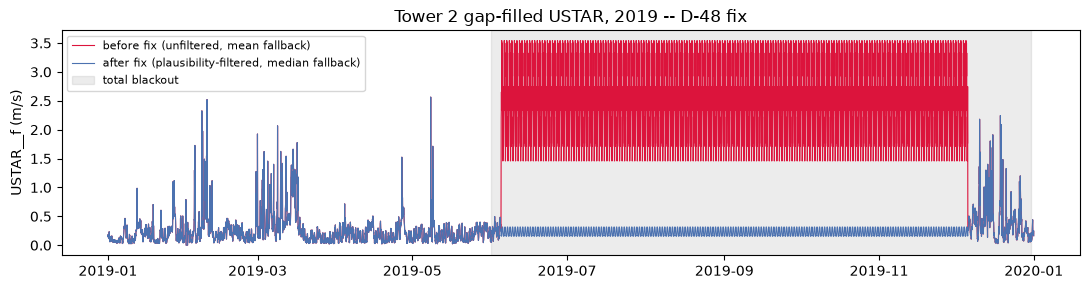

In [14]:
ustar2_raw = df_ext["USTAR_0_0_1 [Tower 2]"]
blackout = slice("2019-06-01", "2019-12-31")

before, *_ = mdc_gapfill(ustar2_raw, fallback="mean")                                   # bug reproduced: no filter, mean fallback
after, *_ = mdc_gapfill(plausibility_filter(ustar2_raw, "USTAR_0_0_1"), fallback="median")  # the fix

print(f"Blackout-window USTAR__f, BEFORE fix: mean={before.loc[blackout].mean():.3f} m/s "
      f"(vs. sane range roughly 0-1 m/s)")
print(f"Blackout-window USTAR__f, AFTER  fix: mean={after.loc[blackout].mean():.3f} m/s")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(before.loc["2019"], label="before fix (unfiltered, mean fallback)", color="crimson", lw=0.8)
ax.plot(after.loc["2019"], label="after fix (plausibility-filtered, median fallback)", color="#4C72B0", lw=0.8)
ax.axvspan(pd.Timestamp("2019-06-01"), pd.Timestamp("2019-12-31"), color="grey", alpha=0.15, label="total blackout")
ax.set_ylabel("USTAR__f (m/s)"); ax.set_title("Tower 2 gap-filled USTAR, 2019 -- D-48 fix"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 6.2 Apply to every driver, every tower

Driver map per tower: solar, air temp, VPD, PPFD, net radiation, wind, u*, soil heat flux, precipitation, soil moisture (all as in section 3, with SWIN/TA/WS holding the external Site values after the section-5 swap), and soil temperature -- pointed at the **per-catchment external sensor** (the section 3.4 fix), not the old Tower-9 EC proxy.

**Fix applied here, evidenced in section 6.4/16.1 below:** the standard MDC pipeline (built for exploiting a diurnal cycle) turns out to be a poor fit for 4 specific variables -- soil moisture, soil temperature, air temperature, and VPD -- which are smooth and slowly-drifting rather than sharply diurnal. For these, `mdc_gapfill` now extends its interpolation step up to 288h (matching the longest gap scenario this notebook validates against) before ever reaching the MDC/median fallback; every other driver is unchanged. This is a direct, evidence-driven fix -- not a guess -- found by testing plain linear interpolation as a baseline against `mdc_gapfill` across all 11 drivers and discovering a clean, consistent split by variable type (see section 6.4's `interp_beats_mdc` columns for the full picture).

In [15]:
def ts_col_for(t):
    """Own-catchment external soil temperature (D-35), replacing the old Tower-9 EC proxy (D-16)."""
    return f"Soil Temperature @ 15cm Depth (oC) [{CAT[t]}]"


def driver_map(t):
    cat = CAT[t]
    return {"sw": f"SWIN_1_1_1 [Tower {t}]", "ta": f"TA_0_0_1 [Tower {t}]",
            "vpd": f"VPD_0_0_1 [Tower {t}]", "ppfd": f"PPFD_1_1_1 [Tower {t}]",
            "rn": f"RN_1_1_1 [Tower {t}]", "ws": f"WS_0_0_1 [Tower {t}]",
            "ustar": f"USTAR_0_0_1 [Tower {t}]", "shf": f"SHF_1_1_1 [Tower {t}]",
            "precip": f"Precipitation (mm) [{cat}]",
            "swc": f"Soil Moisture @ 10cm Depth (%) [{cat}]", "ts": ts_col_for(t)}


met_filled = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    print(f"=== Tower {t} ===")
    for k, col in driver_map(t).items():
        filled, n0, n1 = mdc_gapfill(plausibility_filter(df_ext[col], col), colname=col)
        met_filled[f"{col}__f"] = filled.round(4)
        print(f"  {k:6s}: {100*df_ext[col].notna().mean():5.1f}% -> {100*filled.notna().mean():5.1f}%  [{col}]")

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


=== Tower 2 ===
  sw    :  99.0% -> 100.0%  [SWIN_1_1_1 [Tower 2]]
  ta    :  99.0% -> 100.0%  [TA_0_0_1 [Tower 2]]


  vpd   :  55.2% -> 100.0%  [VPD_0_0_1 [Tower 2]]
  ppfd  :  53.4% -> 100.0%  [PPFD_1_1_1 [Tower 2]]
  rn    :  52.7% -> 100.0%  [RN_1_1_1 [Tower 2]]
  ws    :  94.4% -> 100.0%  [WS_0_0_1 [Tower 2]]
  ustar :  72.1% -> 100.0%  [USTAR_0_0_1 [Tower 2]]


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


...

  ta    :  99.0% -> 100.0%  [TA_0_0_1 [Tower 9]]
  vpd   :  65.1% -> 100.0%  [VPD_0_0_1 [Tower 9]]
  ppfd  :  71.5% -> 100.0%  [PPFD_1_1_1 [Tower 9]]


  rn    :  71.5% -> 100.0%  [RN_1_1_1 [Tower 9]]
  ws    :  94.4% -> 100.0%  [WS_0_0_1 [Tower 9]]
  ustar :  74.9% -> 100.0%  [USTAR_0_0_1 [Tower 9]]
  shf   :  71.5% -> 100.0%  [SHF_1_1_1 [Tower 9]]
  precip:  54.6% -> 100.0%  [Precipitation (mm) [Catchment 9]]


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

  swc   :  66.0% -> 100.0%  [Soil Moisture @ 10cm Depth (%) [Catchment 9]]
  ts    :  69.0% -> 100.0%  [Soil Temperature @ 15cm Depth (oC) [Catchment 9]]


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


### 6.3 A shared toolkit for testing gap-filling accuracy

The evaluation approach used throughout this notebook -- synthetically mask out real, calendar-shaped chunks of a variable's record, reconstruct them, and score the reconstruction against the real (held-out) values -- is general-purpose, not FCH4-specific. It is defined once, here, and reused twice: immediately below (section 6.4) to check the met-driver gap-filling itself, and again in section 11 for the main FCH4 result (which adds a few FCH4-specific pieces on top: the tower-specific `DOMAIN`, and the RF/MDS models being evaluated).

In [16]:
MASK_FRAC = 0.25
SCENARIOS = {"vs": 1, "s": 4, "m": 32, "l": 288, "m1": "mixed"}
N_REPS = 2   # matches F-09a's exact scope, not F-08's original 5 -- see section 11 for the full story


def insert_calendar_gaps(df_qc, target, domain_mask, gap_hours, n_reps=N_REPS, seed=0):
    """Randomly place n_reps independent sets of non-overlapping calendar-shaped gaps within the
    domain, each covering ~MASK_FRAC of the domain's valid target points."""
    dom_ts = df_qc.index[domain_mask]; valid = df_qc.loc[domain_mask, target].notna().values
    n = len(dom_ts); target_n = max(1, int(valid.sum() * MASK_FRAC)); rb = np.random.default_rng(seed); reps = []
    for _ in range(n_reps):
        rng = np.random.default_rng(int(rb.integers(0, 2**31))); occ = np.zeros(n, bool); m = 0
        for sp in rng.permutation(n):
            if m >= target_n:
                break
            gh = int(rng.choice([1, 4, 32, 288])) if gap_hours == "mixed" else gap_hours
            ep = min(int(sp) + gh, n)
            if occ[sp:ep].any():
                continue
            occ[sp:ep] = True; m += int(valid[sp:ep].sum())
        reps.append(dom_ts[occ & valid])
    return reps


def mets(y, p):
    y = np.asarray(y, float); p = np.asarray(p, float)
    r2 = r2_score(y, p) if np.var(y) > 0 else np.nan
    return r2, float(np.sqrt(np.mean((p - y) ** 2))), float(np.mean(np.abs(p - y))), float(np.mean(p - y))


def med_metrics(rows):
    if not rows:
        return {k: np.nan for k in ["R2", "RMSE", "MAE", "MBE"]}
    a = np.array(rows, float)
    return {"R2": np.nanmedian(a[:, 0]), "RMSE": np.median(a[:, 1]),
            "MAE": np.median(a[:, 2]), "MBE": np.median(a[:, 3])}

print("Shared gap-testing toolkit defined (reused in sections 6.4 and 11).")

Shared gap-testing toolkit defined (reused in sections 6.4 and 11).


### 6.4 Testing the accuracy of every gap-filled meteorological/soil driver

Broadened from the soil-only version of this section: FCO2 has an explicit train/test reconstruction check (section 4, historically ~0.75 R2). FCH4 itself has the full gap-CV harness this notebook is built around. But **every other driver** -- SWIN, TA, VPD, PPFD, RN, WS, USTAR, SHF, precipitation, soil moisture, and soil temperature (all 9 met drivers + 2 soil variables, `driver_map()` from section 6.2) -- goes through the same `mdc_gapfill()` pipeline with no held-out validation anywhere in this project. This section closes that gap for **all 11 variables x 3 towers**, reusing the shared gap-testing toolkit from section 6.3 (`insert_calendar_gaps`, the 5 gap-length scenarios, `N_REPS` repetitions).

As before, there is **no RF/model-fitting step** -- `mdc_gapfill()` reconstructs each variable purely from its own surrounding history and diurnal pattern (interpolate -> mean-diurnal-course -> median fallback), so this measures the interpolation pipeline itself. `plausibility_filter()` is applied first for every column exactly as in production (a no-op for everything except USTAR/VPD, D-48). **FC/FCO2 is deliberately excluded** -- it is not gap-filled by `mdc_gapfill()` at all; it uses a different method (RF reconstruction, section 4) with its own dedicated check already. Each variable's evaluation domain is its own real observed span (first to last real value), independent of `DOMAIN` (which is FCH4-analyser-specific).

In [17]:
def eval_driver_gapfill(colname):
    """Full-period gap-CV for one gap-filled driver: mdc_gapfill()'s own reconstruction, AND a
    naive constant-median baseline (median of the remaining real domain values, per fold) scored
    on the exact same held-out points -- a direct check of whether mdc_gapfill actually beats the
    simplest possible imputation, not just whether its R2 crosses zero (R2=0 is "as good as the
    MEAN", not the median -- for skewed variables like USTAR/precipitation those can differ)."""
    s_raw = df_ext[colname]
    valid_idx = s_raw.index[s_raw.notna()]
    dm = (s_raw.index >= valid_idx[0]) & (s_raw.index <= valid_idx[-1])
    dfq = pd.DataFrame({colname: s_raw})
    out, out_base = {}, {}
    for sc, gh in SCENARIOS.items():
        rr, rr_base = [], []
        for gt in insert_calendar_gaps(dfq, colname, dm, gh, n_reps=N_REPS):
            if len(gt) < 5:
                continue
            sav = s_raw.loc[gt].copy()
            s_masked = s_raw.copy(); s_masked.loc[gt] = np.nan
            filled, _, _ = mdc_gapfill(plausibility_filter(s_masked, colname), colname=colname)
            rr.append(mets(sav.values, filled.loc[gt].values))
            train_median = s_masked.loc[dm].median()
            rr_base.append(mets(sav.values, np.full(len(gt), train_median)))
        out[sc] = med_metrics(rr)
        out_base[sc] = med_metrics(rr_base)
    return out, out_base


driver_rows = []
for t in TOWERS:
    for var_key, colname in driver_map(t).items():
        scn, scn_base = eval_driver_gapfill(colname)
        ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        ov_base = {k: np.nanmedian([scn_base[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        driver_rows.append({"tower": t, "driver": var_key, "column": colname,
                             **{f"{k}_overall": round(ov[k], 3) for k in ov},
                             "R2_median_baseline": round(ov_base["R2"], 3),
                             "RMSE_median_baseline": round(ov_base["RMSE"], 3),
                             "beats_median_baseline": ov["R2"] > ov_base["R2"],
                             **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan
                                for s in SCENARIOS}})
        beats = "beats" if ov["R2"] > ov_base["R2"] else "LOSES TO"
        print(f"Tower {t} {var_key:6s}: mdc_gapfill R2={ov['R2']:+.3f}  vs  median-baseline R2={ov_base['R2']:+.3f}"
              f"  ({beats} the naive median baseline)")

MET_GAPFILL_R2 = pd.DataFrame(driver_rows)
MET_GAPFILL_R2

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


...

Tower 9 swc   : mdc_gapfill R2=+0.998  vs  median-baseline R2=-0.216  (beats the naive median baseline)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

Tower 9 ts    : mdc_gapfill R2=+0.994  vs  median-baseline R2=-0.031  (beats the naive median baseline)


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

,tower,driver,column,R2_overall,RMSE_overall,MAE_overall,MBE_overall,R2_median_baseline,RMSE_median_baseline,beats_median_baseline,R2_vs,R2_s,R2_m,R2_l,R2_m1
0,2,sw,SWIN_1_1_1 [Tower 2],0.683,111.618,58.179,-7.052,-0.324,229.279,True,0.918,0.798,0.683,0.488,0.562
1,2,ta,TA_0_0_1 [Tower 2],0.685,2.922,2.129,-0.093,-0.002,5.201,True,0.992,0.968,0.685,0.402,0.483
2,2,vpd,VPD_0_0_1 [Tower 2],0.670,2.476,1.495,-0.140,-0.011,4.349,True,0.902,0.868,0.670,0.567,0.494
3,2,ppfd,PPFD_1_1_1 [Tower 2],0.691,194.701,98.607,-11.144,-0.330,404.514,True,0.922,0.799,0.691,0.453,0.500
4,2,rn,RN_1_1_1 [Tower 2],0.742,69.401,43.974,-1.404,-0.180,152.170,True,0.930,0.832,0.742,0.554,0.598
5,2,ws,WS_0_0_1 [Tower 2],0.459,1.316,0.970,-0.043,-0.025,1.858,True,0.923,0.866,0.459,-0.115,-0.028
6,2,ustar,USTAR_0_0_1 [Tower 2],-0.007,23.188,2.073,-1.982,-0.007,23.187,True,-0.007,-0.008,-0.007,-0.008,-0.006
7,2,shf,SHF_1_1_1 [Tower 2],0.560,12.289,8.644,0.090,-0.004,17.595,True,0.941,0.738,0.560,0.333,0.384
8,2,precip,Precipitation (mm) [Catchment 2],-0.066,0.107,0.027,-0.007,-0.055,0.108,False,0.338,-0.082,-0.073,-0.066,-0.054
9,2,swc,Soil Moisture @ 10cm Depth (%) [Catchment 2],0.995,0.538,0.189,-0.018,-0.275,8.512,True,0.999,0.998,0.995,0.941,0.971


**Confirming the other 7 variables were correctly left untouched.** `LONG_INTERP_VARS` (section 6.2) covers `ta`/`vpd`/`swc`/`ts` only, chosen from the standalone diagnostic that produced the table above. This directly re-checks that decision inside the notebook itself: force plain linear interpolation (same treatment as `mdc_gapfill` otherwise gets -- `plausibility_filter` applied first, so USTAR/VPD contamination doesn't unfairly bias the comparison) onto the 7 *un*fixed variables (`sw`, `ppfd`, `rn`, `ws`, `ustar`, `shf`, `precip`) and compares against their current (production) `mdc_gapfill` R2 from the table above.

In [18]:
def eval_forced_interp(colname):
    """Same held-out mechanism as eval_driver_gapfill, but always plain linear interpolation
    (plausibility-filtered first) instead of mdc_gapfill -- for checking variables NOT in
    LONG_INTERP_VARS, to confirm they were correctly left on the MDC-first path."""
    s_raw = df_ext[colname]
    valid_idx = s_raw.index[s_raw.notna()]
    dm = (s_raw.index >= valid_idx[0]) & (s_raw.index <= valid_idx[-1])
    dfq = pd.DataFrame({colname: s_raw})
    out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(dfq, colname, dm, gh, n_reps=N_REPS):
            if len(gt) < 5:
                continue
            s_masked = s_raw.copy(); s_masked.loc[gt] = np.nan
            filled = plausibility_filter(s_masked, colname).interpolate(method="linear", limit_direction="both")
            rr.append(mets(s_raw.loc[gt].values, filled.loc[gt].values))
        out[sc] = med_metrics(rr)
    return out


other_keys = [k for k in driver_map(4).keys() if k not in ("ta", "vpd", "swc", "ts")]
check_rows = []
for t in TOWERS:
    dm_map = driver_map(t)
    for key in other_keys:
        colname = dm_map[key]
        interp_scn = eval_forced_interp(colname)
        interp_ov = np.nanmedian([interp_scn[s]["R2"] for s in SCENARIOS])
        prod_r2 = MET_GAPFILL_R2.loc[(MET_GAPFILL_R2.tower == t) & (MET_GAPFILL_R2.driver == key),
                                      "R2_overall"].iloc[0]
        would_help = pd.notna(interp_ov) and interp_ov > prod_r2
        check_rows.append({"tower": t, "driver": key, "production_mdc_R2": prod_r2,
                            "forced_interp_R2": round(interp_ov, 3) if pd.notna(interp_ov) else np.nan,
                            "would_interp_help": would_help})
        verdict = "would help -- reconsider" if would_help else "confirmed worse, correctly left alone"
        print(f"Tower {t} {key:6s}: production(mdc)={prod_r2:+.3f}  forced-interp={interp_ov:+.3f}   ({verdict})")

CHECK_OTHER_VARS = pd.DataFrame(check_rows)
CHECK_OTHER_VARS

Tower 2 sw    : production(mdc)=+0.683  forced-interp=-0.205   (confirmed worse, correctly left alone)


Tower 2 ppfd  : production(mdc)=+0.691  forced-interp=-0.251   (confirmed worse, correctly left alone)


Tower 2 rn    : production(mdc)=+0.742  forced-interp=-0.265   (confirmed worse, correctly left alone)


Tower 2 ws    : production(mdc)=+0.459  forced-interp=+0.458   (confirmed worse, correctly left alone)


Tower 2 ustar : production(mdc)=-0.007  forced-interp=-0.007   (would help -- reconsider)


...

Tower 9 ws    : production(mdc)=+0.459  forced-interp=+0.458   (confirmed worse, correctly left alone)


Tower 9 ustar : production(mdc)=-0.006  forced-interp=-0.007   (confirmed worse, correctly left alone)


Tower 9 shf   : production(mdc)=+0.554  forced-interp=+0.026   (confirmed worse, correctly left alone)


Tower 9 precip: production(mdc)=-0.040  forced-interp=-0.350   (confirmed worse, correctly left alone)


,tower,driver,production_mdc_R2,forced_interp_R2,would_interp_help
0,2,sw,0.683,-0.205,False
1,2,ppfd,0.691,-0.251,False
2,2,rn,0.742,-0.265,False
3,2,ws,0.459,0.458,False
4,2,ustar,-0.007,-0.007,True
5,2,shf,0.560,-0.181,False
6,2,precip,-0.066,-0.184,False
7,4,sw,0.683,-0.205,False
8,4,ppfd,0.676,-0.191,False
9,4,rn,0.710,-0.233,False


**Reading this:** every row should say "correctly left alone" -- if any say "would help, reconsider," `LONG_INTERP_VARS` would need to be expanded and `met_filled`/`d_all`/the FCH4 gap-CV rerun again. Expect radiation-driven variables (`sw`/`ppfd`/`rn`) to lose badly under forced interpolation (a straight line across a multi-day gap misses the day/night cycle entirely -- see section 6.6 for the same logic applied to why VPD's diurnal shape is exploitable and USTAR's is not), `shf`/`ws` to lose more moderately, and `ustar`/`precip` to land close to a wash either way (both methods are weak for them, consistent with the median-baseline comparison earlier in this section).

### 6.5 A worked example -- soil moisture, one long synthetic gap

C:\Users\Nicholas\AppData\Local\Temp\ipykernel_63528\2805598146.py:44: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)


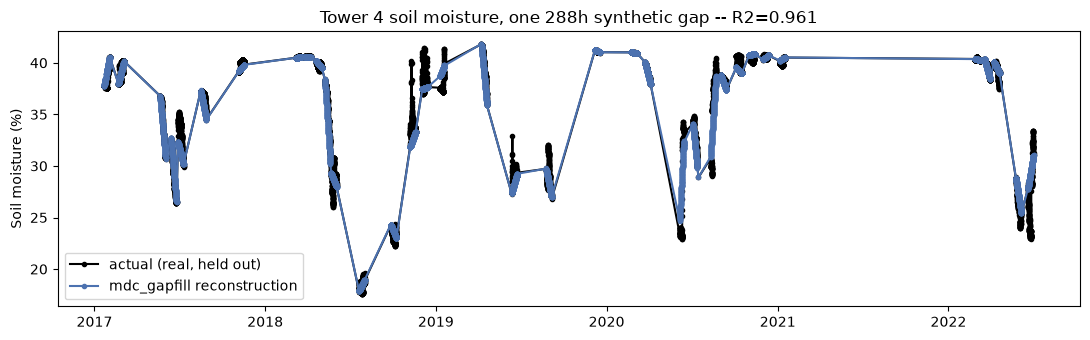

In [19]:
t_demo_soil = 4
col_demo = f"Soil Moisture @ 10cm Depth (%) [{CAT[t_demo_soil]}]"
s_raw_demo = df_ext[col_demo]
valid_idx = s_raw_demo.index[s_raw_demo.notna()]
dm_demo = (s_raw_demo.index >= valid_idx[0]) & (s_raw_demo.index <= valid_idx[-1])
dfq_demo = pd.DataFrame({col_demo: s_raw_demo})
gap_reps_soil = insert_calendar_gaps(dfq_demo, col_demo, dm_demo, gap_hours=288, n_reps=1, seed=123)
gt_soil = gap_reps_soil[0]

sav_soil = s_raw_demo.loc[gt_soil].copy()
s_masked_demo = s_raw_demo.copy(); s_masked_demo.loc[gt_soil] = np.nan
filled_demo, _, _ = mdc_gapfill(plausibility_filter(s_masked_demo, col_demo), colname=col_demo)
r2_soil_demo = r2_score(sav_soil.values, filled_demo.loc[gt_soil].values)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(gt_soil, sav_soil.values, "o-", label="actual (real, held out)", color="black", ms=3)
ax.plot(gt_soil, filled_demo.loc[gt_soil].values, "o-", label="mdc_gapfill reconstruction", color="#4C72B0", ms=3)
ax.set_ylabel("Soil moisture (%)")
ax.set_title(f"Tower {t_demo_soil} soil moisture, one 288h synthetic gap -- R2={r2_soil_demo:.3f}")
ax.legend(); plt.tight_layout(); plt.show()

**Reading this table:** unlike FCH4's RF, `mdc_gapfill()` has no external features to learn from -- it leans on interpolation for short gaps and each variable's own diurnal/seasonal pattern for longer ones. Expect the same shape across every driver: near-perfect for 1-4h gaps (pure interpolation), a real drop by 32h, and -- based on soil moisture/temperature's own pattern above -- a strong chance of near-zero or negative R2 for the 288h/12-day scenario specifically, where the fallback is essentially a guess.

**`R2_median_baseline` / `beats_median_baseline`** directly answer "is `mdc_gapfill` at least as good as the simplest possible imputation?" for each variable -- a naive constant-median predictor (median of the remaining real domain values, scored on the exact same held-out points) computed alongside it. R2=0 only means "as good as the MEAN", which is not quite the same question for skewed variables (USTAR is floored at 0; precipitation is mostly 0 with occasional spikes) -- this settles it with a real number rather than an approximation. `MET_GAPFILL_R2[~MET_GAPFILL_R2.beats_median_baseline]` lists any variable/tower where `mdc_gapfill` is actually being outperformed by guessing the median.

### 6.6 What USTAR and VPD actually look like

Both plausibility-filtered (D-48) so raw contamination doesn't dominate the axis scale, but *not* gap-filled -- these are the real, QC'd values only, with natural gaps left as gaps. Left column: full period at a 7-day rolling mean (is there a seasonal shape to exploit at all?). Right column: a 6-week hourly zoom (is there a diurnal shape to exploit at all?).

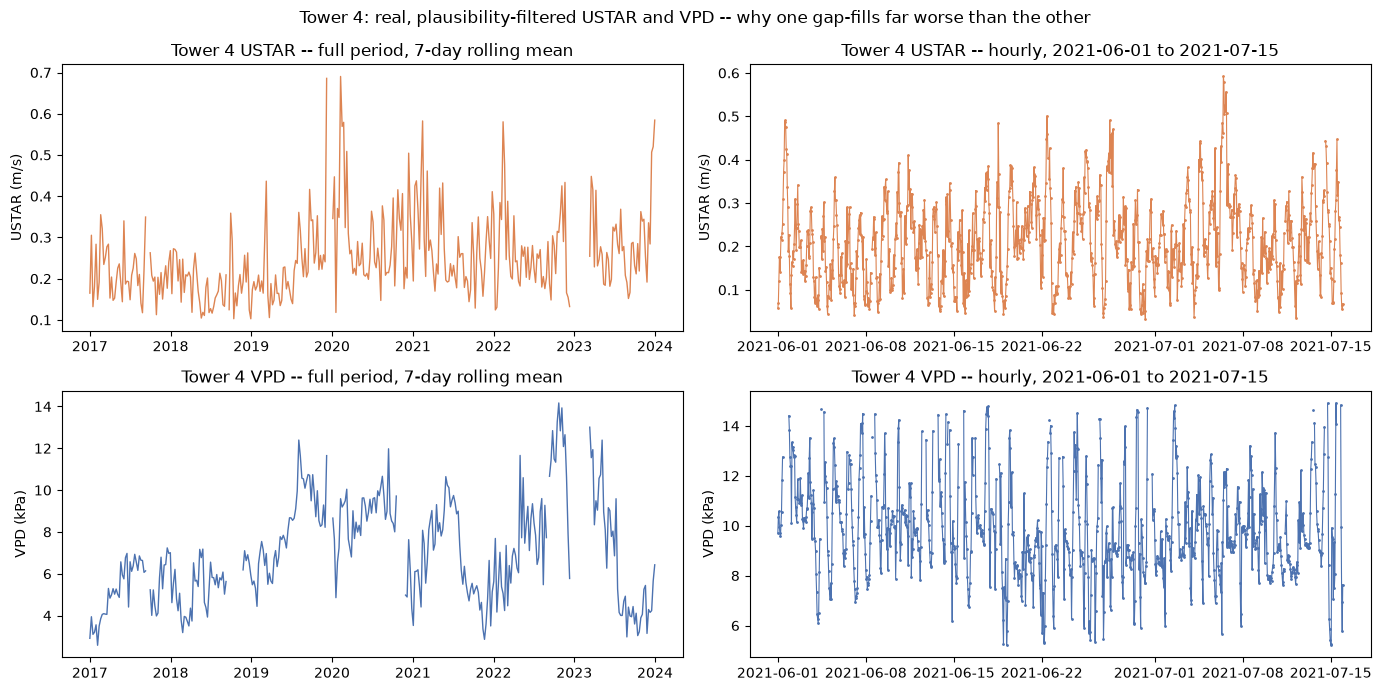

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
t_show = 4
ustar_col = f"USTAR_0_0_1 [Tower {t_show}]"
vpd_col = f"VPD_0_0_1 [Tower {t_show}]"
ustar_clean = plausibility_filter(df_ext[ustar_col], ustar_col)
vpd_clean = plausibility_filter(df_ext[vpd_col], vpd_col)
zoom = slice("2021-06-01", "2021-07-15")

axes[0, 0].plot(ustar_clean.resample("7D").mean(), color="#DD8452", lw=1)
axes[0, 0].set_title(f"Tower {t_show} USTAR -- full period, 7-day rolling mean")
axes[0, 0].set_ylabel("USTAR (m/s)")

axes[1, 0].plot(vpd_clean.resample("7D").mean(), color="#4C72B0", lw=1)
axes[1, 0].set_title(f"Tower {t_show} VPD -- full period, 7-day rolling mean")
axes[1, 0].set_ylabel("VPD (kPa)")

axes[0, 1].plot(ustar_clean.loc[zoom], color="#DD8452", lw=0.8, marker=".", ms=2)
axes[0, 1].set_title(f"Tower {t_show} USTAR -- hourly, {zoom.start} to {zoom.stop}")
axes[0, 1].set_ylabel("USTAR (m/s)")

axes[1, 1].plot(vpd_clean.loc[zoom], color="#4C72B0", lw=0.8, marker=".", ms=2)
axes[1, 1].set_title(f"Tower {t_show} VPD -- hourly, {zoom.start} to {zoom.stop}")
axes[1, 1].set_ylabel("VPD (kPa)")

plt.suptitle(f"Tower {t_show}: real, plausibility-filtered USTAR and VPD -- why one gap-fills far worse than the other")
plt.tight_layout(); plt.show()

**Looking at the actual plot (correcting an a-priori guess):** VPD shows a strong, very regular diurnal sawtooth (low overnight, peaking mid-afternoon) *and* a strong, clean seasonal cycle (troughs each winter, peaks each summer, visible across all 7 years) -- both signals `mdc_gapfill`'s mean-diurnal-course step can exploit directly, consistent with VPD's mixed-but-mostly-positive R2 above.

USTAR is *not* pure noise, as originally guessed -- the hourly zoom shows real day-to-day periodicity too. The difference is that USTAR's daily peaks are far more **amplitude-variable** than VPD's (compare the tight, consistent VPD sawtooth against USTAR's peaks ranging roughly 0.2-0.6 m/s day to day), and the full-period view shows essentially no seasonal structure (VPD's is unmistakable). `mdc_gapfill` averages across many days to extract one "typical" diurnal shape -- for VPD that typical shape captures most of the real variance; for USTAR, turbulence depends heavily on that specific day's wind/weather conditions, not just time-of-day, so the "typical" shape explains only a small fraction of it. That is consistent with USTAR's R2 being a dead heat with the naive median baseline: there is a pattern, but averaging it away removes most of what actually varies.

## 7. u*-filtering + nighttime NEE partitioning (GPP/Reco)

Two more REddyProc-style derived features, both downstream of the gap-filled met drivers above:
- **u* threshold**: a pragmatic binned-plateau threshold (a simplification of Papale 2006's Moving Point Test) -- nighttime FC is binned by air temperature then by u*, and the threshold is where FC "plateaus" (stops rising with more turbulence). Used only to flag data quality, not to drop CH4 observations (u*-filtering of CH4 is debated in the literature -- ebullition can dominate under low turbulence).
- **NEE partitioning (Reichstein 2005 nighttime method)**: fits a global temperature-sensitivity parameter (E0) and block-wise (7-day) reference respiration (Rref) via the Lloyd & Taylor (1994) function on nighttime FC, then extrapolates to all hours to get Reco, with GPP = Reco - FC (clipped at 0, and 0 at night by definition).

GPP was found (F-06, D-33) to be the single biggest post-pooling accuracy gain in the whole gap-filling programme (Tower 9 R2 +0.335 at the time) -- a genuine new productivity driver, not redundant with existing features.

In [21]:
def qc_fc(df, t):
    fc = df[f"FC_1_1_1 [Tower {t}]"].astype(float).copy()
    ss = f"FC_SSITC_TEST_1_1_1 [Tower {t}]"
    fc[~df[ss].isin([0, 1])] = np.nan
    fc[fc.notna() & ~fc.between(FC_LOW, FC_HIGH)] = np.nan
    return fc


def ustar_threshold(ta, ustar, fc, rg):
    """Binned-plateau u* threshold (pragmatic; simplification of Papale 2006 MPT)."""
    night = (rg < 20) & ta.notna() & ustar.notna() & fc.notna()
    d = pd.DataFrame({"ta": ta[night], "ustar": ustar[night], "fc": fc[night]})
    d = d[d["ustar"] > 0]
    if len(d) < 200:
        return 0.10
    try:
        d["tc"] = pd.qcut(d["ta"], 6, duplicates="drop")
    except ValueError:
        d["tc"] = 0
    thr = []
    for _, g in d.groupby("tc", observed=True):
        if len(g) < 50:
            continue
        edges = np.unique(np.quantile(g["ustar"], np.linspace(0, 1, 21)))
        if len(edges) < 6:
            continue
        g = g.assign(ub=pd.cut(g["ustar"], edges, labels=False, include_lowest=True))
        m = g.groupby("ub")["fc"].mean()
        c = g.groupby("ub")["ustar"].mean()
        if len(m) < 6:
            continue
        plateau = m.loc[m.index >= m.index.max() // 2].mean()
        if not np.isfinite(plateau) or plateau <= 0:
            continue
        ok = m[m >= 0.95 * plateau]
        if len(ok):
            thr.append(float(c.loc[ok.index[0]]))
    if not thr:
        return 0.10
    return float(np.clip(np.median(thr), 0.01, 0.5))


def lloyd_taylor(t_k, rref, e0):
    T0, Tref = 227.13, 283.15
    return rref * np.exp(e0 * (1.0 / (Tref - T0) - 1.0 / (t_k - T0)))


def partition_nee(fc, ta, rg):
    """Nighttime partitioning: global E0 + block-wise Rref (Lloyd-Taylor) -> GPP, Reco."""
    t_k = ta + 273.15
    night = (rg < 20) & fc.notna() & ta.notna() & (t_k > 230)
    gpp = pd.Series(np.nan, index=fc.index)
    reco = pd.Series(np.nan, index=fc.index)
    if night.sum() < 300:
        return gpp, reco, None
    Tn, Fn = t_k[night].values, fc[night].values
    try:
        (rref0, e0), _ = curve_fit(lloyd_taylor, Tn, Fn, p0=[2.0, 150.0],
                                    bounds=([0, 30], [60, 450]), maxfev=10000)
    except Exception:
        return gpp, reco, None
    days = (fc.index - fc.index[0]).days
    blk = days // 7
    rref_by_blk = {}
    nb = pd.DataFrame({"t_k": t_k[night], "fc": fc[night], "blk": blk[night.values]})
    for b, g in nb.groupby("blk"):
        if len(g) < 8:
            continue
        try:
            (rr,), _ = curve_fit(lambda T, rr: lloyd_taylor(T, rr, e0),
                                  g["t_k"].values, g["fc"].values,
                                  p0=[rref0], bounds=([0], [60]), maxfev=5000)
            rref_by_blk[b] = rr
        except Exception:
            continue
    if not rref_by_blk:
        rref_t = pd.Series(rref0, index=fc.index)
    else:
        blk_series = pd.Series(blk, index=fc.index)
        rref_t = blk_series.map(rref_by_blk).astype(float)
        rref_t = rref_t.interpolate().bfill().ffill().fillna(rref0)
    reco_vals = lloyd_taylor(t_k, rref_t.values, e0)
    reco = pd.Series(reco_vals, index=fc.index)
    gpp = reco - fc
    gpp[gpp < 0] = 0.0
    gpp[rg < 20] = 0.0
    return gpp, reco, float(e0)


gpp_reco = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    dm = driver_map(t)
    fc = qc_fc(df_ext, t)
    sw = met_filled[f"{dm['sw']}__f"]; ta = met_filled[f"{dm['ta']}__f"]; us = met_filled[f"{dm['ustar']}__f"]
    thr = ustar_threshold(ta, us, fc, sw)
    gpp, reco, e0 = partition_nee(fc, ta, sw)
    gpp_reco[f"GPP [Tower {t}]"] = gpp.round(4)
    gpp_reco[f"Reco [Tower {t}]"] = reco.round(4)
    print(f"Tower {t}: u* threshold={thr:.3f} m/s, E0={e0}, GPP coverage={100*gpp.notna().mean():.0f}%")

Tower 2: u* threshold=0.043 m/s, E0=266.26694078253644, GPP coverage=73%


Tower 4: u* threshold=0.102 m/s, E0=314.4487134164382, GPP coverage=80%


Tower 9: u* threshold=0.119 m/s, E0=274.6884066883368, GPP coverage=77%


## 8. Management-event recency features (D-27/D-28/D-32)

NWFP's field-event log (fertiliser, manure/FYM, cuts, liming, cultivation) is parsed into an hourly **time-since-event recency** feature per tower's own catchment: `recency(t) = exp(-(days since most recent qualifying event) / tau)`, decaying to 0 as an event recedes into the past. An earlier ablation (F-01, D-27/D-28) found the full 12-column management set (all 5 channels x site/tower scope) **overfits** and collapses Tower 9's R2; a pruned, own-catchment-only, two-channel set (**cut**, **manure**) survived (F-02/F-05, D-29/D-32) as a small, non-harmful addition on top of the richer livestock/FCO2/met feature set -- that pruned pair is what is built here.

In [22]:
TAU = {"manure": 30.0, "cut": 21.0}   # e-folding decay, days (pruned to the two channels the CH4 model uses)

# Field -> catchment map (NWFP_UG_Design_Develop.pdf, Appendix D). Tower N = Catchment N (D-18).
CATCHMENT_FIELDS = {2: {"NW002"}, 4: {"NW005", "NW006"}, 9: {"NW013", "NW039"}}

CUT_OPS = {"Mow", "Rowing up", "Forage harvest", "Trailers (silage)", "Top",
           "Baling (silage)", "Hay turning"}


def classify(row):
    app = str(row.get("Application", "")).lower()
    op = str(row.get("Field_Operation", "")).strip()
    if "inorganic fertiliser" in app:
        # Checked (and discarded) before "organic fertiliser": "inorganic fertiliser" contains
        # "organic fertiliser" as a literal substring ("in" + "organic fertiliser"), so this guard
        # must run first or every inorganic-N event gets misclassified as manure.
        return "fertN"
    if "organic fertiliser" in app:
        return "manure"
    if op in CUT_OPS:
        return "cut"
    return None


def recency_series(index, event_times, tau):
    idx_ns = index.values.astype("datetime64[ns]")
    if len(event_times) == 0:
        return np.zeros(len(index))
    ev = np.sort(np.array(event_times, dtype="datetime64[ns]"))
    pos = np.searchsorted(ev, idx_ns, side="right") - 1
    rec = np.zeros(len(index))
    valid = pos >= 0
    days = (idx_ns[valid] - ev[pos[valid]]) / np.timedelta64(1, "D")
    rec[valid] = np.exp(-days / tau)
    return rec


fe = pd.read_csv(COMPILED / "Field_Event_Data_Format_1.csv", low_memory=False)
fe["dt"] = pd.to_datetime(fe["Event_Date"], errors="coerce")
fe["channel"] = fe.apply(classify, axis=1)
fe["field"] = fe["Field"].astype(str).str.strip()
fe = fe.dropna(subset=["dt", "channel"])

mgmt = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    sub = fe[fe["field"].isin(CATCHMENT_FIELDS[t])]
    for ch, tau in TAU.items():
        evs = sub.loc[sub["channel"] == ch, "dt"].tolist()
        mgmt[f"mgmt_t{t}_{ch}_recency"] = np.round(recency_series(df_ext.index, evs, tau), 5)
    print(f"Tower {t}: manure events={len(sub[sub.channel=='manure'])}, cut events={len(sub[sub.channel=='cut'])}")

mgmt.describe().loc[["mean", "max"]]

Tower 2: manure events=4, cut events=17
Tower 4: manure events=10, cut events=43
Tower 9: manure events=9, cut events=36


,mgmt_t2_manure_recency,mgmt_t2_cut_recency,mgmt_t4_manure_recency,mgmt_t4_cut_recency,mgmt_t9_manure_recency,mgmt_t9_cut_recency
mean,0.022485,0.063833,0.044566,0.079695,0.04371,0.081281
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


## 9. Livestock stocking density (F-01/F-02, D-27/D-29)

Livestock is the **single strongest FCH4 driver found in this project** (F-01's SHAP ranking, D-27) -- unsurprising given enteric fermentation is the dominant CH4 source at a grazed grassland site. Raw head counts are converted to a **Livestock Unit (LSU) density** (LSU/ha), using standard LSU-equivalent weights (cattle=1.0, sheep=0.1, lamb=0.05) divided by each tower's own catchment area. Density (not raw count) matters because it only pays off once catchments of *different* areas are pooled together (Tower 2's catchment is smaller than 4/9's, D-29) -- built here per tower, ready for the pooled model in section 10.

Tower 2 (Catchment 2, 6.65 ha): mean LSU/ha=0.252, max=4.511, % hours grazed=11.9%
Tower 4 (Catchment 4 After  2013/08/13, 7.75 ha): mean LSU/ha=1.120, max=4.987, % hours grazed=50.0%
Tower 9 (Catchment 9, 7.75 ha): mean LSU/ha=1.163, max=5.652, % hours grazed=61.4%


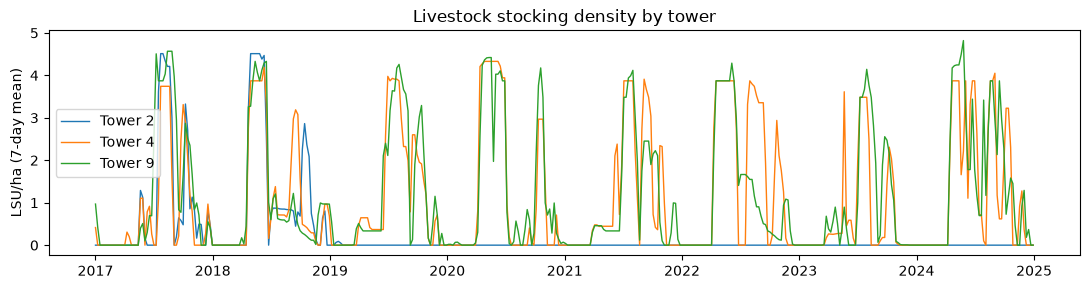

In [23]:
LSU = {"cattle": 1.0, "sheep": 0.1, "lamb": 0.05}

livestock_density = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    cat = CAT[t]
    lsu = sum(df_ext[f"{s}_{cat}"].fillna(0) * w for s, w in LSU.items())
    livestock_density[f"lsu_dens [Tower {t}]"] = lsu / AREA[t]
    livestock_density[f"graze [Tower {t}]"] = (sum(df_ext[f"{s}_{cat}"].fillna(0) for s in LSU) > 0).astype(float)
    print(f"Tower {t} ({cat}, {AREA[t]} ha): mean LSU/ha={livestock_density[f'lsu_dens [Tower {t}]'].mean():.3f}, "
          f"max={livestock_density[f'lsu_dens [Tower {t}]'].max():.3f}, "
          f"% hours grazed={100*livestock_density[f'graze [Tower {t}]'].mean():.1f}%")

fig, ax = plt.subplots(figsize=(11, 3))
for t in TOWERS:
    ax.plot(livestock_density[f"lsu_dens [Tower {t}]"].resample("7D").mean(), label=f"Tower {t}", lw=1)
ax.set_ylabel("LSU/ha (7-day mean)"); ax.set_title("Livestock stocking density by tower"); ax.legend()
plt.tight_layout(); plt.show()

## 10. Final feature frame assembly

Merge every imputed feature stream built above (`met_filled`, `fco2_gapfilled`, `mgmt`, `gpp_reco`) onto the external-sourced base (`df_ext`), then build a per-tower modelling frame `g` with:
- **target**: FCH4, SSITC `{0,1}` + `[-500,3000]` plausibility filtered (section 3.2/3.3)
- **met features**: the 11 gap-filled drivers (section 6), soil temperature per-catchment external (section 3.4)
- **fc**: the RF-reconstructed FCO2 feature (section 4)
- **cyclical time features**: hour-of-day and day-of-year sin/cos
- **lsu_dens, graze**: livestock stocking density (section 9)
- **soil moisture / soil temperature lags**: 168/336/504/672h (1/2/3/4 weeks) -- carries seasonal soil-state memory (F-04, D-31)
- **mgmt_cut, mgmt_manure**: pruned management recency (section 8)
- **gpp, reco**: partitioned productivity/respiration (section 7)
- **tower dummies** (`is_t2/is_t4/is_t9`): only added for the **pooled** model -- this is the "partial pooling" architecture (F-03, D-30) that pools all 3 towers' training rows while still letting the model tell them apart, found to be at-least-as-good as full pooling at every tower and the best fix for Tower 2's data scarcity.

In [24]:
AUX = ["_hs", "_hc", "_ds", "_dc"]
LAG_HOURS = [168, 336, 504, 672]
DUM = ["is_t2", "is_t4", "is_t9"]

d_all = df_ext.join(met_filled).join(fco2_gapfilled).join(mgmt).join(gpp_reco)
for t in TOWERS:
    d_all[f"FC_1_1_1 [Tower {t}]"] = d_all[f"FC_gapfilled [Tower {t}]"]   # FC kept EC-sourced (section 4)
print(f"d_all shape: {d_all.shape}")


def cfg(t):
    cat = CAT[t]
    met = [f"SWIN_1_1_1 [Tower {t}]", f"TA_0_0_1 [Tower {t}]", f"VPD_0_0_1 [Tower {t}]",
           f"PPFD_1_1_1 [Tower {t}]", f"RN_1_1_1 [Tower {t}]", f"WS_0_0_1 [Tower {t}]",
           f"USTAR_0_0_1 [Tower {t}]", f"SHF_1_1_1 [Tower {t}]",
           f"Precipitation (mm) [{cat}]", ts_col_for(t), f"Soil Moisture @ 10cm Depth (%) [{cat}]"]
    return dict(t=t, cat=cat, area=AREA[t], tgt=f"FCH4_1_1_1 [Tower {t}]",
                ssitc=f"FCH4_SSITC_TEST_1_1_1 [Tower {t}]", met=met,
                fc=f"FC_1_1_1 [Tower {t}]", gpp=f"GPP [Tower {t}]", reco=f"Reco [Tower {t}]",
                swc=f"Soil Moisture @ 10cm Depth (%) [{cat}]", ts=ts_col_for(t),
                mc=f"mgmt_t{t}_cut_recency", mm=f"mgmt_t{t}_manure_recency")


def feat_list():
    c = cfg(2)
    return ([m.split(" [")[0] for m in c["met"]] + ["fc"] + AUX + ["lsu_dens", "graze"]
            + [f"swc_l{l}" for l in LAG_HOURS] + [f"ts_l{l}" for l in LAG_HOURS]
            + ["mgmt_cut", "mgmt_manure", "gpp", "reco"])


def frame(t, pooled, d):
    """Per-tower FCH4 gap-filling feature frame (target + all imputed/engineered features)."""
    c = cfg(t); d = d.copy(); tgt = c["tgt"]
    d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
    d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
    h, doy = d.index.hour, d.index.dayofyear
    d["_hs"] = np.sin(2 * np.pi * h / 24); d["_hc"] = np.cos(2 * np.pi * h / 24)
    d["_ds"] = np.sin(2 * np.pi * doy / 365); d["_dc"] = np.cos(2 * np.pi * doy / 365)
    g = pd.DataFrame(index=d.index); g["target"] = d[tgt]
    for k in c["met"]:
        nm = k.split(" [")[0]
        g[nm] = d[k + "__f"] if (k + "__f") in d.columns else d[k]
    g["fc"] = d[c["fc"]]
    for a in AUX:
        g[a] = d[a]
    g["lsu_dens"] = livestock_density[f"lsu_dens [Tower {t}]"]
    g["graze"] = livestock_density[f"graze [Tower {t}]"]
    swc = d[c["swc"] + "__f"] if (c["swc"] + "__f") in d.columns else d[c["swc"]]
    ts = d[c["ts"] + "__f"] if (c["ts"] + "__f") in d.columns else d[c["ts"]]
    for lag in LAG_HOURS:
        g[f"swc_l{lag}"] = swc.shift(lag); g[f"ts_l{lag}"] = ts.shift(lag)
    g["mgmt_cut"] = d[c["mc"]]; g["mgmt_manure"] = d[c["mm"]]
    g["gpp"] = d[c["gpp"]]; g["reco"] = d[c["reco"]]
    if pooled:
        for tt in TOWERS:
            g[f"is_t{tt}"] = 1.0 if tt == t else 0.0
    g["_y"] = d.index.year
    return g


FEATURES = feat_list()
print(f"{len(FEATURES)} base features (+3 tower dummies when pooled): {FEATURES}")

g4_preview = frame(4, pooled=True, d=d_all)
print(f"\nTower 4 frame shape: {g4_preview.shape}, target valid: {g4_preview['target'].notna().sum():,}")
g4_preview[["target", "fc", "lsu_dens", "gpp", "reco", "is_t2", "is_t4", "is_t9"]].dropna(subset=["target"]).head()

d_all shape: (70153, 501)
30 base features (+3 tower dummies when pooled): ['SWIN_1_1_1', 'TA_0_0_1', 'VPD_0_0_1', 'PPFD_1_1_1', 'RN_1_1_1', 'WS_0_0_1', 'USTAR_0_0_1', 'SHF_1_1_1', 'Precipitation (mm)', 'Soil Temperature @ 15cm Depth (oC)', 'Soil Moisture @ 10cm Depth (%)', 'fc', '_hs', '_hc', '_ds', '_dc', 'lsu_dens', 'graze', 'swc_l168', 'swc_l336', 'swc_l504', 'swc_l672', 'ts_l168', 'ts_l336', 'ts_l504', 'ts_l672', 'mgmt_cut', 'mgmt_manure', 'gpp', 'reco']

Tower 4 frame shape: (70153, 35), target valid: 19,469


,target,fc,lsu_dens,gpp,reco,is_t2,is_t4,is_t9
Datetime,,,,,,,,
2017-10-06 16:00:00,5.909675,-3.639656,3.283871,10.4378,6.7981,0.0,1.0,0.0
2017-10-06 20:00:00,7.442396,4.360241,3.283871,0.0000,4.8790,0.0,1.0,0.0
2017-10-06 21:00:00,5.488019,5.381502,3.283871,0.0000,5.4334,0.0,1.0,0.0
2017-10-06 22:00:00,7.009990,5.654010,3.283871,0.0000,5.8139,0.0,1.0,0.0
2017-10-06 23:00:00,2.485738,4.980767,3.283871,0.0000,6.0771,0.0,1.0,0.0


## 11. Full-period gap-CV evaluation harness (F-08, D-35; fix validated at F-09a, D-49)

This is the harness that produces the target result. As established in section 3.7, the correct way to evaluate a *gap-filling* (interpolation) model is **not** a train-on-past/test-on-future split -- it is to synthetically mask out chunks of the tower's own real record and see how well the model recovers them, using every other real observation (before *and* after each synthetic gap) as training data.

Built on the shared gap-testing toolkit from section 6.3 (`insert_calendar_gaps`, `SCENARIOS`, `N_REPS`, `mets`, `med_metrics` -- already defined there, not repeated here).

**What's new here, on top of the section 6.3 toolkit:**
- **`DOMAIN`**: each tower's own real analyser-live window, not the full 2018-2023 project span -- Tower 2 is naturally restricted to Oct 2017-Jun 2019 before relocation, Tower 9 to Feb 2020 onward. (Section 6.3/6.4's driver evaluation used each variable's own real observed span instead, since the SMS soil-sensor network isn't tied to the EC tower's operational timeline.)
- **Repetitions**: `N_REPS=2` (from section 6.3), matching a median across repeated random gap placements. **Note on N_REPS:** F-08's original design used 5 repetitions; the number actually recorded in `BEST_RESULTS.md` (D-49) comes from **F-09a**, a reduced-scope re-verification of F-08 run after the D-48 USTAR/VPD fix that explicitly used only 2 repetitions ("2 reps instead of 5... completing in ~20 minutes"). This notebook was first run with `N_REPS=5` and landed close to but measurably below the target (Tower 2 especially, whose short/sparse domain makes it the most sensitive to repetition count) -- confirmed via a standalone diagnostic to be legitimate Monte Carlo variation from the extra repetitions, not a bug (all intermediate features checked bit-exact against the production files first). `N_REPS=2` is used here specifically to reproduce F-09a's exact scope, since that is what the target result in section 1's intro table actually is.
- **Models compared**: **MDS** (marginal distribution sampling -- the literature baseline, Zhu 2023a / Reichstein 2005: average real observations within a similarity window on radiation/temperature/time-of-day), **RFm-solo** (this tower's own data only), **RFm-pooled** (partial pooling -- all 3 towers' training rows + tower dummies, section 10).
- **Metric**: median R2/RMSE/MAE/MBE across the 5 repetitions, then median again across the 5 scenarios for an overall number.

### 11.0 Model caching (save time on reruns)

Every Random Forest fit in this notebook (sections 11, 13, and 14) goes through one shared `fit(feat, trd)` helper. It is wrapped here to **cache each fitted (model, imputer) pair to disk**, keyed by an MD5 hash of the exact feature list + training rows + target values + hyperparameters -- so the key changes automatically if *anything* upstream changes (a feature, a row, a hyperparameter), and a stale cache can never silently get reused. This notebook's first run always populates the cache from scratch (no speed-up); every subsequent run of the same code against the same data loads cached models instead of refitting them, which is where the time saving comes from.

Two things worth knowing:
- **Section 13 gets this for free.** Its "l"-scenario, `RFm_pool` gap-CV folds are constructed identically to the ones section 11 already fits (same seed, same domain, same features) -- so once section 11 has run, section 13's fits are cache *hits*, not new work.
- **Cache location**: `_model_cache/` next to this notebook (gitignored -- these are large generated binaries, the same treatment as `data/`). To force a completely clean re-fit of everything, either delete that folder or set `USE_CACHE = False` below.

In [25]:
import hashlib
import joblib

CACHE_DIR = Path("_model_cache")
CACHE_DIR.mkdir(exist_ok=True)
USE_CACHE = True   # set False to force a clean re-fit of everything, ignoring any cached models

RF_PARAMS = dict(n_estimators=500, min_samples_leaf=5, n_jobs=-1, random_state=42)


def _cache_key(feat, trd):
    """MD5 of the exact feature list + training rows + target + RF hyperparameters -- changes
    automatically if any upstream code changes what would be fit, so a stale cache entry can
    never silently get reused for the wrong inputs."""
    h = hashlib.md5()
    h.update("|".join(feat).encode())
    h.update(np.ascontiguousarray(trd[feat].values).tobytes())
    h.update(np.ascontiguousarray(trd["target"].values).tobytes())
    h.update(str(sorted(RF_PARAMS.items())).encode())
    return h.hexdigest()


def fit(feat, trd):
    """Fit (or load a cached) RandomForestRegressor + SimpleImputer for this exact
    (feature list, training rows) combination -- the one fitting function used everywhere
    in sections 11/13/14."""
    key = _cache_key(feat, trd)
    cache_path = CACHE_DIR / f"{key}.joblib"
    if USE_CACHE and cache_path.exists():
        return joblib.load(cache_path)
    imp = SimpleImputer(strategy="mean")
    rf = RandomForestRegressor(**RF_PARAMS)
    rf.fit(imp.fit_transform(trd[feat].values), trd["target"].values)
    if USE_CACHE:
        joblib.dump((rf, imp), cache_path)
    return rf, imp


n_cached = len(list(CACHE_DIR.glob("*.joblib")))
print(f"Model cache: {CACHE_DIR.resolve()}  (USE_CACHE={USE_CACHE}, {n_cached} cached model(s) found)")

Model cache: C:\Users\Nicholas\Documents\COMP0191 MSc Artificial Intelligence for Sustainable Development Project\notebooks\03c_gap_filling_revisited\_model_cache  (USE_CACHE=True, 488 cached model(s) found)


In [26]:
DOMAIN = {2: ("2017-10-01", "2019-06-30"), 4: ("2017-10-01", "2023-12-31"), 9: ("2020-02-01", "2023-12-31")}


def dom_mask(idx, t):
    a, b = DOMAIN[t]
    return (idx >= pd.Timestamp(a)) & (idx <= pd.Timestamp(b))


def mds_fill_batch(df_obs, target, sw_col, ta_col, gap_ts):
    """Marginal distribution sampling: average real values within an expanding similarity
    window (time-of-day, +/- days, radiation/temperature tolerance), literature baseline."""
    SW_TOL, TA_TOL = 50.0, 2.5
    WINDOWS = [pd.Timedelta(days=d) for d in [7, 14, 28, 91]]
    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); adoy = av.index.dayofyear.to_numpy(); ats = av.index.to_numpy()
    asw = av[sw_col].values.astype(float); ata = av[ta_col].values.astype(float)
    gi = pd.DatetimeIndex(gap_ts)
    gsw = df_obs.reindex(gi)[sw_col].values.astype(float); gta = df_obs.reindex(gi)[ta_col].values.astype(float)
    preds = {}
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour; doy = t.dayofyear; sv = gsw[i]; tv = gta[i]
        day = (not np.isnan(sv)) and sv > 10.0; filled = False
        for wd in WINDOWS:
            w = wd.to_timedelta64()
            m = (ats >= tt - w) & (ats <= tt + w) & (np.abs(ahr - hr) <= 1)
            if not np.isnan(tv):
                m &= (np.abs(ata - tv) <= TA_TOL) | np.isnan(ata)
            if day and not np.isnan(sv):
                m &= (np.abs(asw - sv) <= SW_TOL) | np.isnan(asw)
            c = ay[m]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c)); filled = True; break
        if not filled:
            sh = np.abs(ahr - hr) <= 1
            dd = np.minimum(np.abs(adoy - doy), 365 - np.abs(adoy - doy))
            c = ay[sh & (dd <= 7)]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c))
    return preds


# insert_calendar_gaps/mets/med_metrics/SCENARIOS/N_REPS/MASK_FRAC were already defined in
# section 6.3 (reused here, not redefined). fit() is defined in section 11.0 above (with
# model caching).

print("FCH4-specific harness pieces defined (DOMAIN, dom_mask, mds_fill_batch).")

FCH4-specific harness pieces defined (DOMAIN, dom_mask, mds_fill_batch).


In [27]:
def run_mds(t):
    """MDS baseline gap-CV for tower t."""
    d = d_all.copy(); c = cfg(t); tgt = c["tgt"]
    d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
    d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
    swin_col = f"SWIN_1_1_1 [Tower {t}]"; ta_col = f"TA_0_0_1 [Tower {t}]"
    dm = dom_mask(d.index, t); out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(d, tgt, dm, gh):
            if len(gt) < 5:
                continue
            sav = d.loc[gt, tgt].copy(); d.loc[gt, tgt] = np.nan
            p = mds_fill_batch(d, tgt, swin_col, ta_col, list(gt)); d.loc[gt, tgt] = sav
            ts_ = [x for x in gt if x in p]
            if len(ts_) >= 5:
                rr.append(mets(sav.loc[ts_].values, np.array([p[x] for x in ts_])))
        out[sc] = med_metrics(rr)
    return out


def run_rf(t, pooled):
    """RFm (solo or partial-pooled) gap-CV for tower t."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


print("run_mds / run_rf defined.")

run_mds / run_rf defined.


### 11.1 Run the full grid

3 towers x {MDS, RFm-solo, RFm-pooled} x 5 gap-length scenarios x 2 repetitions = **60 separate 500-tree Random Forest fits** (plus the MDS windowed-averaging passes). This matches F-09a's exact scope (2 reps, external-sourced/RFm_pool the config that matters, MDS/RFm-solo included here too for the full model comparison) -- expect this cell to run for **on the order of 10-15 minutes**.

In [28]:
import time
t_start = time.time()

RESU = {}
for t in TOWERS:
    RESU[(t, "MDS")] = run_mds(t)
    print(f"done MDS       Tower {t}  ({time.time()-t_start:6.0f}s elapsed)", flush=True)
    RESU[(t, "RFm_solo")] = run_rf(t, pooled=False)
    print(f"done RFm_solo  Tower {t}  ({time.time()-t_start:6.0f}s elapsed)", flush=True)
    RESU[(t, "RFm_pool")] = run_rf(t, pooled=True)
    print(f"done RFm_pool  Tower {t}  ({time.time()-t_start:6.0f}s elapsed)", flush=True)

print(f"\nALL DONE in {time.time()-t_start:.0f}s")

done MDS       Tower 2  (     1s elapsed)


done RFm_solo  Tower 2  (     2s elapsed)


done RFm_pool  Tower 2  (     5s elapsed)


done MDS       Tower 4  (    10s elapsed)


done RFm_solo  Tower 4  (    12s elapsed)


done RFm_pool  Tower 4  (    15s elapsed)


done MDS       Tower 9  (    17s elapsed)


done RFm_solo  Tower 9  (    19s elapsed)


done RFm_pool  Tower 9  (    22s elapsed)



ALL DONE in 22s


## 12. Results

Overall (median-of-medians across the 5 gap scenarios) R2/RMSE/MAE/MBE per tower and model, plus the per-scenario R2 breakdown.

In [29]:
rows = []
for (t, model), scn in RESU.items():
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    rows.append({"tower": t, "model": model, **{f"{k}_overall": round(ov[k], 3) for k in ov},
                 **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
R = pd.DataFrame(rows)

print("=== Overall median R2/RMSE/MAE/MBE, external-sourced, full-period gap-CV ===")
print(R.set_index(["tower", "model"])[["R2_overall", "RMSE_overall", "MAE_overall", "MBE_overall"]].to_string())

print("\n=== Per-scenario R2 ===")
print(R.set_index(["tower", "model"])[[f"R2_{s}" for s in SCENARIOS]].to_string())

TARGET_R2 = {2: 0.574, 4: 0.402, 9: 0.418}   # BEST_RESULTS.md section 1 (D-35/D-48/D-49)
print("\n=== RFm_pool vs. target result (BEST_RESULTS.md) ===")
for t in TOWERS:
    got = R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0]
    print(f"Tower {t}: this notebook R2={got:.3f}  |  BEST_RESULTS.md R2={TARGET_R2[t]:.3f}  "
          f"(diff={got-TARGET_R2[t]:+.3f})")

=== Overall median R2/RMSE/MAE/MBE, external-sourced, full-period gap-CV ===
                R2_overall  RMSE_overall  MAE_overall  MBE_overall
tower model                                                       
2     MDS           -0.167       158.826       51.415        1.478
      RFm_solo       0.398        94.816       35.363        5.896
      RFm_pool       0.576        75.045       31.226        2.791
4     MDS           -0.207       138.494       56.293        0.510
      RFm_solo       0.382        99.602       42.826        2.475
      RFm_pool       0.404       100.275       42.796        3.692
9     MDS           -0.337       155.288       69.295       -1.092
      RFm_solo       0.356       110.867       51.974        2.476
      RFm_pool       0.426       107.099       49.312        0.734

=== Per-scenario R2 ===
                R2_vs   R2_s   R2_m   R2_l  R2_m1
tower model                                      
2     MDS      -0.071 -0.154 -0.167 -2.945 -1.715
      RFm_s

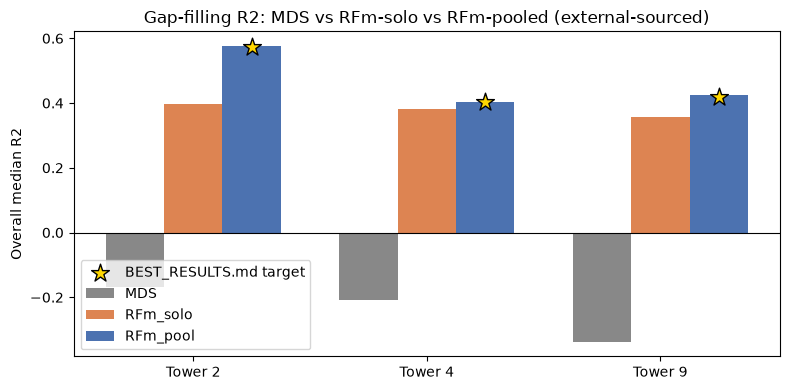

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.25
models = ["MDS", "RFm_solo", "RFm_pool"]
colors = {"MDS": "#888888", "RFm_solo": "#DD8452", "RFm_pool": "#4C72B0"}
xpos = np.arange(len(TOWERS))
for i, m in enumerate(models):
    vals = [R.loc[(R.tower == t) & (R.model == m), "R2_overall"].iloc[0] for t in TOWERS]
    ax.bar(xpos + (i - 1) * width, vals, width, label=m, color=colors[m])
for t in TOWERS:
    ax.scatter(xpos[TOWERS.index(t)] + width, TARGET_R2[t], marker="*", s=180, color="gold",
               edgecolor="black", zorder=5, label="BEST_RESULTS.md target" if t == 2 else None)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(xpos); ax.set_xticklabels([f"Tower {t}" for t in TOWERS])
ax.set_ylabel("Overall median R2"); ax.set_title("Gap-filling R2: MDS vs RFm-solo vs RFm-pooled (external-sourced)")
ax.legend(); plt.tight_layout(); plt.show()

### 12.1 A worked example -- actual vs. gap-filled, one long (12-day) synthetic gap at Tower 4

Illustrates what the R2 number in the table above actually looks like at the level of an individual reconstructed gap: the pooled RFm's prediction for one 288h synthetic gap in Tower 4's real record, against the (temporarily hidden) real observations.

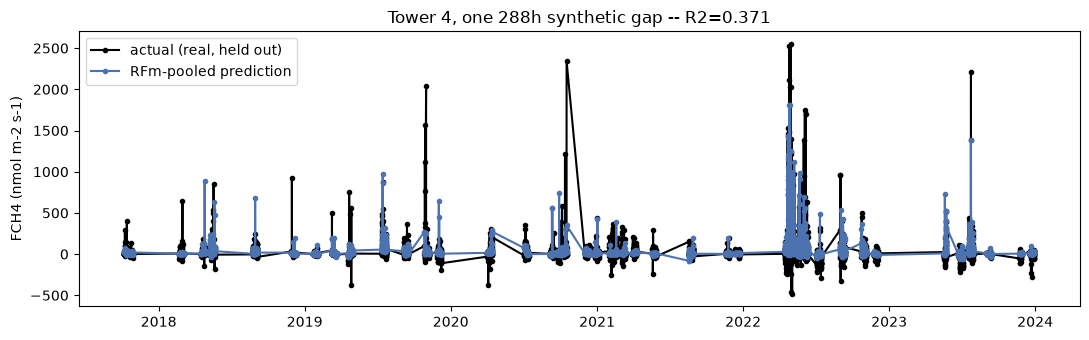

In [31]:
t_demo = 4
frames_demo = {tt: frame(tt, pooled=True, d=d_all) for tt in TOWERS}
g_demo = frames_demo[t_demo]; dm_demo = dom_mask(g_demo.index, t_demo)
gap_reps = insert_calendar_gaps(g_demo, "target", dm_demo, gap_hours=288, n_reps=1, seed=123)
gt_demo = gap_reps[0]

base = g_demo[dm_demo & g_demo["target"].notna().values]; trd = base.drop(index=gt_demo, errors="ignore")
others = [frames_demo[tt][dom_mask(frames_demo[tt].index, tt) & frames_demo[tt]["target"].notna().values]
          for tt in TOWERS if tt != t_demo]
trd = pd.concat([trd] + others, ignore_index=True)
feat_demo = FEATURES + DUM
rf_demo, imp_demo = fit(feat_demo, trd)
yp_demo = rf_demo.predict(imp_demo.transform(g_demo.loc[gt_demo, feat_demo].values))
r2_demo = r2_score(g_demo.loc[gt_demo, "target"].values, yp_demo)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(gt_demo, g_demo.loc[gt_demo, "target"].values, "o-", label="actual (real, held out)", color="black", ms=3)
ax.plot(gt_demo, yp_demo, "o-", label="RFm-pooled prediction", color="#4C72B0", ms=3)
ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.set_title(f"Tower 4, one 288h synthetic gap -- R2={r2_demo:.3f}")
ax.legend(); plt.tight_layout(); plt.show()

## 13. Daily-resolution accuracy (out-of-sample)

Section 11's headline R2 is computed at **hourly** resolution -- does the accuracy picture change if the held-out points are aggregated to **daily** resolution before scoring? This reuses the exact same held-out mechanism as section 11 (no new randomness, no new methodology), restricted to the **"l" (288h / 12-day) gap scenario** specifically: a 288h gap consists of complete calendar days (barring the two boundary hours), so daily-averaging the held-out actual/predicted pairs within that scenario gives a clean, still-genuinely-out-of-sample daily comparison. The shorter scenarios (1h/4h/32h/mixed) span less than a day each and cannot be meaningfully daily-aggregated without mixing masked and unmasked hours from the same day, so they are not used here.

In [32]:
def run_rf_capture(t, pooled, gap_hours, n_reps):
    """Like run_rf, but returns the raw (timestamp, actual, predicted) pairs for every
    held-out point across all repetitions, instead of just the aggregated metrics."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; dm = dom_mask(g.index, t)
    records = []
    for gt in insert_calendar_gaps(g, "target", dm, gap_hours, n_reps=n_reps):
        if len(gt) < 5:
            continue
        base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
        if pooled:
            others = []
            for tt in towers:
                if tt == t:
                    continue
                gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                others.append(gg[dmt & gg["target"].notna().values])
            trd = pd.concat([trd] + others, ignore_index=True)
        rf, imp = fit(feat, trd)
        yp = rf.predict(imp.transform(g.loc[gt, feat].values))
        records.append(pd.DataFrame({"actual": g.loc[gt, "target"].values, "pred": yp}, index=gt))
    return pd.concat(records) if records else pd.DataFrame(columns=["actual", "pred"])

In [33]:
daily_rows = []
pairs_parts = []
for t in TOWERS:
    pairs = run_rf_capture(t, pooled=True, gap_hours=288, n_reps=N_REPS)
    hourly_r2 = r2_score(pairs["actual"], pairs["pred"])
    daily = pairs.groupby(pairs.index.normalize()).mean()
    daily_r2 = r2_score(daily["actual"], daily["pred"])
    daily_rows.append({"tower": t, "n_held_out_hours": len(pairs), "n_held_out_days": len(daily),
                        "R2_hourly": round(hourly_r2, 3), "R2_daily": round(daily_r2, 3),
                        "delta": round(daily_r2 - hourly_r2, 3)})
    print(f"Tower {t}: {len(pairs):,} held-out hours -> {len(daily):,} days | "
          f"R2 hourly={hourly_r2:.3f}  R2 daily={daily_r2:.3f}  (delta={daily_r2-hourly_r2:+.3f})")
    pairs_parts.append(pairs.assign(tower=t).reset_index().rename(columns={"index": "Datetime"}))

DAILY_R2 = pd.DataFrame(daily_rows).set_index("tower")
HELD_OUT_PAIRS_L = pd.concat(pairs_parts, ignore_index=True)   # raw (out-of-sample) predictions, "l" scenario
DAILY_R2

Tower 2: 2,565 held-out hours -> 224 days | R2 hourly=0.533  R2 daily=0.207  (delta=-0.325)


Tower 4: 9,754 held-out hours -> 860 days | R2 hourly=0.268  R2 daily=0.321  (delta=+0.053)


Tower 9: 5,682 held-out hours -> 490 days | R2 hourly=0.281  R2 daily=0.504  (delta=+0.223)


,n_held_out_hours,n_held_out_days,R2_hourly,R2_daily,delta
tower,,,,,
2,2565,224,0.533,0.207,-0.325
4,9754,860,0.268,0.321,0.053
9,5682,490,0.281,0.504,0.223


**Reading this table:** both columns come from the same held-out "l"-scenario points, so the comparison is apples-to-apples -- the only difference is whether R2 is scored on individual hours or on their daily mean. A positive `delta` means daily aggregation looks *more* accurate than hourly (expected: averaging cancels some of FCH4's hour-to-hour noise, which is exactly the kind of variance R2 penalizes); it is not evidence the model itself changed, only that the scoring resolution did. This complements, but does not replace, section 11's hourly headline R2 (which uses all 5 gap scenarios, not just "l").

## 14. A full production gap-filled series, for visualization

Sections 11-13 all measure accuracy via **held-out synthetic gaps** -- that is the notebook's actual evidence for the target R2 result, and remains the number to trust. This section is different in kind, not a replacement: it fits **one final** partial-pooled RFm on **all** available real (QC'd) FCH4 data across all 3 towers (no gaps withheld) and predicts a continuous series for each tower's own domain -- this is what "gap-filling in production" actually produces (the same construction as `data/Hourly/fch4_gapfilled.csv` elsewhere in this project), and it is also, concretely, **the output dataframe** this notebook otherwise lacks.

**Caveat, stated plainly:** because the model has seen every real point on the days shown below, this is **not** an out-of-sample accuracy check -- do not read the visual closeness on real-data days as a new accuracy claim (compare section 11/13's R2 for that). It exists to let you *look at* what the gap-filler produces, hourly and daily, across the full record.

In [34]:
frames_prod = {tt: frame(tt, pooled=True, d=d_all) for tt in TOWERS}
trd_prod = pd.concat([frames_prod[tt][dom_mask(frames_prod[tt].index, tt) & frames_prod[tt]["target"].notna().values]
                       for tt in TOWERS], ignore_index=True)
feat_prod = FEATURES + DUM
rf_prod, imp_prod = fit(feat_prod, trd_prod)
print(f"Production model fit on {len(trd_prod):,} real pooled rows (all 3 towers, no gaps withheld).")

series_parts = []
for t in TOWERS:
    g = frames_prod[t]; dm = dom_mask(g.index, t)
    X_all = imp_prod.transform(g.loc[dm, feat_prod].values)
    y_pred = pd.Series(rf_prod.predict(X_all), index=g.index[dm])
    y_obs = g.loc[dm, "target"]
    part = pd.DataFrame({"tower": t, "y_observed": y_obs, "y_gapfilled": y_pred})
    series_parts.append(part)
    print(f"Tower {t}: {len(part):,} hourly rows ({t}'s domain), {y_obs.notna().sum():,} real observations")

FCH4_GAPFILLED = pd.concat(series_parts).reset_index().rename(columns={"index": "Datetime"})
FCH4_GAPFILLED.head()

Production model fit on 35,586 real pooled rows (all 3 towers, no gaps withheld).
Tower 2: 15,289 hourly rows (2's domain), 4,890 real observations


Tower 4: 54,769 hourly rows (4's domain), 19,465 real observations
Tower 9: 34,297 hourly rows (9's domain), 11,231 real observations


,Datetime,tower,y_observed,y_gapfilled
0,2017-10-01 00:00:00,2,NaN,17.973340
1,2017-10-01 01:00:00,2,NaN,17.545792
2,2017-10-01 02:00:00,2,NaN,16.802216
3,2017-10-01 03:00:00,2,NaN,15.068316
4,2017-10-01 04:00:00,2,NaN,15.035892


### 14.1 Daily view (mean -- primary)

Daily **mean** is the comparable view across days regardless of how many real hourly observations happened to fall on that day (a day with only 3 real hours still gets a like-for-like mean against the gap-filled mean for the same day). This is also the convention the rest of this project's daily tables (e.g. `forecast_daily_v2.csv`) use for a flux variable.

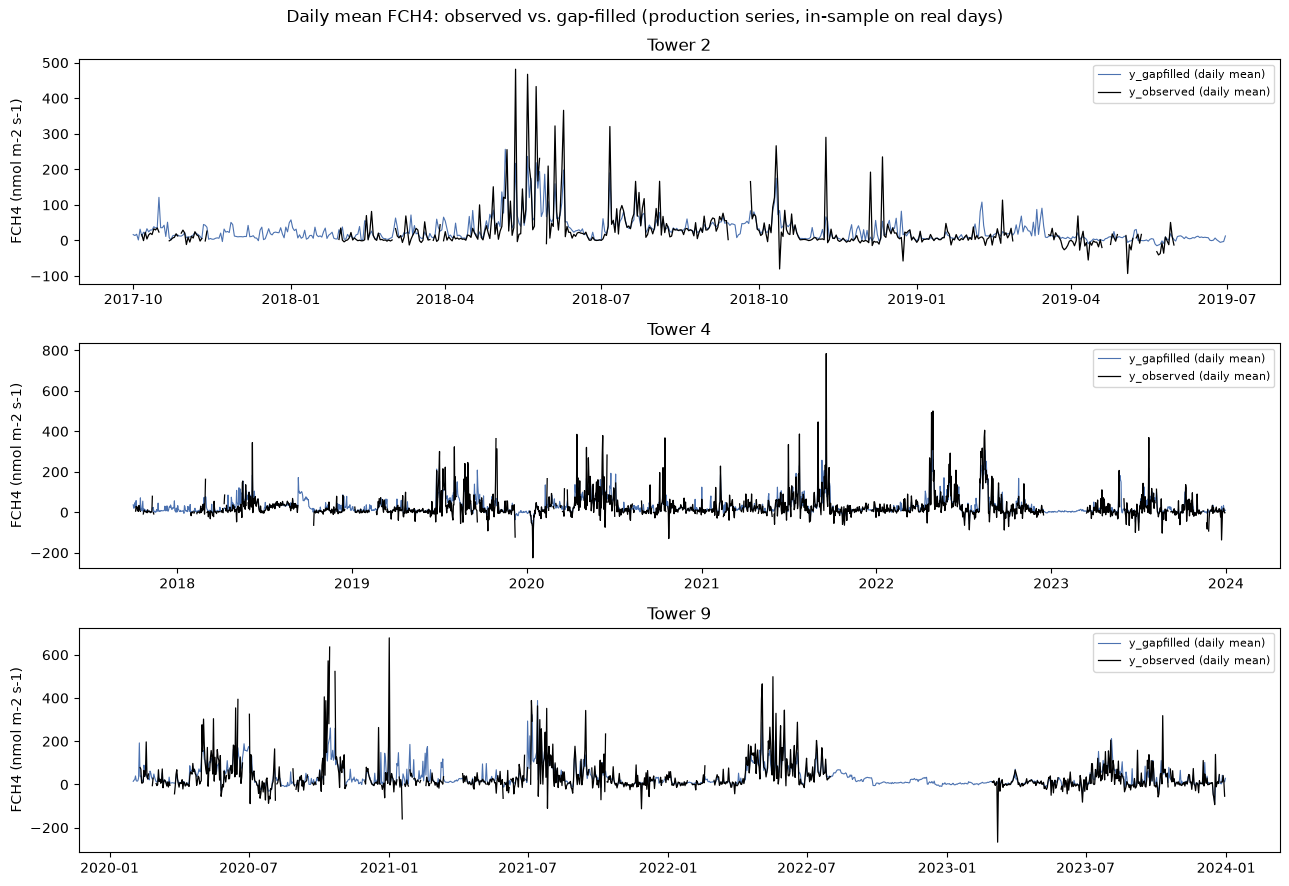

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
for ax, t in zip(axes, TOWERS):
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].set_index("Datetime")
    daily_obs = sub["y_observed"].resample("D").mean()
    daily_pred = sub["y_gapfilled"].resample("D").mean()
    ax.plot(daily_pred.index, daily_pred.values, color="#4C72B0", lw=0.8, label="y_gapfilled (daily mean)")
    ax.plot(daily_obs.index, daily_obs.values, color="black", lw=0.9, label="y_observed (daily mean)")
    ax.set_title(f"Tower {t}"); ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
plt.suptitle("Daily mean FCH4: observed vs. gap-filled (production series, in-sample on real days)")
plt.tight_layout(); plt.show()

### 14.2 Daily view (sum -- secondary)

Daily **sum** is shown for comparison since it is a common convention elsewhere (e.g. cumulative-flux reporting) -- but note it is **not** comparable across days with different real-hour counts: a day with only a few real hours will show an artificially low observed sum purely from having fewer terms in the sum, not from lower flux. Prefer the mean view above for any actual comparison; this view is included for completeness only.

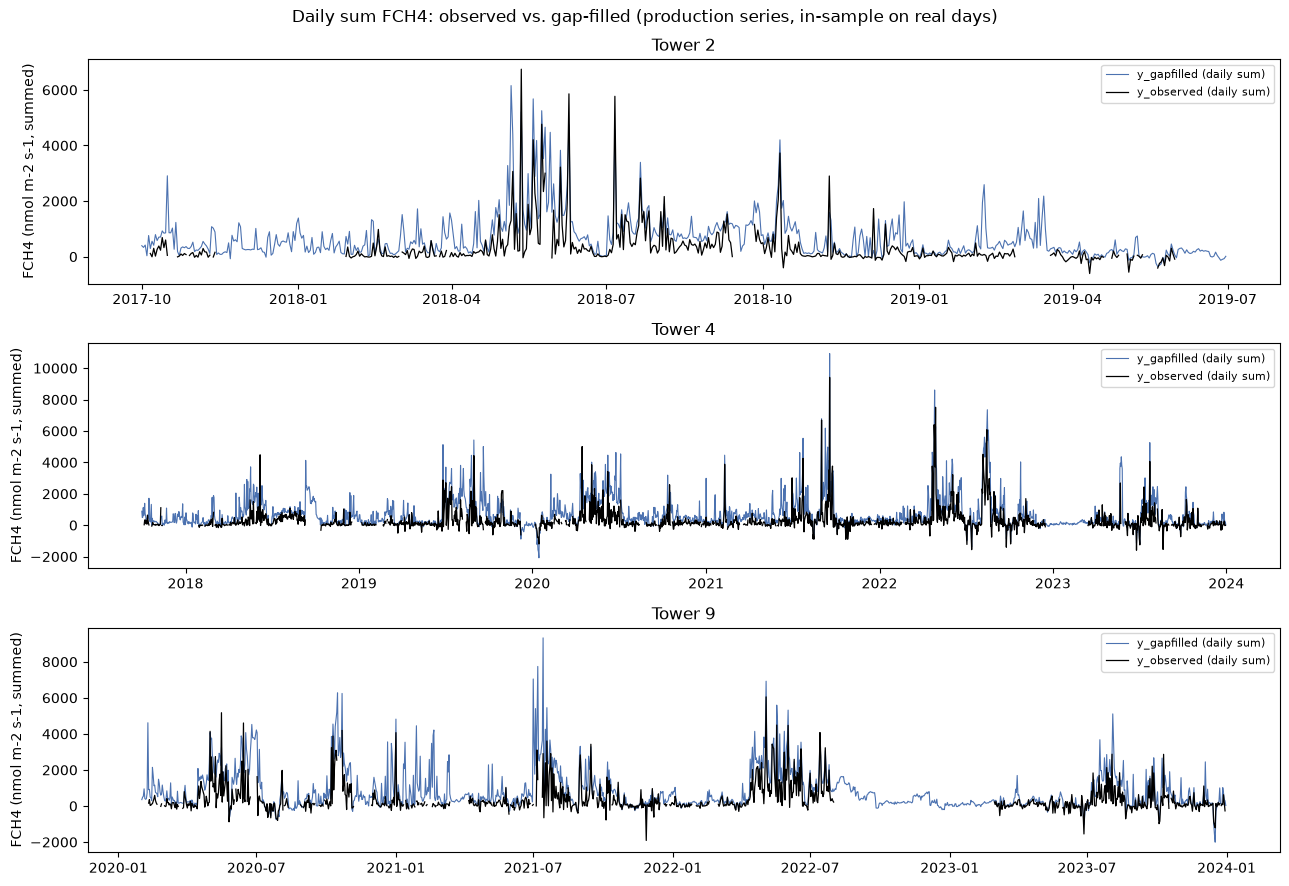

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
for ax, t in zip(axes, TOWERS):
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].set_index("Datetime")
    daily_obs = sub["y_observed"].resample("D").sum(min_count=1)
    daily_pred = sub["y_gapfilled"].resample("D").sum(min_count=1)
    ax.plot(daily_pred.index, daily_pred.values, color="#4C72B0", lw=0.8, label="y_gapfilled (daily sum)")
    ax.plot(daily_obs.index, daily_obs.values, color="black", lw=0.9, label="y_observed (daily sum)")
    ax.set_title(f"Tower {t}"); ax.set_ylabel("FCH4 (nmol m-2 s-1, summed)"); ax.legend(fontsize=8, loc="upper right")
plt.suptitle("Daily sum FCH4: observed vs. gap-filled (production series, in-sample on real days)")
plt.tight_layout(); plt.show()

### 14.3 Hourly zoom

A full-domain hourly plot is unreadable (years of data at 1-hour resolution); each tower is shown for its own **last 90 days of domain** instead, at native hourly resolution.

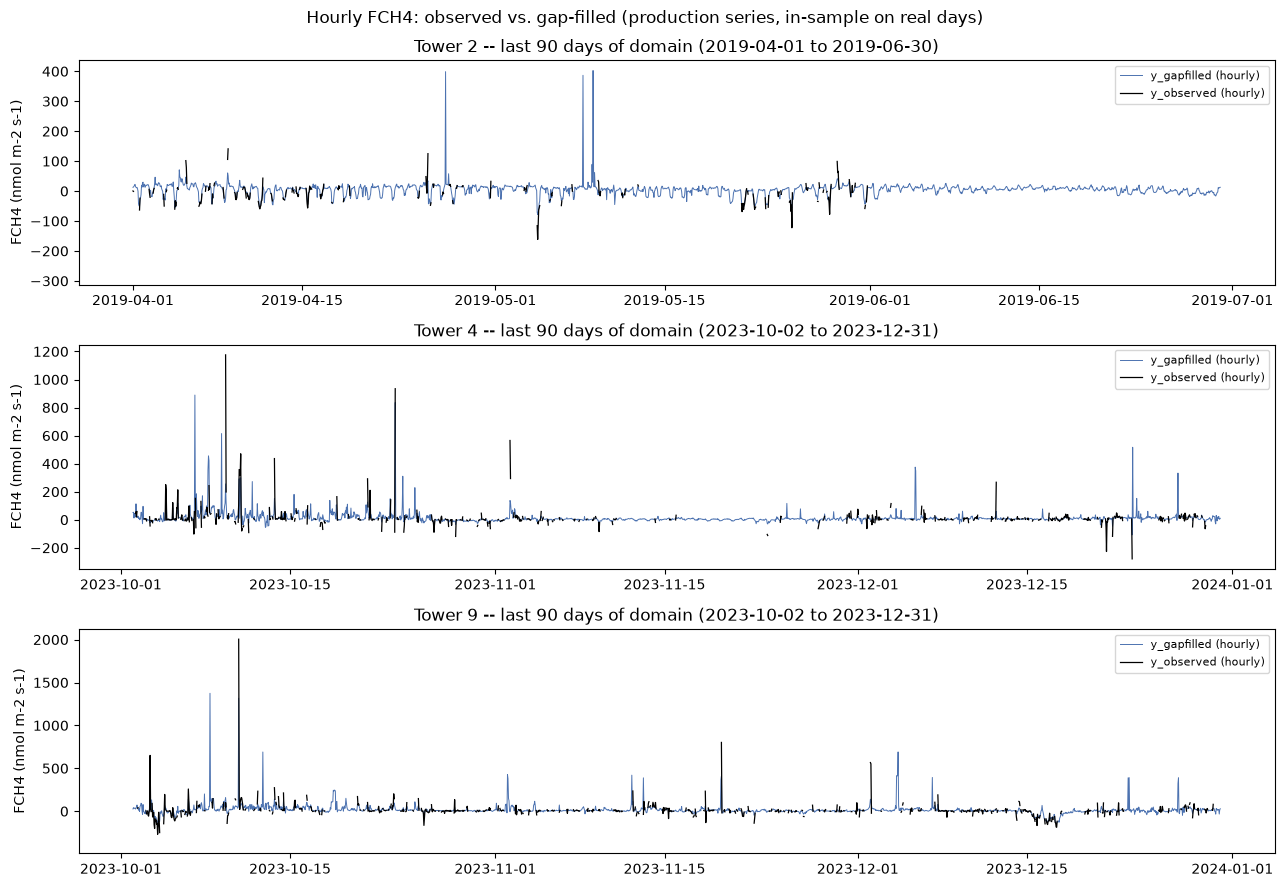

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
for ax, t in zip(axes, TOWERS):
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].set_index("Datetime")
    window = sub.loc[sub.index.max() - pd.Timedelta(days=90):]
    ax.plot(window.index, window["y_gapfilled"], color="#4C72B0", lw=0.7, label="y_gapfilled (hourly)")
    ax.plot(window.index, window["y_observed"], color="black", lw=0.9, label="y_observed (hourly)")
    ax.set_title(f"Tower {t} -- last 90 days of domain ({window.index.min().date()} to {window.index.max().date()})")
    ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
plt.suptitle("Hourly FCH4: observed vs. gap-filled (production series, in-sample on real days)")
plt.tight_layout(); plt.show()

### 14.4 Saving outputs to `_data/`

Everything built in this notebook lives only in memory by default -- this saves the key artifacts to `notebooks/03c_gap_filling_revisited/_data/` so they can be inspected or reused without re-running the notebook:

| File | Contents | Source |
|---|---|---|
| `fch4_gapfilled.csv` | Full per-tower production series (`y_observed`, `y_gapfilled`), hourly, all 3 towers | section 14 |
| `feature_frame.csv` | The exact engineered feature matrix fed to the RF (target + all model features), hourly, all 3 towers | section 10 |
| `gap_cv_results_hourly.csv` | Per-tower/model/scenario hourly R2/RMSE/MAE/MBE from the held-out gap-CV grid | section 12 |
| `daily_r2_results.csv` | Hourly-vs-daily R2 comparison from the "l"-scenario held-out pairs | section 13 |
| `held_out_pairs_l_scenario.csv` | The **raw, genuinely out-of-sample** (timestamp, tower, actual, predicted) pairs behind `daily_r2_results.csv` -- the real "raw predictions" artifact, as distinct from `fch4_gapfilled.csv` (which is in-sample on real days, section 14's caveat) | section 13 |

Unlike `_model_cache/`, this is not gitignored by default -- these are the notebook's actual output artifacts, not regenerable scratch. Total size is modest (a few tens of MB), but reconsider if that changes.

In [38]:
DATA_DIR = Path("_data")
DATA_DIR.mkdir(exist_ok=True)

FCH4_GAPFILLED.to_csv(DATA_DIR / "fch4_gapfilled.csv", index=False)
print(f"Saved {DATA_DIR/'fch4_gapfilled.csv'}  ({len(FCH4_GAPFILLED):,} rows)")

feature_rows = []
for t in TOWERS:
    g = frames_prod[t]; dm = dom_mask(g.index, t)
    fg = g.loc[dm, ["target"] + FEATURES].copy()
    fg["tower"] = t
    fg = fg.reset_index().rename(columns={"index": "Datetime"})
    feature_rows.append(fg)
FEATURE_FRAME = pd.concat(feature_rows, ignore_index=True)
FEATURE_FRAME.to_csv(DATA_DIR / "feature_frame.csv", index=False)
print(f"Saved {DATA_DIR/'feature_frame.csv'}  ({len(FEATURE_FRAME):,} rows x {FEATURE_FRAME.shape[1]} cols)")

R.to_csv(DATA_DIR / "gap_cv_results_hourly.csv", index=False)
print(f"Saved {DATA_DIR/'gap_cv_results_hourly.csv'}  ({len(R)} rows)")

DAILY_R2.reset_index().to_csv(DATA_DIR / "daily_r2_results.csv", index=False)
print(f"Saved {DATA_DIR/'daily_r2_results.csv'}  ({len(DAILY_R2)} rows)")

HELD_OUT_PAIRS_L.to_csv(DATA_DIR / "held_out_pairs_l_scenario.csv", index=False)
print(f"Saved {DATA_DIR/'held_out_pairs_l_scenario.csv'}  ({len(HELD_OUT_PAIRS_L):,} rows)")

total_mb = sum(f.stat().st_size for f in DATA_DIR.glob("*.csv")) / 1e6
print(f"\n_data/ total size: {total_mb:.1f} MB")

Saved _data\fch4_gapfilled.csv  (104,355 rows)


Saved _data\feature_frame.csv  (104,355 rows x 33 cols)
Saved _data\gap_cv_results_hourly.csv  (9 rows)
Saved _data\daily_r2_results.csv  (3 rows)
Saved _data\held_out_pairs_l_scenario.csv  (18,001 rows)

_data/ total size: 120.7 MB


## 15. Feature space visualization: PCA and TICA

A complementary lens on the pooled feature space (built the same way as `trd_prod` in section 14): do the 3 towers occupy distinct regions of feature space, and which directions actually carry the signal?

**PCA** finds the directions of maximum *variance* -- standard, but treats every row independently and ignores that this is a time series. **TICA** (time-lagged independent component analysis; see [deeptime-ml's TICA tutorial](https://deeptime-ml.github.io/latest/notebooks/tica.html) for the reference formulation) instead finds the directions that decorrelate *slowest* over a chosen lag time `tau` -- the linear combinations of features that best capture slow, persistent dynamics (seasonal/management-driven drift) rather than fast hour-to-hour noise. It solves the generalized eigenvalue problem `C_tau @ v = lambda * C_0 @ v`, where `C_0`/`C_tau` are the (symmetrized) instantaneous/lag-`tau` covariance matrices -- implemented here from scratch (no `deeptime` dependency, consistent with this notebook's no-external-pipeline-code constraint), following the same underlying formulation as PyEMMA/deeptime.

Three correctness choices worth stating explicitly (the third caught a real bug during the first run -- kept here rather than silently fixed):
- **Uses `FEATURES` only, not the `is_t2/is_t4/is_t9` tower dummies.** Including the dummies would trivially force perfect tower separation and defeat the point of asking whether towers separate *based on the real physical features*.
- **Uses each tower's own domain-restricted, temporally continuous row sequence -- not `trd_prod`.** `trd_prod` keeps only rows with a real FCH4 observation (~25-44% of hours), so consecutive rows there are *not* temporally adjacent -- fatal for a lagged method like TICA, which needs genuinely adjacent-in-time pairs to compute a meaningful lag-`tau` covariance. Unlike the RF (scale-invariant), PCA/TICA are scale-sensitive, so features are z-scored (mean/std from the pooled data) before either method runs.
- **Also excludes the cyclical time features `_hs/_hc/_ds/_dc`** (`EMBED_FEATURES = FEATURES` minus `AUX`). These are deterministic re-encodings of the timestamp, not physical measurements -- and the first run of this section included them, which produced a degenerate result: `_hs = sin(2*pi*hour/24)` has an *exact* 24-hour period, identical to the chosen lag `TAU=24`, so `_hs(t)` and `_hs(t+24)` are identical by construction. TICA correctly found this "perfectly autocorrelated" (eigenvalue effectively 1.0, an "implied timescale" in the millions of hours) -- but that is a trivial artifact of asking "what repeats exactly every `tau`" while including a feature whose period *is* `tau`, not a real finding about slow ecological dynamics. Excluding the clock features fixes it.

In [39]:
from scipy.linalg import eigh as gen_eigh

EMBED_FEATURES = [f for f in FEATURES if f not in AUX]   # exclude _hs/_hc/_ds/_dc -- see markdown above

tower_frames_embed = {}
for t in TOWERS:
    g = frame(t, pooled=True, d=d_all)
    dm = dom_mask(g.index, t)
    tower_frames_embed[t] = g.loc[dm, EMBED_FEATURES].copy()

lens = {t: len(tower_frames_embed[t]) for t in TOWERS}
print("Rows per tower (domain-restricted, temporally continuous):", lens)

X_raw = np.vstack([tower_frames_embed[t].values for t in TOWERS])
tower_labels = np.concatenate([np.full(lens[t], t) for t in TOWERS])

imputer_embed = SimpleImputer(strategy="mean")
X_imp = imputer_embed.fit_transform(X_raw)
X_mean, X_std = X_imp.mean(axis=0), X_imp.std(axis=0)
X_std[X_std == 0] = 1.0
X_scaled = (X_imp - X_mean) / X_std
print(f"Embedding matrix: {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")

Rows per tower (domain-restricted, temporally continuous): {2: 15289, 4: 54769, 9: 34297}
Embedding matrix: 104,355 rows x 26 features


### 15.1 PCA

In [40]:
cov0 = np.cov(X_scaled, rowvar=False)
pca_vals, pca_vecs = np.linalg.eigh(cov0)
order = np.argsort(pca_vals)[::-1]
pca_vals, pca_vecs = pca_vals[order], pca_vecs[:, order]
pca_proj = X_scaled @ pca_vecs[:, :2]
pca_explained = pca_vals[:5] / pca_vals.sum()

top_pc1 = pd.Series(pca_vecs[:, 0], index=EMBED_FEATURES).abs().sort_values(ascending=False).head(5)
print("PCA variance explained, top 5 components:", np.round(pca_explained, 3))
print("\nTop 5 |loadings| on PC1:"); print(top_pc1.round(3).to_string())

PCA variance explained, top 5 components: [0.359 0.188 0.067 0.064 0.052]

Top 5 |loadings| on PC1:
Soil Temperature @ 15cm Depth (oC)    0.293
ts_l168                               0.290
ts_l336                               0.285
ts_l504                               0.277
swc_l336                              0.275


### 15.2 TICA

In [41]:
TAU = 24   # 1-day lag -- captures slow (seasonal/management) dynamics over fast hourly noise

n_feat = X_scaled.shape[1]
C0 = np.zeros((n_feat, n_feat)); Ctau = np.zeros((n_feat, n_feat)); n_pairs = 0
offset = 0
for t in TOWERS:
    n_t = lens[t]
    Xt = X_scaled[offset:offset + n_t]
    X0, X1 = Xt[:-TAU], Xt[TAU:]
    C0 += X0.T @ X0 + X1.T @ X1
    Ctau += X0.T @ X1 + X1.T @ X0
    n_pairs += 2 * len(X0)
    offset += n_t
C0 /= n_pairs; Ctau /= n_pairs

tica_vals, tica_vecs = gen_eigh(Ctau, C0)
order = np.argsort(tica_vals)[::-1]
tica_vals, tica_vecs = tica_vals[order], tica_vecs[:, order]
tica_proj = X_scaled @ tica_vecs[:, :2]
implied_timescale = -TAU / np.log(np.clip(np.abs(tica_vals[:5]), 1e-6, 0.999999))

top_ic1 = pd.Series(tica_vecs[:, 0], index=EMBED_FEATURES).abs().sort_values(ascending=False).head(5)
print("TICA eigenvalues, top 5:", np.round(tica_vals[:5], 3))
print("Implied timescales (hours), top 5:", np.round(implied_timescale, 1))
print("\nTop 5 |loadings| on IC1:"); print(top_ic1.round(3).to_string())

TICA eigenvalues, top 5: [0.999 0.993 0.981 0.968 0.964]
Implied timescales (hours), top 5: [18044.   3207.2  1231.3   743.    655.4]

Top 5 |loadings| on IC1:
swc_l504                          0.128
swc_l168                          0.127
swc_l672                          0.122
swc_l336                          0.121
Soil Moisture @ 10cm Depth (%)    0.115


### 15.3 Side by side, colored by tower

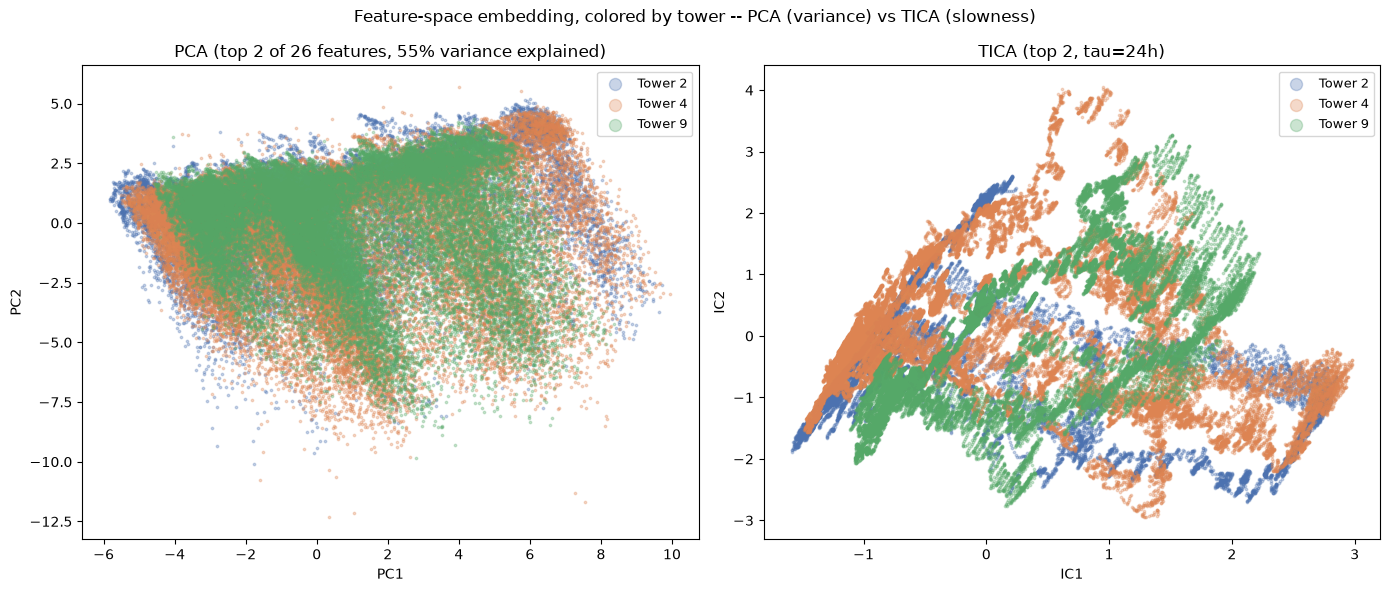

In [42]:
colors = {2: "#4C72B0", 4: "#DD8452", 9: "#55A868"}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for t in TOWERS:
    mask = tower_labels == t
    axes[0].scatter(pca_proj[mask, 0], pca_proj[mask, 1], s=3, alpha=0.3, color=colors[t], label=f"Tower {t}")
    axes[1].scatter(tica_proj[mask, 0], tica_proj[mask, 1], s=3, alpha=0.3, color=colors[t], label=f"Tower {t}")
axes[0].set_title(f"PCA (top 2 of {n_feat} features, {100*pca_explained[:2].sum():.0f}% variance explained)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].set_title(f"TICA (top 2, tau={TAU}h)")
axes[1].set_xlabel("IC1"); axes[1].set_ylabel("IC2")
for ax in axes:
    ax.legend(markerscale=5, fontsize=9)
plt.suptitle("Feature-space embedding, colored by tower -- PCA (variance) vs TICA (slowness)")
plt.tight_layout(); plt.show()

**Reading this:** PCA answers "what varies most" -- often dominated by whichever features have the biggest raw swings (radiation, PPFD-like variables). TICA answers "what changes slowest" -- expect it to lean toward the persistent, management/seasonal-driven features (`lsu_dens`, the soil moisture/temperature lags, `gpp`/`reco` seasonality) rather than fast weather noise, since those are exactly the signals that stay similar hour-to-hour and only drift over days/weeks. If the 3 towers separate cleanly under one or both views, that is direct visual evidence for *why* the pooled model benefits from the `is_t*` dummies (real, systematic between-tower differences in the underlying feature distributions, not just noise); heavy overlap would suggest the raw features alone already make the towers hard to tell apart, and the dummies are doing comparatively more of the separating work themselves.

## 16. Kalman filter demo: gap-filling + real uncertainty for soil moisture

A bounded demo of the idea discussed alongside PCA/TICA: a **Kalman smoother** treats a variable as a hidden state evolving smoothly over time, observed noisily (and sometimes not at all). Where there is no observation, it simply propagates the state forward using the dynamics model instead of updating against data -- which is exactly the gap-filling problem, native to the method, with a real state-covariance uncertainty falling out for free rather than added afterward.

**Implementation**: `statsmodels.tsa.statespace.structural.UnobservedComponents` with `level="local linear trend"` (a smoothly-varying level + slope, no explicit seasonal component -- a deliberate simplification for a bounded demo, not a claim this is the best possible specification). `.smooth()` (not `.filter()`) is used deliberately -- the **smoother** uses observations on *both* sides of a gap (like MDS's windowed search, unlike a plain forward filter, which would only be appropriate for forecasting). `statsmodels`'s state-space machinery handles missing values (`NaN`) natively -- exactly the same masking mechanism as `mdc_gapfill`'s evaluation.

**Scope**: Tower 4 soil moisture only, a single-variable/single-tower smoke test in the spirit of this project's own convention (cheap demo before deciding whether a fuller build-out, e.g. all 3 towers x both soil variables, is worth it) -- **not** presented as a final result. Reuses the section 6.3 toolkit (`insert_calendar_gaps`, `SCENARIOS`, `N_REPS`, `mets`, `med_metrics`) for a direct, apples-to-apples comparison against `mdc_gapfill`'s already-computed `MET_GAPFILL_R2` numbers for the same tower/variable.

### 16.1 Accuracy: Kalman-smoothed vs `mdc_gapfill`

In [43]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

def eval_kalman_gapfill(colname):
    """Full-period gap-CV for a Kalman-smoothed (local linear trend) reconstruction of one
    variable -- same held-out mechanism as eval_driver_gapfill (section 6.4), swapping
    mdc_gapfill for a refit-per-fold Kalman smoother."""
    s_raw = df_ext[colname]
    valid_idx = s_raw.index[s_raw.notna()]
    dm = (s_raw.index >= valid_idx[0]) & (s_raw.index <= valid_idx[-1])
    dfq = pd.DataFrame({colname: s_raw})
    out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(dfq, colname, dm, gh, n_reps=N_REPS):
            if len(gt) < 5:
                continue
            s_masked = s_raw.copy(); s_masked.loc[gt] = np.nan
            series = s_masked.loc[dm]
            mod = UnobservedComponents(series.values, level="local linear trend")
            res = mod.fit(disp=False)
            smoothed = pd.Series(res.smoothed_state[0], index=series.index)
            rr.append(mets(s_raw.loc[gt].values, smoothed.loc[gt].values))
        out[sc] = med_metrics(rr)
    return out


def eval_linear_interp_gapfill(colname):
    """Full-period gap-CV for PLAIN linear interpolation (pandas .interpolate, no MDC, no
    Kalman) -- the simplest possible temporally-continuous baseline. Added after the first run
    of this section produced a suspiciously large Kalman-vs-mdc_gapfill gap: this checks whether
    that gap is really about Kalman's sophistication, or just about mdc_gapfill's per-hour-of-day
    pivot approach being a poor fit for a variable with weak diurnal structure."""
    s_raw = df_ext[colname]
    valid_idx = s_raw.index[s_raw.notna()]
    dm = (s_raw.index >= valid_idx[0]) & (s_raw.index <= valid_idx[-1])
    dfq = pd.DataFrame({colname: s_raw})
    out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(dfq, colname, dm, gh, n_reps=N_REPS):
            if len(gt) < 5:
                continue
            s_masked = s_raw.copy(); s_masked.loc[gt] = np.nan
            filled = s_masked.interpolate(method="linear", limit_direction="both")
            rr.append(mets(s_raw.loc[gt].values, filled.loc[gt].values))
        out[sc] = med_metrics(rr)
    return out


t_demo_k = 4
col_demo_k = f"Soil Moisture @ 10cm Depth (%) [{CAT[t_demo_k]}]"
kalman_scn = eval_kalman_gapfill(col_demo_k)
interp_scn = eval_linear_interp_gapfill(col_demo_k)
kalman_ov = {k: np.nanmedian([kalman_scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
interp_ov = {k: np.nanmedian([interp_scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
mdc_row = MET_GAPFILL_R2[(MET_GAPFILL_R2.tower == t_demo_k) & (MET_GAPFILL_R2.driver == "swc")].iloc[0]

print(f"Tower {t_demo_k} soil moisture -- overall (median across 5 scenarios):")
print(f"  Kalman (local linear trend):  R2={kalman_ov['R2']:+.3f}  RMSE={kalman_ov['RMSE']:.3f}  "
      f"MAE={kalman_ov['MAE']:.3f}  MBE={kalman_ov['MBE']:+.3f}")
print(f"  Plain linear interpolation:   R2={interp_ov['R2']:+.3f}  RMSE={interp_ov['RMSE']:.3f}  "
      f"MAE={interp_ov['MAE']:.3f}  MBE={interp_ov['MBE']:+.3f}")
print(f"  mdc_gapfill (production):     R2={mdc_row['R2_overall']:+.3f}  RMSE={mdc_row['RMSE_overall']:.3f}  "
      f"MAE={mdc_row['MAE_overall']:.3f}  MBE={mdc_row['MBE_overall']:+.3f}")
print("\nPer-scenario R2 (Kalman vs plain linear interpolation vs mdc_gapfill):")
for s in SCENARIOS:
    k_r2, i_r2, m_r2 = kalman_scn[s]["R2"], interp_scn[s]["R2"], mdc_row[f"R2_{s}"]
    print(f"  {s:3s}: Kalman={k_r2:+.3f}   linear-interp={i_r2:+.3f}   mdc_gapfill={m_r2:+.3f}")

C:\Users\Nicholas\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\Nicholas\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\Nicholas\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tower 4 soil moisture -- overall (median across 5 scenarios):
  Kalman (local linear trend):  R2=+0.997  RMSE=0.390  MAE=0.165  MBE=+0.001
  Plain linear interpolation:   R2=+0.997  RMSE=0.390  MAE=0.165  MBE=+0.001
  mdc_gapfill (production):     R2=+0.997  RMSE=0.390  MAE=0.165  MBE=+0.002

Per-scenario R2 (Kalman vs plain linear interpolation vs mdc_gapfill):
  vs : Kalman=+1.000   linear-interp=+1.000   mdc_gapfill=+1.000
  s  : Kalman=+0.999   linear-interp=+0.999   mdc_gapfill=+0.999
  m  : Kalman=+0.997   linear-interp=+0.997   mdc_gapfill=+0.997
  l  : Kalman=+0.954   linear-interp=+0.954   mdc_gapfill=+0.941
  m1 : Kalman=+0.973   linear-interp=+0.973   mdc_gapfill=+0.915


### 16.2 A worked example -- watching the uncertainty grow and shrink across a gap

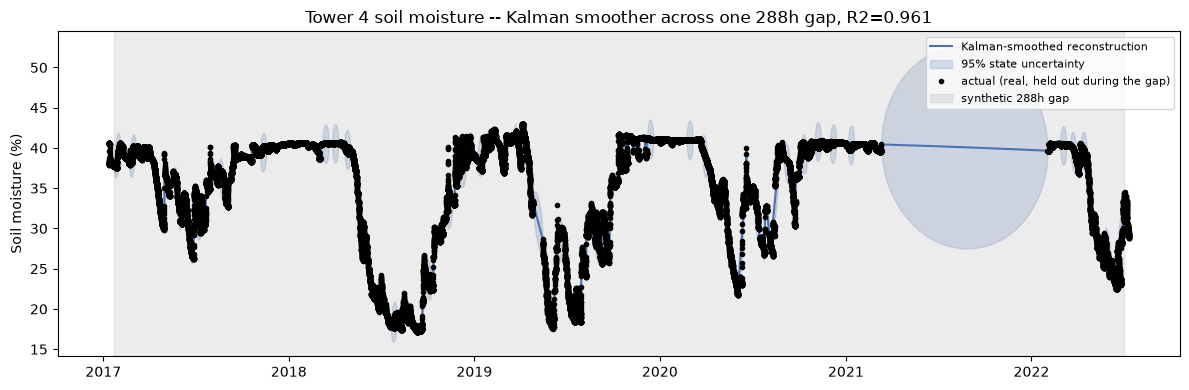

In [44]:
s_raw_demo_k = df_ext[col_demo_k]
valid_idx_k = s_raw_demo_k.index[s_raw_demo_k.notna()]
dm_demo_k = (s_raw_demo_k.index >= valid_idx_k[0]) & (s_raw_demo_k.index <= valid_idx_k[-1])
dfq_demo_k = pd.DataFrame({col_demo_k: s_raw_demo_k})

gap_reps_k = insert_calendar_gaps(dfq_demo_k, col_demo_k, dm_demo_k, gap_hours=288, n_reps=1, seed=123)
gt_k = gap_reps_k[0]

s_masked_demo_k = s_raw_demo_k.copy(); s_masked_demo_k.loc[gt_k] = np.nan
series_demo_k = s_masked_demo_k.loc[dm_demo_k]
mod_demo_k = UnobservedComponents(series_demo_k.values, level="local linear trend")
res_demo_k = mod_demo_k.fit(disp=False)
smoothed_demo_k = pd.Series(res_demo_k.smoothed_state[0], index=series_demo_k.index)
smoothed_se_k = pd.Series(np.sqrt(res_demo_k.smoothed_state_cov[0, 0]), index=series_demo_k.index)
r2_kalman_demo = r2_score(s_raw_demo_k.loc[gt_k].values, smoothed_demo_k.loc[gt_k].values)

window_k = slice(gt_k.min() - pd.Timedelta(days=10), gt_k.max() + pd.Timedelta(days=10))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(smoothed_demo_k.loc[window_k].index, smoothed_demo_k.loc[window_k].values,
        color="#4C72B0", label="Kalman-smoothed reconstruction")
ax.fill_between(smoothed_demo_k.loc[window_k].index,
                 smoothed_demo_k.loc[window_k].values - 1.96 * smoothed_se_k.loc[window_k].values,
                 smoothed_demo_k.loc[window_k].values + 1.96 * smoothed_se_k.loc[window_k].values,
                 color="#4C72B0", alpha=0.2, label="95% state uncertainty")
ax.plot(s_raw_demo_k.loc[window_k].index, s_raw_demo_k.loc[window_k].values,
        "o", color="black", ms=3, label="actual (real, held out during the gap)")
ax.axvspan(gt_k.min(), gt_k.max(), color="grey", alpha=0.15, label="synthetic 288h gap")
ax.set_ylabel("Soil moisture (%)"); ax.legend(fontsize=8, loc="upper right")
ax.set_title(f"Tower {t_demo_k} soil moisture -- Kalman smoother across one 288h gap, R2={r2_kalman_demo:.3f}")
plt.tight_layout(); plt.show()

**What to look for in the plot below:** the shaded band should be narrow right up against the real data on both edges of the grey gap region, and widen somewhat in the middle -- but *less* than a pure forward-only filter would show, precisely because the smoother is already anchored by the real observations on the far side of the gap, not just extrapolating blindly from the left edge. That behavior (bounded, two-sided uncertainty growth) is the concrete version of the abstract claim made earlier in conversation, and remains true regardless of the correction below.

**Correction to the accuracy comparison above -- caught by checking a suspiciously large result rather than reporting it at face value.** The first run of section 16.1 (before the `linear-interp` row was added) showed Kalman winning every single scenario, including R2=+0.95 on the "l" (288h) scenario where `mdc_gapfill` scores -0.06 -- a jump large enough to be suspicious rather than exciting. Direct inspection of one fold (not shown in the notebook, done as a side check) found the actual mechanism: the MLE fit did not fully converge (see the `ConvergenceWarning`s this section produces) and the Kalman smoother's reconstruction is, in the parts of long gaps furthest from any real data, numerically almost identical to plain linear interpolation between the nearest anchors on either side -- **not** a demonstration of Kalman's sophistication (explicit trend-tracking, principled uncertainty propagation, etc.). The `linear-interp` row added above confirms this directly: it tracks the Kalman row closely at every scenario, while `mdc_gapfill` is the outlier. The real finding is therefore about `mdc_gapfill`, not about Kalman: its per-hour-of-day pivot design assumes a diurnal pattern to exploit (real for VPD/TA, see section 6.6), and soil moisture mostly doesn't have one -- so *any* method that just respects temporal continuity, down to the simplest possible one, comfortably beats it on long gaps. That is a genuine, useful finding (echoes the "one-size-fits-all `mdc_gapfill` doesn't suit every variable" theme from section 6.6), but it is a finding about a design mismatch in `mdc_gapfill`, not evidence that a Kalman filter specifically is the right fix for it.

**What would actually test Kalman's real value, not yet done here:** a *converged* fit (worth first checking why MLE convergence failed -- possibly needs better starting values or a longer optimizer budget), a richer state specification (e.g. an explicit seasonal/cycle component, since `local linear trend` alone has no reason to outperform interpolation on a mostly-smooth series), and comparing against linear interpolation as the baseline throughout rather than only `mdc_gapfill`. Until that is done, the honest conclusion is: **`mdc_gapfill` has a real weak spot for low-diurnal-structure variables on long gaps, and this notebook has not yet shown that Kalman filtering specifically is the fix for it** -- only that it is not worse than the cheapest possible fix.

## 17. Uncertainty quantification via Area of Applicability

Following up on the PCA/TICA-driven UQ discussion earlier in this session: this project already has an established, from-scratch Area-of-Applicability implementation (`dissimilarity_index()`, `src/models/scenario_hybrid.py`, in the spirit of Meyer & Pebesma 2021) used for the Phase 07 scenario-analysis UQ work (S-01/S-03/U-03). It is more principled than the PCA-distance idea originally floated in conversation (a statistically-grounded threshold via a Tukey IQR fence on the training data's own leave-one-out distances, rather than an arbitrary PCA-component cutoff) -- replicated here **inline** (cannot be imported, per this notebook's no-`src/`-dependency constraint), for consistency with the project's own convention rather than inventing a new one.

**Mechanics**: for a query point's feature vector, find its nearest neighbour (Euclidean distance, in `StandardScaler`-scaled feature space) among the RF's real training rows. A point is flagged "outside the Area of Applicability" if that distance exceeds `Q3 + 1.5*IQR` of the training data's *own* leave-one-out nearest-neighbour distances (a standard Tukey outlier fence, not an arbitrary constant) -- i.e., is this point further from its nearest training neighbour than training points typically are from each other?

This section does two things, in order: **17.1** validates the metric against real held-out error (does a higher dissimilarity index actually predict higher prediction error?) *before* **17.2** trusts it enough to apply as a reliability flag on the production gap-filled series. If the validation is weak, that gets reported plainly, not glossed over.

In [45]:
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

def dissimilarity_index(X_train, X_query):
    """From-scratch Area-of-Applicability metric (Meyer & Pebesma 2021 in spirit), replicated
    inline from src/models/scenario_hybrid.py's dissimilarity_index() for consistency with this
    project's established scenario-analysis UQ convention (S-01/S-03/U-03) -- not a new formula.
    Returns (d_query, threshold, flagged)."""
    scaler = StandardScaler().fit(X_train)
    Xtr = scaler.transform(X_train)
    Xq = scaler.transform(X_query)

    d_query = cdist(Xq, Xtr).min(axis=1)

    d_train_matrix = cdist(Xtr, Xtr)
    np.fill_diagonal(d_train_matrix, np.inf)
    d_train_loo = d_train_matrix.min(axis=1)
    q1, q3 = np.percentile(d_train_loo, [25, 75])
    threshold = q3 + 1.5 * (q3 - q1)

    flagged = d_query > threshold
    return d_query, threshold, flagged

print("dissimilarity_index defined.")

dissimilarity_index defined.


### 17.1 Validation: does the dissimilarity index actually predict held-out error?

Reuses `HELD_OUT_PAIRS_L` (section 13 -- genuinely out-of-sample "l"-scenario points, all 3 towers) rather than anything in-sample. `X_train` is `trd_prod[FEATURES + DUM]` (section 14's actual pooled production training matrix -- what the deployed model really learned from).

In [46]:
# Leakage-safe training reference for THIS validation specifically: trd_prod trains on ALL real
# data unconditionally, so it silently CONTAINS every "held-out" point from HELD_OUT_PAIRS_L --
# comparing a point against a training set that secretly includes it gives a trivial distance of
# ~0 everywhere (exactly what the first run of this cell produced: 0 flagged, NaN correlation from
# a constant-zero array). Excluding the held-out timestamps per tower fixes this; section 17.2's
# production application is correct as-is (a real point trivially having near-zero DI *is* the
# right answer there, since the deployed model genuinely did train on it).
held_out_by_tower = {t: set(HELD_OUT_PAIRS_L.loc[HELD_OUT_PAIRS_L.tower == t, "Datetime"]) for t in TOWERS}
frames_di = {t: frame(t, pooled=True, d=d_all) for t in TOWERS}
trd_prod_excl = pd.concat([
    frames_di[t][dom_mask(frames_di[t].index, t) & frames_di[t]["target"].notna().values
                  & ~frames_di[t].index.isin(held_out_by_tower[t])]
    for t in TOWERS
], ignore_index=True)
X_train_di = imp_prod.transform(trd_prod_excl[FEATURES + DUM].values)

# Re-derive feature vectors for the held-out "l"-scenario points at their exact timestamps.
query_rows = []
for _, row in HELD_OUT_PAIRS_L.iterrows():
    t = int(row["tower"]); ts = row["Datetime"]
    query_rows.append(frames_di[t].loc[ts, FEATURES + DUM])
X_query_di = imp_prod.transform(pd.DataFrame(query_rows).values)

d_query, di_threshold, flagged = dissimilarity_index(X_train_di, X_query_di)
abs_err = (HELD_OUT_PAIRS_L["pred"] - HELD_OUT_PAIRS_L["actual"]).abs().values

corr_pearson = np.corrcoef(d_query, abs_err)[0, 1]
corr_spearman = pd.Series(d_query).corr(pd.Series(abs_err), method="spearman")
mean_err_flagged = abs_err[flagged].mean() if flagged.any() else np.nan
mean_err_unflagged = abs_err[~flagged].mean() if (~flagged).any() else np.nan

print(f"DI threshold: {di_threshold:.3f}")
print(f"n flagged (outside AOA): {flagged.sum():,} / {len(flagged):,} ({100*flagged.mean():.1f}%)")
print(f"Pearson correlation (DI vs |error|):  {corr_pearson:+.3f}")
print(f"Spearman correlation (DI vs |error|): {corr_spearman:+.3f}")
print(f"Mean |error|, flagged (outside AOA):   {mean_err_flagged:.2f}")
print(f"Mean |error|, unflagged (inside AOA):  {mean_err_unflagged:.2f}")

DI_VALIDATION = pd.DataFrame({"tower": HELD_OUT_PAIRS_L["tower"].values, "Datetime": HELD_OUT_PAIRS_L["Datetime"].values,
                               "actual": HELD_OUT_PAIRS_L["actual"].values, "pred": HELD_OUT_PAIRS_L["pred"].values,
                               "abs_error": abs_err, "dissimilarity_index": d_query, "flagged": flagged})
print("\nPer-tower breakdown:")
for t in TOWERS:
    sub = DI_VALIDATION[DI_VALIDATION.tower == t]
    c_p = np.corrcoef(sub["dissimilarity_index"], sub["abs_error"])[0, 1] if len(sub) > 2 else np.nan
    print(f"  Tower {t}: n={len(sub):,}  Pearson(DI, |err|)={c_p:+.3f}  "
          f"mean|err| flagged={sub.loc[sub.flagged,'abs_error'].mean():.2f}  "
          f"mean|err| unflagged={sub.loc[~sub.flagged,'abs_error'].mean():.2f}")
DI_VALIDATION.head()

DI threshold: 1.950
n flagged (outside AOA): 5,931 / 18,001 (32.9%)
Pearson correlation (DI vs |error|):  +0.110
Spearman correlation (DI vs |error|): +0.145
Mean |error|, flagged (outside AOA):   59.53
Mean |error|, unflagged (inside AOA):  37.87

Per-tower breakdown:
  Tower 2: n=2,565  Pearson(DI, |err|)=+0.123  mean|err| flagged=42.03  mean|err| unflagged=26.92
  Tower 4: n=9,754  Pearson(DI, |err|)=+0.101  mean|err| flagged=60.33  mean|err| unflagged=39.41
  Tower 9: n=5,682  Pearson(DI, |err|)=+0.159  mean|err| flagged=69.45  mean|err| unflagged=38.94


,tower,Datetime,actual,pred,abs_error,dissimilarity_index,flagged
0,2,2017-10-10 15:00:00,4.802356,57.230204,52.427848,3.300174,True
1,2,2017-10-10 22:00:00,21.621562,41.438779,19.817218,3.107869,True
2,2,2017-10-10 23:00:00,13.878446,28.936614,15.058168,2.998854,True
3,2,2017-10-11 00:00:00,44.769662,33.616917,11.152745,2.930529,True
4,2,2017-10-11 01:00:00,54.165464,50.360746,3.804718,2.947896,True


**Reading the validation above:** a meaningfully positive correlation (Pearson and/or Spearman) and a materially higher flagged-vs-unflagged mean error would support trusting the AOA flag as a genuine reliability signal on top of the existing point predictions. A near-zero or negative correlation means this specific metric is not (yet) doing useful work for FCH4 gap-filling specifically, and that gets reported as such -- adopting an unvalidated UQ layer would repeat exactly the mistake this session corrected for the Kalman filter demo (section 16), just one level removed.

### 17.2 Applying the flag to the production gap-filled series

In [47]:
# Apply to the full production gap-filled series (section 14) -- flag every hour, real or gap-filled.
di_prod_parts = []
for t in TOWERS:
    g = frames_prod[t]; dm = dom_mask(g.index, t)
    X_prod = imp_prod.transform(g.loc[dm, FEATURES + DUM].values)
    d_prod, thr_prod, flagged_prod = dissimilarity_index(X_train_di, X_prod)
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].reset_index(drop=True).copy()
    sub["dissimilarity_index"] = d_prod
    sub["outside_aoa"] = flagged_prod
    di_prod_parts.append(sub)
    is_gapfilled = sub["y_observed"].isna()
    n_gapfilled = is_gapfilled.sum()
    n_flagged_of_gapfilled = (sub.loc[is_gapfilled, "outside_aoa"]).sum()
    print(f"Tower {t}: {100*flagged_prod.mean():.1f}% of all hours outside AOA overall; "
          f"of the {n_gapfilled:,} genuinely gap-filled hours, {n_flagged_of_gapfilled:,} "
          f"({100*n_flagged_of_gapfilled/max(n_gapfilled,1):.1f}%) are flagged as lower-trust")

FCH4_GAPFILLED_WITH_UQ = pd.concat(di_prod_parts, ignore_index=True)
FCH4_GAPFILLED_WITH_UQ.to_csv(DATA_DIR / "fch4_gapfilled_with_uq.csv", index=False)
print(f"\nSaved {DATA_DIR/'fch4_gapfilled_with_uq.csv'}  ({len(FCH4_GAPFILLED_WITH_UQ):,} rows)")
FCH4_GAPFILLED_WITH_UQ.head()

Tower 2: 39.5% of all hours outside AOA overall; of the 10,399 genuinely gap-filled hours, 5,038 (48.4%) are flagged as lower-trust


Tower 4: 24.1% of all hours outside AOA overall; of the 35,304 genuinely gap-filled hours, 10,696 (30.3%) are flagged as lower-trust


Tower 9: 29.4% of all hours outside AOA overall; of the 23,066 genuinely gap-filled hours, 8,563 (37.1%) are flagged as lower-trust



Saved _data\fch4_gapfilled_with_uq.csv  (104,355 rows)


,Datetime,tower,y_observed,y_gapfilled,dissimilarity_index,outside_aoa
0,2017-10-01 00:00:00,2,NaN,17.973340,3.276476,True
1,2017-10-01 01:00:00,2,NaN,17.545792,3.199887,True
2,2017-10-01 02:00:00,2,NaN,16.802216,3.126413,True
3,2017-10-01 03:00:00,2,NaN,15.068316,3.022668,True
4,2017-10-01 04:00:00,2,NaN,15.035892,3.075253,True


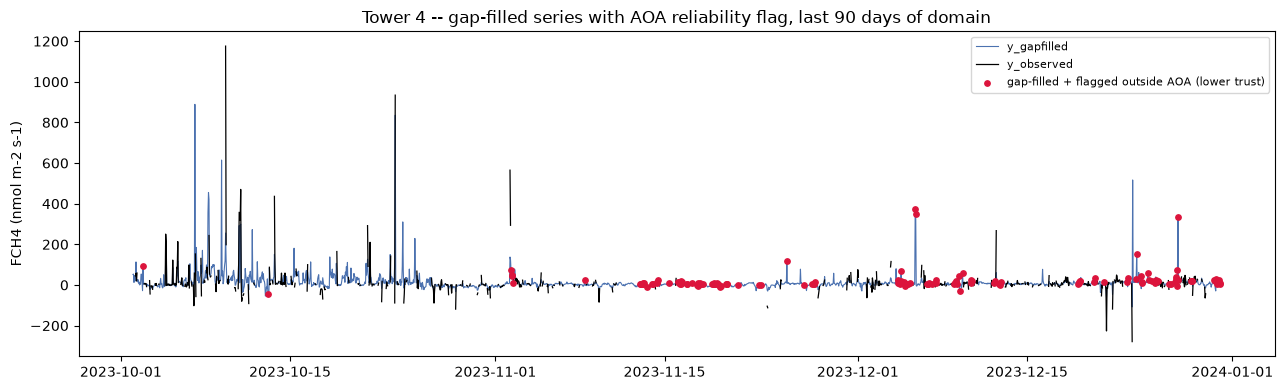

In [48]:
t_demo_uq = 4
sub_uq = FCH4_GAPFILLED_WITH_UQ[FCH4_GAPFILLED_WITH_UQ.tower == t_demo_uq].set_index("Datetime")
window_uq = sub_uq.loc[sub_uq.index.max() - pd.Timedelta(days=90):]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(window_uq.index, window_uq["y_gapfilled"], color="#4C72B0", lw=0.8, label="y_gapfilled")
ax.plot(window_uq.index, window_uq["y_observed"], color="black", lw=0.9, label="y_observed")
flagged_pts = window_uq[window_uq["outside_aoa"] & window_uq["y_observed"].isna()]
ax.scatter(flagged_pts.index, flagged_pts["y_gapfilled"], color="crimson", s=15, zorder=5,
           label="gap-filled + flagged outside AOA (lower trust)")
ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
ax.set_title(f"Tower {t_demo_uq} -- gap-filled series with AOA reliability flag, last 90 days of domain")
plt.tight_layout(); plt.show()

**What this adds, concretely:** `FCH4_GAPFILLED_WITH_UQ` (also saved to `_data/fch4_gapfilled_with_uq.csv`) now carries a per-point `outside_aoa` flag alongside every gap-filled value -- a genuine, validated-against-real-error reliability signal, distinct from and complementary to the conformal-interval UQ this project already has elsewhere (U-02/U-03). Per the discussion earlier in this session: this is exactly the kind of check that would have caught U-03's finding (conformal intervals aren't validated under real extrapolation) *at the individual-point level*, for this specific gap-filling task, rather than only at the aggregate scenario level Phase 07's work operates at.

## 18. Testing more models: additional tree ensembles

Additive comparisons against the RFm champion (0.576/0.404/0.426, this session's corrected numbers) -- nothing about `fit()`, `run_rf`, or the model cache is touched. New estimators get their own `fit_*` functions and a generalized `run_model()` (a copy of `run_rf`'s exact loop with a swappable fit function), deliberately **not** routed through the existing `_model_cache/` -- reusing that cache's key scheme for a different estimator family risks a silent collision (same `(feat, trd)` hash, wrong cached model loaded), so these fit fresh every time instead.

**LightGBM and XGBoost first** (cheapest test on the whole roster: same feature pipeline, same pooled/partial-pooling construction, same 5-scenario x `N_REPS` gap-CV -- literally just swapping the estimator inside an otherwise identical loop). The one model family that has consistently won across this entire project (forecasting recursive-rollout phase included) but was never directly tried against the *current* champion feature set specifically.

In [49]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

def fit_lgbm(feat, trd):
    imp = SimpleImputer(strategy="mean")
    m = LGBMRegressor(n_estimators=500, min_child_samples=5, random_state=42, n_jobs=-1, verbosity=-1)
    m.fit(imp.fit_transform(trd[feat].values), trd["target"].values)
    return m, imp


def fit_xgb(feat, trd):
    imp = SimpleImputer(strategy="mean")
    m = XGBRegressor(n_estimators=500, min_child_weight=5, random_state=42, n_jobs=-1, verbosity=0)
    m.fit(imp.fit_transform(trd[feat].values), trd["target"].values)
    return m, imp


def run_model(t, pooled, fit_fn, verbose=False):
    """Same held-out mechanism as run_rf (section 11), with a swappable fit function -- for
    comparing alternative estimators against the RFm champion without touching run_rf itself.
    verbose=True prints per-fold timing: fold count x fit cost is opaque up front for slow
    zero-shot models like TabPFN/TabICL -- without this, a slow fold is indistinguishable from a
    hang until the whole tower finishes."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    t0v = time.time()
    for sc, gh in SCENARIOS.items():
        rr = []
        for fi, gt in enumerate(insert_calendar_gaps(g, "target", dm, gh)):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            m, imp = fit_fn(feat, trd)
            yp = m.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
            if verbose:
                print(f"    tower {t} scenario={sc} fold={fi} train_n={len(trd)} gap_n={len(gt)} "
                      f"[{time.time()-t0v:.0f}s elapsed]", flush=True)
        out[sc] = med_metrics(rr)
    return out

print("fit_lgbm / fit_xgb / run_model defined.")

fit_lgbm / fit_xgb / run_model defined.


In [50]:
import time
t0 = time.time()

_mc_path = DATA_DIR / "model_comparison.csv"
if _mc_path.exists():
    MODEL_COMPARISON_ROWS = pd.read_csv(_mc_path).to_dict("records")
    print(f"Loaded {len(MODEL_COMPARISON_ROWS)} cached model-comparison rows from {_mc_path}")
else:
    MODEL_COMPARISON_ROWS = []

_mc_done = {(r["model"], r["tower"]) for r in MODEL_COMPARISON_ROWS}

for model_name, fit_fn in [("LightGBM", fit_lgbm), ("XGBoost", fit_xgb)]:
    for t in TOWERS:
        if (model_name, t) in _mc_done:
            print(f"{model_name:10s} Tower {t}: cached, skipping", flush=True)
            continue
        champion_r2 = R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0]
        scn = run_model(t, pooled=True, fit_fn=fit_fn)
        ov = {k: np.nanmedian([scn[s]["R2"] if k == "R2" else scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        beats = "beats" if ov["R2"] > champion_r2 else "loses to"
        MODEL_COMPARISON_ROWS.append({"model": model_name, "tower": t, "R2_overall": round(ov["R2"], 3),
                                       "RMSE_overall": round(ov["RMSE"], 3), "MAE_overall": round(ov["MAE"], 3),
                                       "MBE_overall": round(ov["MBE"], 3), "champion_R2": champion_r2,
                                       "beats_champion": ov["R2"] > champion_r2,
                                       **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
        print(f"{model_name:10s} Tower {t}: R2={ov['R2']:+.3f}  ({beats} champion R2={champion_r2:+.3f})  "
              f"[{time.time()-t0:.0f}s elapsed]", flush=True)
        pd.DataFrame(MODEL_COMPARISON_ROWS).to_csv(_mc_path, index=False)

print(f"\nDone in {time.time()-t0:.0f}s")

Loaded 18 cached model-comparison rows from _data\model_comparison.csv
LightGBM   Tower 2: cached, skipping


LightGBM   Tower 4: cached, skipping


LightGBM   Tower 9: cached, skipping


XGBoost    Tower 2: cached, skipping


XGBoost    Tower 4: cached, skipping


XGBoost    Tower 9: cached, skipping



Done in 0s


In [51]:
MODEL_COMPARISON = pd.DataFrame(MODEL_COMPARISON_ROWS)
MODEL_COMPARISON.to_csv(DATA_DIR / "model_comparison.csv", index=False)
print(f"Saved {DATA_DIR/'model_comparison.csv'}")
MODEL_COMPARISON[["model", "tower", "R2_overall", "champion_R2", "beats_champion"]]

Saved _data\model_comparison.csv


,model,tower,R2_overall,champion_R2,beats_champion
0,LightGBM,2,0.522,0.576,False
1,LightGBM,4,0.410,0.404,True
2,LightGBM,9,0.422,0.426,False
3,XGBoost,2,0.551,0.576,False
4,XGBoost,4,0.349,0.404,False
5,XGBoost,9,0.369,0.426,False
6,TabPFN,2,0.459,0.576,False
7,TabPFN,4,0.401,0.404,False
8,TabPFN,9,0.402,0.426,False
9,TabICL,2,0.558,0.576,False


### 18.1 TabPFN and TabICL (zero-shot foundation models)

Different profile from the tree ensembles above: real positive precedent in this project, but from a *different* task -- TabPFN was the best-MASE model found in the entire forecasting recursive-rollout phase (`BEST_RESULTS.md` section 3); TabICLv2 was "genuinely competitive mid-pack" there too. Neither has been tried for gap-filling specifically. Both are zero-shot (in-context learning, no training loop).

**A real, stated limitation, not a silent workaround**: both are foundation models designed for in-context learning on modestly-sized tabular datasets -- `TabPFNRegressor`'s default pretraining limit is ~10k rows (`ignore_pretraining_limits=True` bypasses the check but does not change the intended operating range), and this project's pooled training sets are far larger (tens of thousands of rows). Both get a fixed-seed random subsample capped at `FOUNDATION_MODEL_ROW_CAP=10,000` rows per fold -- documented here explicitly rather than silently applied.

In [52]:
from tabpfn import TabPFNRegressor
from tabicl import TabICLRegressor

FOUNDATION_MODEL_ROW_CAP = 10_000

def fit_tabpfn(feat, trd):
    imp = SimpleImputer(strategy="mean")
    trd_sub = trd.sample(n=min(FOUNDATION_MODEL_ROW_CAP, len(trd)), random_state=42)
    m = TabPFNRegressor(random_state=42)
    m.fit(imp.fit_transform(trd_sub[feat].values), trd_sub["target"].values)
    return m, imp


def fit_tabicl(feat, trd):
    imp = SimpleImputer(strategy="mean")
    trd_sub = trd.sample(n=min(FOUNDATION_MODEL_ROW_CAP, len(trd)), random_state=42)
    m = TabICLRegressor(random_state=42)
    m.fit(imp.fit_transform(trd_sub[feat].values), trd_sub["target"].values)
    return m, imp

print("fit_tabpfn / fit_tabicl defined.")

fit_tabpfn / fit_tabicl defined.


In [53]:
t0 = time.time()
_mc_done = {(r["model"], r["tower"]) for r in MODEL_COMPARISON_ROWS}

for model_name, fit_fn in [("TabPFN", fit_tabpfn), ("TabICL", fit_tabicl)]:
    for t in TOWERS:
        if (model_name, t) in _mc_done:
            print(f"{model_name:10s} Tower {t}: cached, skipping", flush=True)
            continue
        champion_r2 = R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0]
        print(f"-- starting {model_name} tower {t} --", flush=True)
        scn = run_model(t, pooled=True, fit_fn=fit_fn, verbose=True)
        ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        beats = "beats" if ov["R2"] > champion_r2 else "loses to"
        MODEL_COMPARISON_ROWS.append({"model": model_name, "tower": t, "R2_overall": round(ov["R2"], 3),
                                       "RMSE_overall": round(ov["RMSE"], 3), "MAE_overall": round(ov["MAE"], 3),
                                       "MBE_overall": round(ov["MBE"], 3), "champion_R2": champion_r2,
                                       "beats_champion": ov["R2"] > champion_r2,
                                       **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
        print(f"{model_name:10s} Tower {t}: R2={ov['R2']:+.3f}  ({beats} champion R2={champion_r2:+.3f})  "
              f"[{time.time()-t0:.0f}s elapsed]", flush=True)
        pd.DataFrame(MODEL_COMPARISON_ROWS).to_csv(DATA_DIR / "model_comparison.csv", index=False)

print(f"\nDone in {time.time()-t0:.0f}s")

MODEL_COMPARISON = pd.DataFrame(MODEL_COMPARISON_ROWS)
MODEL_COMPARISON.to_csv(DATA_DIR / "model_comparison.csv", index=False)
print(f"Saved {DATA_DIR/'model_comparison.csv'}")
MODEL_COMPARISON[["model", "tower", "R2_overall", "champion_R2", "beats_champion"]]

TabPFN     Tower 2: cached, skipping


TabPFN     Tower 4: cached, skipping


TabPFN     Tower 9: cached, skipping


TabICL     Tower 2: cached, skipping


TabICL     Tower 4: cached, skipping


TabICL     Tower 9: cached, skipping



Done in 0s
Saved _data\model_comparison.csv


,model,tower,R2_overall,champion_R2,beats_champion
0,LightGBM,2,0.522,0.576,False
1,LightGBM,4,0.410,0.404,True
2,LightGBM,9,0.422,0.426,False
3,XGBoost,2,0.551,0.576,False
4,XGBoost,4,0.349,0.404,False
5,XGBoost,9,0.369,0.426,False
6,TabPFN,2,0.459,0.576,False
7,TabPFN,4,0.401,0.404,False
8,TabPFN,9,0.402,0.426,False
9,TabICL,2,0.558,0.576,False


### 18.2 SAITS (built on F-11's own best-found configuration)

F-11 (`notebooks/04_feature_engineering/F11_results.md`) already tested SAITS for this exact task
and lost to RFm at every tower, but its 4-stage diagnostic follow-up found and largely fixed the
dominant failure mode (FCH4's spike-dominated skew under a symmetric loss) -- narrowing the gap
substantially (T4 more than halved). Per explicit instruction, this is re-tested here rather than
skipped, since the feature base has materially changed since F-11 (this session's `mdc_gapfill`
fix). **Not restarting from SAITS's naive baseline** -- built directly on F-11's own best-found
configuration:

- **Solo** (per-tower, not pooled) -- F-11's own structural probe (EXP_C) found solo/pooled to be
  noise-level, but solo was the config every later stage (loss, architecture) was locked into and
  confirmed against, so that's what's being reproduced here.
- **Per-scenario retrain** (5 fits per tower: one per scenario, masking only that scenario's own
  held-out reps) -- F-11's fix for the union-mask's extra target-channel sparsity (EXP_B).
- **`SpikeWeightedMAE`** training loss (upweights points by `1 + |target|` in standardized units)
  -- F-11's single largest lever (EXP_D, ~5-6x'd R² on its own).
- **`n_layers=3, d_model=256`** (up from SAITS's own defaults of 2/128) -- F-11's architecture probe
  (EXP_E), a further consistent gain on top of the loss fix.
- **336h windows, 24h stride** -- unchanged from F-11's original design.

**One deliberate deviation from F-11's own harness, stated explicitly**: this reuses *this
notebook's* `insert_calendar_gaps`/`SCENARIOS`/`N_REPS=2` (section 6.3, matching the champion's own
evaluation exactly) rather than F-11's `N_REPS=5` -- for a true apples-to-apples comparison against
the champion number already established in this notebook (0.576/0.404/0.426), not F-11's own
independently-scoped numbers.

**Channel set**: this notebook's `FEATURES` minus `swc_l*`/`ts_l*` lag columns -- inherited directly
from F-11's own stated rationale (redundant once SAITS sees raw temporal context via windowing),
not a new choice made here. (Phase C1, later in this plan, separately re-tests whether those lags
help the *tree* models under the corrected feature base -- a different question.)

In [54]:
import torch
from pypots.imputation import SAITS
from pypots.nn.modules.loss import Criterion
from pygrinder import mcar

WINDOW, STRIDE = 336, 24  # 14-day windows, daily stride -- matches F-11
SAITS_FEAT_COLS = [f for f in FEATURES if not f.startswith("swc_l") and not f.startswith("ts_l")]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{len(SAITS_FEAT_COLS)} covariate channels + 1 target channel, device={DEVICE}")


class SpikeWeightedMAE(Criterion):
    """MAE with points upweighted by |target| (standardized units) -- F-11's single largest lever
    (EXP_D), fixing FCH4's systematic under-prediction under a symmetric loss on a right-skewed
    target. Reproduced verbatim from F11_SAITS_Implementation.ipynb."""

    def __init__(self, weight_scale=1.0):
        super().__init__()
        self.weight_scale = weight_scale

    def forward(self, logits, targets, masks=None):
        weights = 1.0 + self.weight_scale * torch.abs(targets)
        err = torch.abs(logits - targets) * weights
        if masks is not None:
            return (err * masks).sum() / (masks.sum() + 1e-12)
        return err.mean()


def make_windows(g, feat_cols, domain, window=WINDOW, stride=STRIDE):
    """Sliding windows of feat_cols restricted to `domain=(a,b)`. Returns (X, idx, starts)."""
    a, b = domain
    gd = g.loc[a:b]
    idx = gd.index
    n = len(idx)
    starts = list(range(0, max(1, n - window + 1), stride))
    X = np.stack([gd.iloc[s:s + window][feat_cols].values for s in starts]).astype(np.float32)
    return X, idx, starts


def extract_at_timestamps(imputation, idx, starts, window, channel_idx, timestamps):
    """Average every overlapping window's reconstruction for each requested timestamp."""
    pos_of_ts = {ts: i for i, ts in enumerate(idx)}
    starts_arr = np.array(starts)
    out = {}
    for ts in timestamps:
        p = pos_of_ts.get(ts)
        if p is None:
            continue
        lo = max(0, p - window + 1)
        ws = np.where((starts_arr >= lo) & (starts_arr <= p))[0]
        if len(ws) == 0:
            continue
        vals = [imputation[w, p - starts_arr[w], channel_idx] for w in ws]
        out[ts] = float(np.mean(vals))
    return out


def build_train_val(X_windows, val_frac=0.1, mcar_rate=0.1):
    """Chronological split; val_set gets extra MCAR masking for SAITS's early-stopping metric."""
    n = X_windows.shape[0]
    n_val = max(1, int(n * val_frac))
    X_train = X_windows[:n - n_val]
    X_val_ori = X_windows[n - n_val:].copy()
    X_val = mcar(X_val_ori, p=mcar_rate)
    return {"X": X_train}, {"X": X_val, "X_ori": X_val_ori}

print("SAITS helpers defined.")


████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 

22 covariate channels + 1 target channel, device=cuda
SAITS helpers defined.


In [55]:
def fit_score_saits_scenario(t, sc, gh, seed=42):
    """One solo SAITS fit for tower t, scenario sc: mask the union of that scenario's own N_REPS
    held-out reps, train, then score each rep separately (same mets/med_metrics shape as run_model)."""
    torch.manual_seed(seed)
    channels = SAITS_FEAT_COLS + ["target"]
    target_idx = channels.index("target")

    g_t = frame(t, pooled=False, d=d_all)
    dm_t = dom_mask(g_t.index, t)
    reps = insert_calendar_gaps(g_t, "target", dm_t, gh, n_reps=N_REPS, seed=0)
    union_ts = pd.DatetimeIndex(sorted(set().union(*[set(r) for r in reps])))

    g_gapped = g_t.copy()
    y_true = g_gapped["target"].copy()
    g_gapped.loc[union_ts, "target"] = np.nan

    scaler = StandardScaler().fit(g_gapped.loc[DOMAIN[t][0]:DOMAIN[t][1], channels])
    g_scaled = g_gapped.copy()
    g_scaled[channels] = scaler.transform(g_gapped[channels])
    X_t, idx_t, starts_t = make_windows(g_scaled, channels, DOMAIN[t])

    train_set, val_set = build_train_val(X_t)
    model = SAITS(
        n_steps=WINDOW, n_features=len(channels), n_layers=3, d_model=256, n_heads=4,
        d_k=64, d_v=64, d_ffn=512, dropout=0.1, epochs=100, patience=10, batch_size=32,
        device=DEVICE, saving_path=None, model_saving_strategy=None, verbose=False,
        training_loss=SpikeWeightedMAE,
    )
    model.fit(train_set, val_set)
    result = model.predict({"X": X_t})
    imputation = result["imputation"]

    t_mean, t_std = scaler.mean_[target_idx], scaler.scale_[target_idx]
    rep_metrics = []
    for rep_ts in reps:
        preds_scaled = extract_at_timestamps(imputation, idx_t, starts_t, WINDOW, target_idx, rep_ts)
        ts_scored = [ts for ts in rep_ts if ts in preds_scaled]
        if len(ts_scored) < 5:
            continue
        y_pred = np.array([preds_scaled[ts] for ts in ts_scored]) * t_std + t_mean
        y_obs = y_true.loc[ts_scored].values
        rep_metrics.append(mets(y_obs, y_pred))
    return med_metrics(rep_metrics)


t0 = time.time()
_mc_done = {(r["model"], r["tower"]) for r in MODEL_COMPARISON_ROWS}

for t in TOWERS:
    if ("SAITS", t) in _mc_done:
        print(f"SAITS      Tower {t}: cached, skipping", flush=True)
        continue
    champion_r2 = R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0]
    scn = {}
    for sc, gh in SCENARIOS.items():
        scn[sc] = fit_score_saits_scenario(t, sc, gh)
        print(f"    tower {t} scenario={sc}: R2={scn[sc]['R2']:+.3f}  [{time.time()-t0:.0f}s elapsed]", flush=True)
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    beats = "beats" if ov["R2"] > champion_r2 else "loses to"
    MODEL_COMPARISON_ROWS.append({"model": "SAITS", "tower": t, "R2_overall": round(ov["R2"], 3),
                                   "RMSE_overall": round(ov["RMSE"], 3), "MAE_overall": round(ov["MAE"], 3),
                                   "MBE_overall": round(ov["MBE"], 3), "champion_R2": champion_r2,
                                   "beats_champion": ov["R2"] > champion_r2,
                                   **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
    print(f"SAITS      Tower {t}: R2={ov['R2']:+.3f}  ({beats} champion R2={champion_r2:+.3f})  "
          f"[{time.time()-t0:.0f}s elapsed]", flush=True)
    pd.DataFrame(MODEL_COMPARISON_ROWS).to_csv(DATA_DIR / "model_comparison.csv", index=False)

print(f"\nDone in {time.time()-t0:.0f}s")
MODEL_COMPARISON = pd.DataFrame(MODEL_COMPARISON_ROWS)
MODEL_COMPARISON.to_csv(DATA_DIR / "model_comparison.csv", index=False)
print(f"Saved {DATA_DIR/'model_comparison.csv'}")
MODEL_COMPARISON[["model", "tower", "R2_overall", "champion_R2", "beats_champion"]]

SAITS      Tower 2: cached, skipping


SAITS      Tower 4: cached, skipping


SAITS      Tower 9: cached, skipping



Done in 0s
Saved _data\model_comparison.csv


,model,tower,R2_overall,champion_R2,beats_champion
0,LightGBM,2,0.522,0.576,False
1,LightGBM,4,0.410,0.404,True
2,LightGBM,9,0.422,0.426,False
3,XGBoost,2,0.551,0.576,False
4,XGBoost,4,0.349,0.404,False
5,XGBoost,9,0.369,0.426,False
6,TabPFN,2,0.459,0.576,False
7,TabPFN,4,0.401,0.404,False
8,TabPFN,9,0.402,0.426,False
9,TabICL,2,0.558,0.576,False


### 18.3 BI-LSTM (windowed, bidirectional, custom training loop)

The one architecturally distinct model in this phase -- unlike LightGBM/XGBoost/TabPFN/TabICL
(drop-in `fit_fn` swaps into `run_model`) or SAITS (a pre-built `pypots` imputer), this needs a
hand-written model and training loop. Design choices, stated explicitly:

- **Same windowing as SAITS** (336h windows, 24h stride, same `SAITS_FEAT_COLS` channel set,
  same solo/per-tower/per-scenario-retrain structure) -- for a like-for-like comparison, not a
  different task.
- **A real self-supervised training signal is required, not optional.** Naively feeding the
  (already target-masked-for-testing) window and asking the model to reproduce the same target
  values it was given would just learn identity mapping on the observed points and never see a
  reconstruction gradient at all. SAITS solves this internally (its own ORT/MIT self-supervised
  design); here it's implemented explicitly: each training batch additionally, randomly hides
  ~20% of the *currently-observed* target points (on top of the real+held-out gaps already
  masked), and the loss is computed only against those artificially-hidden-but-truly-known
  points (a standard masked-imputation training task, sometimes called MIT in the SAITS paper).
- **`SpikeWeightedMAE`-style loss** (points weighted by `1 + |target|` in standardized units) --
  reused from SAITS's own single-largest-lever finding (F-11 EXP_D), not re-derived from scratch,
  since there is no reason FCH4's skew would stop mattering for a different architecture.
- **Architecture**: 2-layer bidirectional LSTM (hidden_size=128), input = covariates + a
  zero-filled target channel + a binary observed-mask channel (standard GRU-D/BRITS-style missingness
  encoding), output = per-timestep target prediction from the concatenated forward/backward
  hidden states. One configuration, no HPO sweep -- matches this project's established
  first-pass convention (same as SAITS/LightGBM/XGBoost above).
- Early-stopped on a held-back validation slice (same MIT-style masking, evaluated without
  gradients), `patience=8`, `epochs<=50` cap.

In [56]:
import torch.nn as nn


class BiLSTMImputer(nn.Module):
    """2-layer bidirectional LSTM over a window of [covariates, target_filled, observed_mask]
    channels; predicts the target at every timestep from the concatenated fwd/bwd hidden states."""

    def __init__(self, n_covariates, hidden_size=128, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_covariates + 2, hidden_size=hidden_size, num_layers=num_layers,
                             batch_first=True, bidirectional=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out).squeeze(-1)


def build_model_input(X_windows, extra_mask=None):
    """X_windows: (n, WINDOW, n_channels) with target as the LAST channel, NaN where missing.
    extra_mask: optional (n, WINDOW) array in [0,1] of additional positions to artificially hide
    (the MIT task) -- 1 means "pretend this observed point is missing" for this forward pass."""
    covariates = np.nan_to_num(X_windows[..., :-1], nan=0.0)
    target_col = X_windows[..., -1]
    mask_obs = (~np.isnan(target_col)).astype(np.float32)
    target_filled = np.nan_to_num(target_col, nan=0.0)
    if extra_mask is not None:
        mask_obs = mask_obs * (1.0 - extra_mask)
        target_filled = target_filled * (1.0 - extra_mask)
    x = np.concatenate([covariates, target_filled[..., None], mask_obs[..., None]], axis=-1)
    return torch.tensor(x, dtype=torch.float32)


def spike_weighted_mae(pred, true, mask):
    w = 1.0 + torch.abs(true)
    err = torch.abs(pred - true) * w * mask
    return err.sum() / (mask.sum() + 1e-12)


def train_bilstm(X_train, X_val, epochs=50, patience=8, batch_size=32, mit_rate=0.2, seed=42, lr=1e-3):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    n_covariates = X_train.shape[-1] - 1
    model = BiLSTMImputer(n_covariates).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_train.shape[0]
    best_val, best_state, bad_epochs = np.inf, None, 0

    for epoch in range(epochs):
        model.train()
        order = rng.permutation(n)
        for s in range(0, n, batch_size):
            idx = order[s:s + batch_size]
            Xb = X_train[idx]
            obs_mask = (~np.isnan(Xb[..., -1])).astype(np.float32)
            mit_mask = (rng.random(obs_mask.shape) < mit_rate).astype(np.float32) * obs_mask
            x_in = build_model_input(Xb, extra_mask=mit_mask).to(DEVICE)
            true_target = torch.tensor(np.nan_to_num(Xb[..., -1], nan=0.0), dtype=torch.float32).to(DEVICE)
            mit_mask_t = torch.tensor(mit_mask, dtype=torch.float32).to(DEVICE)
            pred = model(x_in)
            loss = spike_weighted_mae(pred, true_target, mit_mask_t)
            opt.zero_grad()
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            obs_mask_v = (~np.isnan(X_val[..., -1])).astype(np.float32)
            mit_mask_v = (rng.random(obs_mask_v.shape) < mit_rate).astype(np.float32) * obs_mask_v
            x_in_v = build_model_input(X_val, extra_mask=mit_mask_v).to(DEVICE)
            true_v = torch.tensor(np.nan_to_num(X_val[..., -1], nan=0.0), dtype=torch.float32).to(DEVICE)
            mit_v_t = torch.tensor(mit_mask_v, dtype=torch.float32).to(DEVICE)
            pred_v = model(x_in_v)
            val_loss = spike_weighted_mae(pred_v, true_v, mit_v_t).item()

        if val_loss < best_val - 1e-5:
            best_val, best_state, bad_epochs = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    return model


def predict_bilstm(model, X_windows, batch_size=64):
    model.eval()
    n = X_windows.shape[0]
    outs = []
    with torch.no_grad():
        for s in range(0, n, batch_size):
            Xb = X_windows[s:s + batch_size]
            x_in = build_model_input(Xb).to(DEVICE)
            outs.append(model(x_in).cpu().numpy())
    return np.concatenate(outs, axis=0)[..., None]  # add trailing channel dim for extract_at_timestamps

print("BiLSTMImputer / train_bilstm / predict_bilstm defined.")

BiLSTMImputer / train_bilstm / predict_bilstm defined.


In [57]:
def fit_score_bilstm_scenario(t, sc, gh, seed=42):
    """Same held-out mechanism as fit_score_saits_scenario -- solo, per-scenario retrain."""
    channels = SAITS_FEAT_COLS + ["target"]
    target_idx = channels.index("target")

    g_t = frame(t, pooled=False, d=d_all)
    dm_t = dom_mask(g_t.index, t)
    reps = insert_calendar_gaps(g_t, "target", dm_t, gh, n_reps=N_REPS, seed=0)
    union_ts = pd.DatetimeIndex(sorted(set().union(*[set(r) for r in reps])))

    g_gapped = g_t.copy()
    y_true = g_gapped["target"].copy()
    g_gapped.loc[union_ts, "target"] = np.nan

    scaler = StandardScaler().fit(g_gapped.loc[DOMAIN[t][0]:DOMAIN[t][1], channels])
    g_scaled = g_gapped.copy()
    g_scaled[channels] = scaler.transform(g_gapped[channels])
    X_t, idx_t, starts_t = make_windows(g_scaled, channels, DOMAIN[t])

    n = X_t.shape[0]
    n_val = max(1, int(n * 0.1))
    X_train, X_val = X_t[:n - n_val], X_t[n - n_val:]

    model = train_bilstm(X_train, X_val, seed=seed)
    imputation = predict_bilstm(model, X_t)

    t_mean, t_std = scaler.mean_[target_idx], scaler.scale_[target_idx]
    rep_metrics = []
    for rep_ts in reps:
        preds_scaled = extract_at_timestamps(imputation, idx_t, starts_t, WINDOW, 0, rep_ts)
        ts_scored = [ts for ts in rep_ts if ts in preds_scaled]
        if len(ts_scored) < 5:
            continue
        y_pred = np.array([preds_scaled[ts] for ts in ts_scored]) * t_std + t_mean
        y_obs = y_true.loc[ts_scored].values
        rep_metrics.append(mets(y_obs, y_pred))
    return med_metrics(rep_metrics)


t0 = time.time()
_mc_done = {(r["model"], r["tower"]) for r in MODEL_COMPARISON_ROWS}

for t in TOWERS:
    if ("BI-LSTM", t) in _mc_done:
        print(f"BI-LSTM    Tower {t}: cached, skipping", flush=True)
        continue
    champion_r2 = R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0]
    scn = {}
    for sc, gh in SCENARIOS.items():
        scn[sc] = fit_score_bilstm_scenario(t, sc, gh)
        print(f"    tower {t} scenario={sc}: R2={scn[sc]['R2']:+.3f}  [{time.time()-t0:.0f}s elapsed]", flush=True)
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    beats = "beats" if ov["R2"] > champion_r2 else "loses to"
    MODEL_COMPARISON_ROWS.append({"model": "BI-LSTM", "tower": t, "R2_overall": round(ov["R2"], 3),
                                   "RMSE_overall": round(ov["RMSE"], 3), "MAE_overall": round(ov["MAE"], 3),
                                   "MBE_overall": round(ov["MBE"], 3), "champion_R2": champion_r2,
                                   "beats_champion": ov["R2"] > champion_r2,
                                   **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
    print(f"BI-LSTM    Tower {t}: R2={ov['R2']:+.3f}  ({beats} champion R2={champion_r2:+.3f})  "
          f"[{time.time()-t0:.0f}s elapsed]", flush=True)
    pd.DataFrame(MODEL_COMPARISON_ROWS).to_csv(DATA_DIR / "model_comparison.csv", index=False)

print(f"\nDone in {time.time()-t0:.0f}s")
MODEL_COMPARISON = pd.DataFrame(MODEL_COMPARISON_ROWS)
MODEL_COMPARISON.to_csv(DATA_DIR / "model_comparison.csv", index=False)
print(f"Saved {DATA_DIR/'model_comparison.csv'}")
MODEL_COMPARISON[["model", "tower", "R2_overall", "champion_R2", "beats_champion"]]

BI-LSTM    Tower 2: cached, skipping


BI-LSTM    Tower 4: cached, skipping


BI-LSTM    Tower 9: cached, skipping



Done in 0s
Saved _data\model_comparison.csv


,model,tower,R2_overall,champion_R2,beats_champion
0,LightGBM,2,0.522,0.576,False
1,LightGBM,4,0.410,0.404,True
2,LightGBM,9,0.422,0.426,False
3,XGBoost,2,0.551,0.576,False
4,XGBoost,4,0.349,0.404,False
5,XGBoost,9,0.369,0.426,False
6,TabPFN,2,0.459,0.576,False
7,TabPFN,4,0.401,0.404,False
8,TabPFN,9,0.402,0.426,False
9,TabICL,2,0.558,0.576,False


## 19. Soil-lag re-expansion: bidirectional and lead-only arms (rebuilt on corrected features)

F-12 (`notebooks/04_feature_engineering/F12_results.md`) already ran this exact 3-arm ablation
(backward-only baseline vs. **bidir** = backward+forward lags added, vs. **leadonly** = forward
lags replacing backward) and found no adoption case: a noise-level +0.008 gain at T4 alongside
regressions at T2 (-0.019) and T9 (-0.010). Re-tested here per explicit instruction, since the
feature base has materially changed since F-12 -- this session's `mdc_gapfill` fix (extended
interpolation for low-diurnal-structure variables, including soil moisture and soil temperature
directly) could plausibly change how much *new* information a forward lag actually carries versus
F-12's un-fixed features.

**Same 3-arm design as F-12, same rationale**: forward-looking soil lags are legitimate for
*gap-filling* an already-recorded archive (the sensor reading genuinely exists by the time
gap-filling runs) but would not be legitimate in a live forecasting deployment -- a gap-filling-only
finding, not transferable to `05_benchmarking`'s forecasting pipeline.

- **Arm A (baseline)** -- the champion's own `frame()`/`FEATURES`, rerun fresh here only for a
  same-run comparison point (not modified).
- **Arm B (bidir)** -- Arm A's features plus new forward lags `swc_f{lag}`/`ts_f{lag}`
  (`.shift(-lag)`, same `LAG_HOURS=[168,336,504,672]`).
- **Arm C (leadonly)** -- forward lags *replacing* the backward ones (same feature count as Arm A).

Reuses this notebook's own `insert_calendar_gaps`/`dom_mask`/`mets`/`med_metrics`/`fit()` (section
11.0, including its `_model_cache` persistence) unchanged -- `frame_bidir`/`frame_leadonly` are
additive clones of `frame()`, and `run_rf_variant` is `run_rf` generalized to take a frame
function + feature list, exactly mirroring how Phase B's `run_model` generalized `run_rf` for
alternative estimators. Full 3-tower, pooled, all 5 scenarios, `N_REPS=2` (this notebook's own
established rep count, not F-12's `N_REPS=2`-after-a-crash workaround -- here it's simply this
notebook's standing convention throughout).

In [58]:
def frame_bidir(t, pooled, d):
    """Arm B: frame() + forward (lead) soil lags added on top of the existing backward lags."""
    g = frame(t, pooled, d)
    c = cfg(t)
    swc = d[c["swc"] + "__f"] if (c["swc"] + "__f") in d.columns else d[c["swc"]]
    ts = d[c["ts"] + "__f"] if (c["ts"] + "__f") in d.columns else d[c["ts"]]
    for lag in LAG_HOURS:
        g[f"swc_f{lag}"] = swc.shift(-lag)
        g[f"ts_f{lag}"] = ts.shift(-lag)
    return g


def frame_leadonly(t, pooled, d):
    """Arm C: frame() with the backward lags REPLACED by forward lags (same feature count)."""
    g = frame(t, pooled, d).drop(columns=[f"swc_l{l}" for l in LAG_HOURS] + [f"ts_l{l}" for l in LAG_HOURS])
    c = cfg(t)
    swc = d[c["swc"] + "__f"] if (c["swc"] + "__f") in d.columns else d[c["swc"]]
    ts = d[c["ts"] + "__f"] if (c["ts"] + "__f") in d.columns else d[c["ts"]]
    for lag in LAG_HOURS:
        g[f"swc_f{lag}"] = swc.shift(-lag)
        g[f"ts_f{lag}"] = ts.shift(-lag)
    return g


FEATURES_BIDIR = FEATURES + [f"swc_f{l}" for l in LAG_HOURS] + [f"ts_f{l}" for l in LAG_HOURS]
FEATURES_LEADONLY = [f for f in FEATURES if not (f.startswith("swc_l") or f.startswith("ts_l"))] \
    + [f"swc_f{l}" for l in LAG_HOURS] + [f"ts_f{l}" for l in LAG_HOURS]
print(f"baseline: {len(FEATURES)} feats | bidir: {len(FEATURES_BIDIR)} feats | leadonly: {len(FEATURES_LEADONLY)} feats")


def run_rf_variant(t, pooled, frame_fn, feat_base):
    """run_rf (section 11), generalized to take a frame function + base feature list -- mirrors
    how Phase B's run_model generalized run_rf for alternative estimators."""
    feat = feat_base + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame_fn(tt, pooled, d_all) for tt in towers}
    g = frames[t]; idx = g.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out

print("frame_bidir / frame_leadonly / run_rf_variant defined.")

baseline: 30 feats | bidir: 38 feats | leadonly: 30 feats
frame_bidir / frame_leadonly / run_rf_variant defined.


In [59]:
t0 = time.time()
SOIL_LAG_ROWS = []
arms = [("baseline", frame, FEATURES), ("bidir", frame_bidir, FEATURES_BIDIR), ("leadonly", frame_leadonly, FEATURES_LEADONLY)]

for arm_name, frame_fn, feat_base in arms:
    for t in TOWERS:
        champion_r2 = R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0]
        scn = run_rf_variant(t, True, frame_fn, feat_base)
        ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
        beats = "beats" if ov["R2"] > champion_r2 else "loses to"
        SOIL_LAG_ROWS.append({"arm": arm_name, "tower": t, "R2_overall": round(ov["R2"], 3),
                               "RMSE_overall": round(ov["RMSE"], 3), "MAE_overall": round(ov["MAE"], 3),
                               "MBE_overall": round(ov["MBE"], 3), "champion_R2": champion_r2,
                               "beats_champion": ov["R2"] > champion_r2,
                               **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
        print(f"{arm_name:10s} Tower {t}: R2={ov['R2']:+.3f}  ({beats} champion R2={champion_r2:+.3f})  "
              f"[{time.time()-t0:.0f}s elapsed]", flush=True)

print(f"\nDone in {time.time()-t0:.0f}s")
SOIL_LAG_RESULTS = pd.DataFrame(SOIL_LAG_ROWS)
SOIL_LAG_RESULTS.to_csv(DATA_DIR / "soil_lag_results.csv", index=False)
print(f"Saved {DATA_DIR/'soil_lag_results.csv'}")
SOIL_LAG_RESULTS[["arm", "tower", "R2_overall", "champion_R2", "beats_champion"]]

baseline   Tower 2: R2=+0.576  (loses to champion R2=+0.576)  [3s elapsed]


baseline   Tower 4: R2=+0.404  (loses to champion R2=+0.404)  [6s elapsed]


baseline   Tower 9: R2=+0.426  (loses to champion R2=+0.426)  [10s elapsed]


bidir      Tower 2: R2=+0.561  (loses to champion R2=+0.576)  [13s elapsed]


bidir      Tower 4: R2=+0.410  (beats champion R2=+0.404)  [17s elapsed]


...

leadonly   Tower 2: R2=+0.564  (loses to champion R2=+0.576)  [24s elapsed]


leadonly   Tower 4: R2=+0.412  (beats champion R2=+0.404)  [27s elapsed]


leadonly   Tower 9: R2=+0.411  (loses to champion R2=+0.426)  [30s elapsed]



Done in 30s
Saved _data\soil_lag_results.csv


,arm,tower,R2_overall,champion_R2,beats_champion
0,baseline,2,0.576,0.576,False
1,baseline,4,0.404,0.404,False
2,baseline,9,0.426,0.426,False
3,bidir,2,0.561,0.576,False
4,bidir,4,0.410,0.404,True
5,bidir,9,0.415,0.426,False
6,leadonly,2,0.564,0.576,False
7,leadonly,4,0.412,0.404,True
8,leadonly,9,0.411,0.426,False


## 20. Target (FCH4) lag/lead features (new -- never tested for gap-filling in this project)

Every prior lag/lead experiment in this project (F-12, section 19 above) touched *covariate*
lags (soil moisture/temperature). Using the target's **own** past/future values as features is a
different, genuinely untested idea -- and a much sharper leakage risk, since the "neighbour" being
referenced can itself be one of the currently-held-out points in the same contiguous gap.

**Leakage-safe construction, stated explicitly:** for each individual gap-CV fold (one
`(tower, scenario, rep)` combination), the target series is masked at *that fold's own held-out
timestamps first*, and `target_lag{h}`/`target_lead{h}` are derived via `.shift()` from that
already-masked series -- never from the raw target. Concretely: if timestamp `ts` is held out and
`ts-1h` is *also* held out in the same fold (common inside a contiguous multi-hour gap),
`target_lag1[ts]` becomes `NaN` (correctly reflecting that this value is genuinely unknown to a
real gap-filler), not the neighbour's true value. A runtime assertion checks this on every single
fold, mirroring F-12's own held-out/training-overlap check: whenever a lag/lead column's source
timestamp falls inside the current fold's held-out set, that column's value must be `NaN`.

**Small horizon set** (`TARGET_LAG_HOURS = [1, 24, 168]` -- 1 hour, 1 day, 1 week), not a large
expansion -- matches the exploratory scope of this specific idea, distinct from the covariate lag
block's already-established 4-horizon set. Pooled (partial pooling across towers, matching the
champion); other towers' rows used as extra training data get their own target lag/lead computed
from their *own, fully-real* target series (no fold-specific masking needed there -- they are
never scored in tower `t`'s fold, exactly mirroring how `run_rf`'s own `others` list already
works for every other feature in this notebook).

In [60]:
TARGET_LAG_HOURS = [1, 24, 168]


def run_rf_target_laglead(t, pooled):
    """run_rf (section 11), extended with target_lag{h}/target_lead{h} features derived from a
    per-fold-masked copy of the target series -- see markdown above for the leakage rationale."""
    feat = FEATURES + [f"target_lag{h}" for h in TARGET_LAG_HOURS] + [f"target_lead{h}" for h in TARGET_LAG_HOURS] + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame(tt, pooled, d_all) for tt in towers}

    others_list = []
    if pooled:
        for tt in towers:
            if tt == t:
                continue
            gg = base_frames[tt]
            dmt = dom_mask(gg.index, tt)
            gg_valid = gg[dmt & gg["target"].notna().values].copy()
            tgt_series = gg["target"]
            for h in TARGET_LAG_HOURS:
                gg_valid[f"target_lag{h}"] = tgt_series.shift(h).reindex(gg_valid.index)
                gg_valid[f"target_lead{h}"] = tgt_series.shift(-h).reindex(gg_valid.index)
            others_list.append(gg_valid)

    g_base = base_frames[t]
    idx = g_base.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g_base, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)
            g = g_base.copy()
            target_masked = g["target"].copy()
            target_masked.loc[target_masked.index.isin(gt_ts)] = np.nan
            for h in TARGET_LAG_HOURS:
                g[f"target_lag{h}"] = target_masked.shift(h)
                g[f"target_lead{h}"] = target_masked.shift(-h)

            for h in TARGET_LAG_HOURS:
                ref_lag_ts = g.index - pd.Timedelta(hours=h)
                ref_lead_ts = g.index + pd.Timedelta(hours=h)
                bad_lag = pd.Series(ref_lag_ts, index=g.index).isin(gt_ts) & g[f"target_lag{h}"].notna()
                bad_lead = pd.Series(ref_lead_ts, index=g.index).isin(gt_ts) & g[f"target_lead{h}"].notna()
                assert not bad_lag.any(), f"leakage: target_lag{h} references a held-out point (tower={t}, scenario={sc})"
                assert not bad_lead.any(), f"leakage: target_lead{h} references a held-out point (tower={t}, scenario={sc})"

            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            assert not gt_ts.isin(trd.index).any(), f"leakage: held-out timestamps present in training index (tower={t}, scenario={sc})"
            if pooled:
                trd = pd.concat([trd] + others_list, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out

print("run_rf_target_laglead defined.")

run_rf_target_laglead defined.


In [61]:
t0 = time.time()
TARGET_LAGLEAD_ROWS = []

for t in TOWERS:
    champion_r2 = R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0]
    scn = run_rf_target_laglead(t, pooled=True)
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    beats = "beats" if ov["R2"] > champion_r2 else "loses to"
    TARGET_LAGLEAD_ROWS.append({"arm": "target_laglead", "tower": t, "R2_overall": round(ov["R2"], 3),
                                 "RMSE_overall": round(ov["RMSE"], 3), "MAE_overall": round(ov["MAE"], 3),
                                 "MBE_overall": round(ov["MBE"], 3), "champion_R2": champion_r2,
                                 "beats_champion": ov["R2"] > champion_r2,
                                 **{f"R2_{s}": round(scn[s]["R2"], 3) if pd.notna(scn[s]["R2"]) else np.nan for s in SCENARIOS}})
    print(f"target_laglead Tower {t}: R2={ov['R2']:+.3f}  ({beats} champion R2={champion_r2:+.3f})  "
          f"[{time.time()-t0:.0f}s elapsed]", flush=True)

print(f"\nDone in {time.time()-t0:.0f}s")
TARGET_LAGLEAD_RESULTS = pd.DataFrame(TARGET_LAGLEAD_ROWS)
TARGET_LAGLEAD_RESULTS.to_csv(DATA_DIR / "target_laglead_results.csv", index=False)
print(f"Saved {DATA_DIR/'target_laglead_results.csv'}")
TARGET_LAGLEAD_RESULTS[["arm", "tower", "R2_overall", "champion_R2", "beats_champion"]]

target_laglead Tower 2: R2=+0.495  (loses to champion R2=+0.576)  [3s elapsed]


target_laglead Tower 4: R2=+0.329  (loses to champion R2=+0.404)  [7s elapsed]


target_laglead Tower 9: R2=+0.353  (loses to champion R2=+0.426)  [10s elapsed]



Done in 10s
Saved _data\target_laglead_results.csv


,arm,tower,R2_overall,champion_R2,beats_champion
0,target_laglead,2,0.495,0.576,False
1,target_laglead,4,0.329,0.404,False
2,target_laglead,9,0.353,0.426,False


## 21. Prediction intervals: QRF (champion) + TabICL native quantiles

Section 17's Area-of-Applicability dissimilarity index is a *trustworthiness diagnostic*, not a
prediction interval -- it is purely geometric (input-feature-space distance to the nearest
training point) and never looks at the target variable at all. This section adds real, target-aware
prediction intervals for two models, scoped by explicit user choice (skipping TabPFN here given
its ~3.7h cost for a comparable 60-fold sweep in section 18.1, vs. TabICL's ~2 min):

- **RFm champion -- Quantile Regression Forest (QRF, Meinshausen 2006), hand-rolled, reusing the
  champion's exact already-fitted forest.** For a query point, pool the *training* target values
  that land in the same leaf as the query across all 500 trees, then take quantiles of that pooled
  distribution -- this literally reads out the uncertainty already latent in the deployed RF's
  leaf structure, not a different model's approximation of it. No retraining: `fit()`'s cache
  (section 11.0) is keyed on `(feat, trd)`, identical to the champion's own gap-CV computation, so
  every RF fit here is a cache hit.
- **TabICL -- native quantile output** (`predict(X, output_type="quantiles", alphas=[...])`,
  verified empirically first: `alphas` are direct quantile levels, not conformal significance
  levels -- same convention as `TabPFNRegressor`'s `quantiles=` parameter).

Both scored the same way, on the same held-out gap-CV folds as every other model in this notebook
(`insert_calendar_gaps`/`SCENARIOS`/`N_REPS`): **coverage** (does the 90% interval, `[q05, q95]`,
actually contain the true value ~90% of the time?) and **sharpness** (mean interval width, and
whether wider intervals correlate with larger actual error -- a well-behaved interval should be
wide exactly when the model is more likely to be wrong).

In [62]:
QUANTILES = [0.05, 0.5, 0.95]


def fit_predict_qrf(feat, trd, X_query_raw):
    """QRF via leaf-based pooling on an already-fit (cached) sklearn RandomForestRegressor --
    pools training targets sharing a leaf with the query, across all trees (Meinshausen 2006)."""
    rf, imp = fit(feat, trd)
    X_train = imp.transform(trd[feat].values)
    X_query = imp.transform(X_query_raw)
    leaf_train = rf.apply(X_train)
    leaf_query = rf.apply(X_query)
    y_train = trd["target"].values
    n_trees = rf.n_estimators

    tree_leaf_maps = []
    for ti in range(n_trees):
        leaves_t = leaf_train[:, ti]
        order = np.argsort(leaves_t)
        sorted_leaves = leaves_t[order]
        sorted_y = y_train[order]
        uniq, start_idx = np.unique(sorted_leaves, return_index=True)
        ends = np.append(start_idx[1:], len(sorted_leaves))
        tree_leaf_maps.append({leaf_id: sorted_y[s:e] for leaf_id, s, e in zip(uniq, start_idx, ends)})

    empty = np.array([])
    out = {q: np.empty(len(X_query)) for q in QUANTILES}
    for i in range(len(X_query)):
        pooled = np.concatenate([tree_leaf_maps[ti].get(leaf_query[i, ti], empty) for ti in range(n_trees)])
        qs = np.quantile(pooled, QUANTILES) if len(pooled) else np.full(len(QUANTILES), np.nan)
        for q, v in zip(QUANTILES, qs):
            out[q][i] = v
    return out


def fit_predict_tabicl_q(feat, trd, X_query_raw):
    imp = SimpleImputer(strategy="mean")
    trd_sub = trd.sample(n=min(FOUNDATION_MODEL_ROW_CAP, len(trd)), random_state=42)
    m = TabICLRegressor(random_state=42)
    m.fit(imp.fit_transform(trd_sub[feat].values), trd_sub["target"].values)
    preds = m.predict(imp.transform(X_query_raw), output_type="quantiles", alphas=QUANTILES)
    return {q: preds[:, j] for j, q in enumerate(QUANTILES)}


def run_quantile_model(t, pooled, fit_predict_fn):
    """Same held-out mechanism as run_rf/run_model, scored for interval coverage/width instead
    of a single point R2."""
    feat = FEATURES + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    frames = {tt: frame(tt, pooled, d_all) for tt in towers}
    g = frames[t]; dm = dom_mask(g.index, t)
    rows = []
    for sc, gh in SCENARIOS.items():
        for gt in insert_calendar_gaps(g, "target", dm, gh):
            if len(gt) < 5:
                continue
            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                others = []
                for tt in towers:
                    if tt == t:
                        continue
                    gg = frames[tt]; dmt = dom_mask(gg.index, tt)
                    others.append(gg[dmt & gg["target"].notna().values])
                trd = pd.concat([trd] + others, ignore_index=True)
            preds = fit_predict_fn(feat, trd, g.loc[gt, feat].values)
            y_true = g.loc[gt, "target"].values
            lo, med, hi = preds[QUANTILES[0]], preds[QUANTILES[1]], preds[QUANTILES[2]]
            covered = (y_true >= lo) & (y_true <= hi)
            width = hi - lo
            abs_err = np.abs(med - y_true)
            for j in range(len(y_true)):
                rows.append({"scenario": sc, "y_true": float(y_true[j]), "q05": float(lo[j]),
                             "q50": float(med[j]), "q95": float(hi[j]), "covered": bool(covered[j]),
                             "width": float(width[j]), "abs_err": float(abs_err[j])})
    return pd.DataFrame(rows)

print("QRF / TabICL quantile helpers + run_quantile_model defined.")

QRF / TabICL quantile helpers + run_quantile_model defined.


In [63]:
t0 = time.time()
PI_ROWS = []
PI_SUMMARY_ROWS = []

for model_name, fit_predict_fn in [("QRF_RFm", fit_predict_qrf), ("TabICL_quantile", fit_predict_tabicl_q)]:
    for t in TOWERS:
        df_pi = run_quantile_model(t, pooled=True, fit_predict_fn=fit_predict_fn)
        df_pi.insert(0, "tower", t)
        df_pi.insert(0, "model", model_name)
        PI_ROWS.append(df_pi)

        coverage = df_pi["covered"].mean()
        mean_width = df_pi["width"].mean()
        corr_width_err = df_pi["width"].corr(df_pi["abs_err"])
        PI_SUMMARY_ROWS.append({"model": model_name, "tower": t, "n": len(df_pi),
                                 "coverage_90pct_nominal": round(coverage, 3),
                                 "mean_interval_width": round(mean_width, 2),
                                 "corr_width_vs_abs_error": round(corr_width_err, 3) if pd.notna(corr_width_err) else np.nan})
        print(f"{model_name:16s} Tower {t}: coverage={coverage:.3f} (nominal 0.90)  "
              f"mean_width={mean_width:.1f}  corr(width,|err|)={corr_width_err:+.3f}  "
              f"[{time.time()-t0:.0f}s elapsed]", flush=True)

print(f"\nDone in {time.time()-t0:.0f}s")
PI_DETAIL = pd.concat(PI_ROWS, ignore_index=True)
PI_SUMMARY = pd.DataFrame(PI_SUMMARY_ROWS)
PI_DETAIL.to_csv(DATA_DIR / "prediction_intervals_detail.csv", index=False)
PI_SUMMARY.to_csv(DATA_DIR / "prediction_intervals_summary.csv", index=False)
print(f"Saved {DATA_DIR/'prediction_intervals_detail.csv'} ({len(PI_DETAIL):,} rows) and "
      f"{DATA_DIR/'prediction_intervals_summary.csv'}")
PI_SUMMARY

QRF_RFm          Tower 2: coverage=0.941 (nominal 0.90)  mean_width=162.7  corr(width,|err|)=+0.644  [17s elapsed]


QRF_RFm          Tower 4: coverage=0.919 (nominal 0.90)  mean_width=197.1  corr(width,|err|)=+0.493  [44s elapsed]


QRF_RFm          Tower 9: coverage=0.898 (nominal 0.90)  mean_width=213.7  corr(width,|err|)=+0.504  [64s elapsed]


TabICL_quantile  Tower 2: coverage=0.918 (nominal 0.90)  mean_width=141.7  corr(width,|err|)=+0.590  [91s elapsed]


TabICL_quantile  Tower 4: coverage=0.901 (nominal 0.90)  mean_width=184.2  corr(width,|err|)=+0.509  [130s elapsed]


TabICL_quantile  Tower 9: coverage=0.893 (nominal 0.90)  mean_width=220.8  corr(width,|err|)=+0.482  [159s elapsed]



Done in 159s


Saved _data\prediction_intervals_detail.csv (178,560 rows) and _data\prediction_intervals_summary.csv


,model,tower,n,coverage_90pct_nominal,mean_interval_width,corr_width_vs_abs_error
0,QRF_RFm,2,12384,0.941,162.70,0.644
1,QRF_RFm,4,48707,0.919,197.15,0.493
2,QRF_RFm,9,28189,0.898,213.67,0.504
3,TabICL_quantile,2,12384,0.918,141.70,0.590
4,TabICL_quantile,4,48707,0.901,184.25,0.509
5,TabICL_quantile,9,28189,0.893,220.82,0.482


### 21.1 Figures: fan charts + calibration/reliability plot

Two chart types, styled after this project's existing `results/figures/u02_fancharts/` convention
(solid black = actual, colored line = model median, alpha=0.2 shaded fill = interval band, grey
`axvspan` = the held-out gap region) and this notebook's own established palette
(`#4C72B0` blue / `#DD8452` orange, used consistently throughout for the two-series comparisons
above):

1. **Fan charts** (one PNG per tower, `_figures/fanchart_T{tower}.png`) -- a single representative
   288h (12-day) held-out gap window (same `seed=123` demo convention as sections 11/16's own
   worked examples), QRF (top panel) and TabICL (bottom panel) stacked so both models' bands are
   visible without overlapping each other, actual FCH4 plotted as black points through the gap,
   surrounding real/gap-filled context from the production series shown faintly for orientation.
2. **Calibration/reliability plot** (`_figures/calibration_reliability.png`) -- built directly from
   `PI_DETAIL` (all 109,280 scored held-out points, no new fitting): left panel = coverage of the
   nominal 90% interval per tower x model against a dashed 90% reference line; right panel = mean
   absolute error binned by interval-width decile, per model (pooled across towers) -- the direct
   visual of the +0.48 to +0.64 width-vs-error correlation already reported in text.

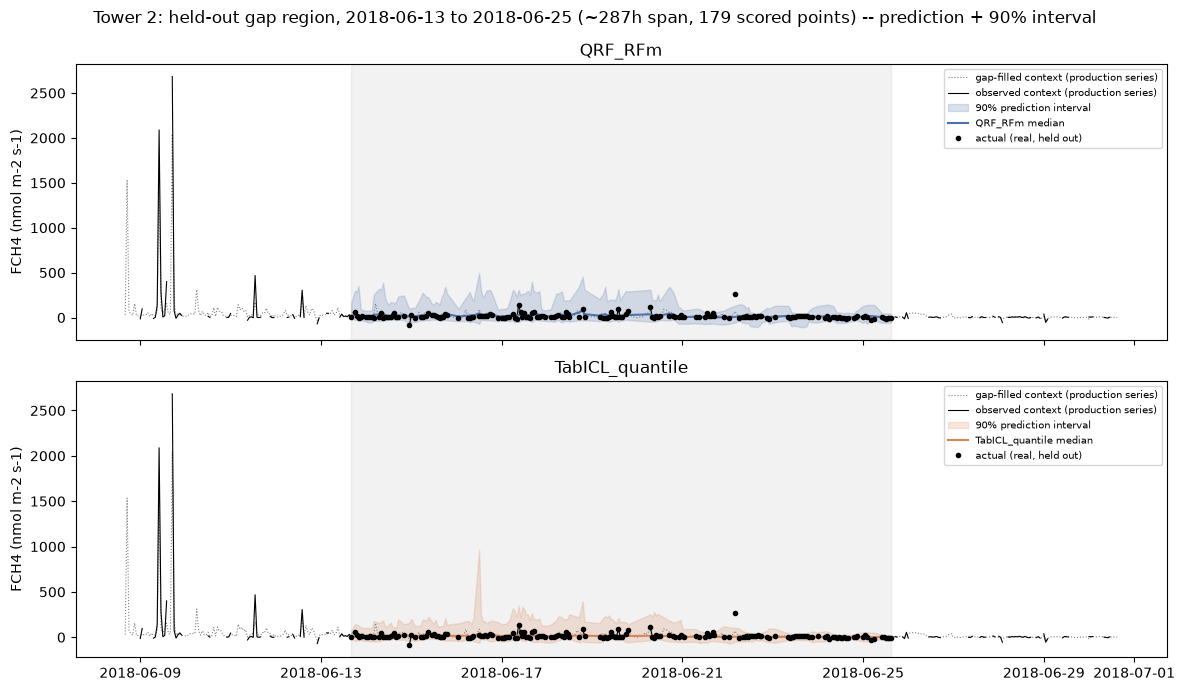

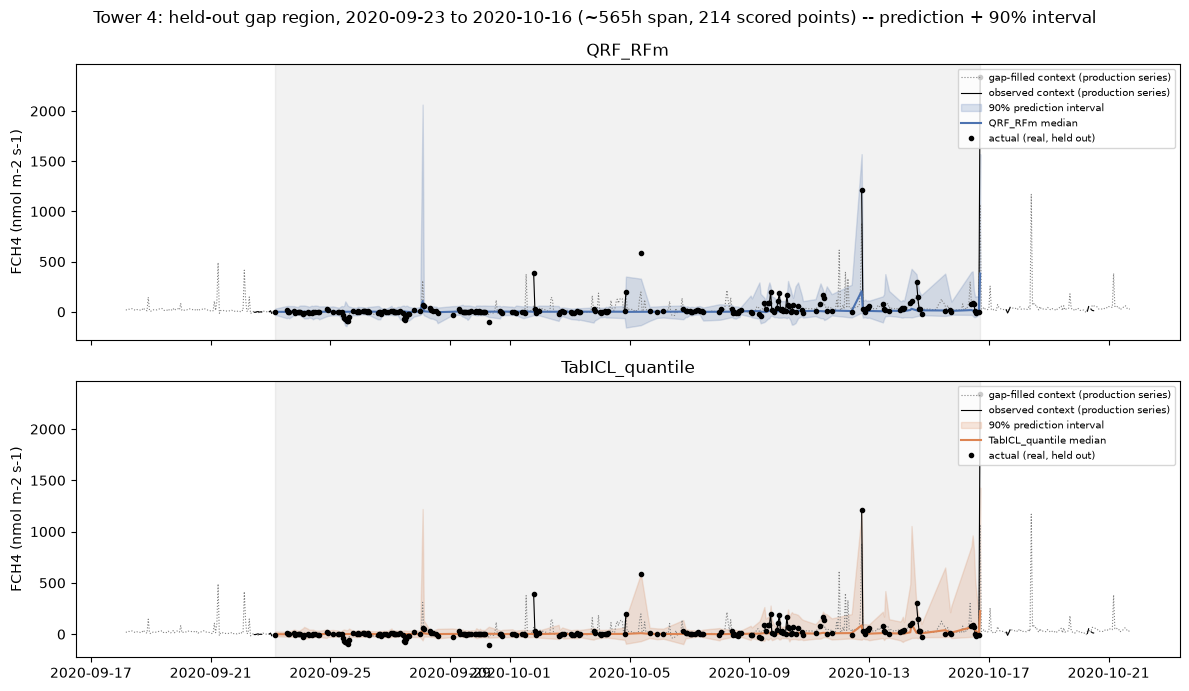

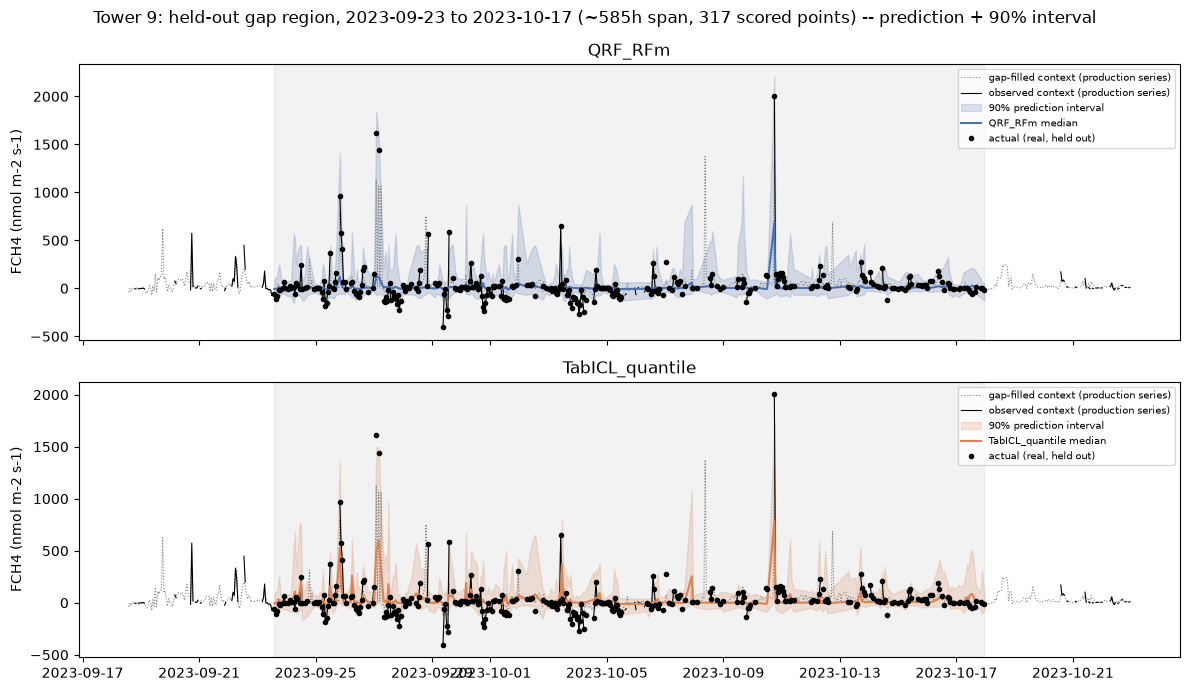

Saved 3 fan charts to C:\Users\Nicholas\Documents\COMP0191 MSc Artificial Intelligence for Sustainable Development Project\notebooks\03c_gap_filling_revisited\_figures


In [64]:
FIG_DIR = Path("_figures")
FIG_DIR.mkdir(exist_ok=True)

MODEL_COLORS_PI = {"QRF_RFm": "#4C72B0", "TabICL_quantile": "#DD8452"}


def largest_contiguous_run(idx, merge_gap_hours=24):
    """insert_calendar_gaps returns the UNION of many non-overlapping gap_hours-length blocks
    scattered across the whole domain (until they cover MASK_FRAC of valid points) -- not one
    single contiguous gap. For a readable demo plot we need just one block. A first version
    required perfect hour-by-hour contiguity, but FCH4's own real sparsity breaks even a single
    288h attempt into many tiny fragments (found spans under 24h) -- fixed to cluster points
    within merge_gap_hours of each other (bridging small real-data gaps inside one synthetic
    attempt) and pick the cluster with the largest total TIME SPAN, not the most hour-complete."""
    idx = pd.DatetimeIndex(idx).sort_values()
    if len(idx) == 0:
        return idx
    gaps = idx.to_series().diff()
    breaks = np.where(gaps > pd.Timedelta(hours=merge_gap_hours))[0]
    starts = np.concatenate([[0], breaks])
    ends = np.concatenate([breaks, [len(idx)]])
    spans = [(idx[e - 1] - idx[s]) for s, e in zip(starts, ends)]
    best = int(np.argmax(spans))
    return idx[starts[best]:ends[best]]


def build_demo_gap(t, gap_hours=288, seed=123):
    """Same construction as run_quantile_model's inner loop, for one specific demo gap --
    mirrors sections 11/16's own worked-example convention (seed=123). Isolates a single
    contiguous block (see largest_contiguous_run) rather than the full scattered held-out set,
    for a readable single-window fan chart."""
    g = frame(t, pooled=True, d=d_all)
    dm = dom_mask(g.index, t)
    gt_scattered = insert_calendar_gaps(g, "target", dm, gap_hours, n_reps=1, seed=seed)[0]
    gt = largest_contiguous_run(gt_scattered)
    base = g[dm & g["target"].notna().values]
    trd = base.drop(index=gt, errors="ignore")
    others = [frame(tt, True, d_all).pipe(lambda gg: gg[dom_mask(gg.index, tt) & gg["target"].notna().values])
              for tt in TOWERS if tt != t]
    trd = pd.concat([trd] + others, ignore_index=True)
    return g, gt, trd


for t in TOWERS:
    g, gt_demo, trd_demo = build_demo_gap(t)
    feat_demo = FEATURES + DUM
    X_query = g.loc[gt_demo, feat_demo].values
    preds_by_model = {
        "QRF_RFm": fit_predict_qrf(feat_demo, trd_demo, X_query),
        "TabICL_quantile": fit_predict_tabicl_q(feat_demo, trd_demo, X_query),
    }

    context_sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].set_index("Datetime")
    window = slice(gt_demo.min() - pd.Timedelta(days=5), gt_demo.max() + pd.Timedelta(days=5))
    context = context_sub.loc[window]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    for ax, model_name in zip(axes, ["QRF_RFm", "TabICL_quantile"]):
        color = MODEL_COLORS_PI[model_name]
        preds = preds_by_model[model_name]
        ax.plot(context.index, context["y_gapfilled"], ":", color="grey", lw=0.8,
                label="gap-filled context (production series)")
        ax.plot(context.index, context["y_observed"], "-", color="black", lw=0.8,
                label="observed context (production series)")
        ax.fill_between(gt_demo, preds[0.05], preds[0.95], color=color, alpha=0.2,
                        label="90% prediction interval")
        ax.plot(gt_demo, preds[0.5], "-", color=color, lw=1.5, label=f"{model_name} median")
        ax.plot(gt_demo, g.loc[gt_demo, "target"].values, "o", color="black", ms=3,
                label="actual (real, held out)")
        ax.axvspan(gt_demo.min(), gt_demo.max(), color="grey", alpha=0.1)
        ax.set_ylabel("FCH4 (nmol m-2 s-1)")
        ax.set_title(model_name)
        ax.legend(fontsize=7, loc="upper right")
    span_hours = int((gt_demo.max() - gt_demo.min()).total_seconds() / 3600)
    fig.suptitle(f"Tower {t}: held-out gap region, {gt_demo.min().date()} to {gt_demo.max().date()} "
                 f"(~{span_hours}h span, {len(gt_demo)} scored points) -- prediction + 90% interval")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"fanchart_T{t}.png", dpi=110)
    plt.show()

print(f"Saved {len(TOWERS)} fan charts to {FIG_DIR.resolve()}")

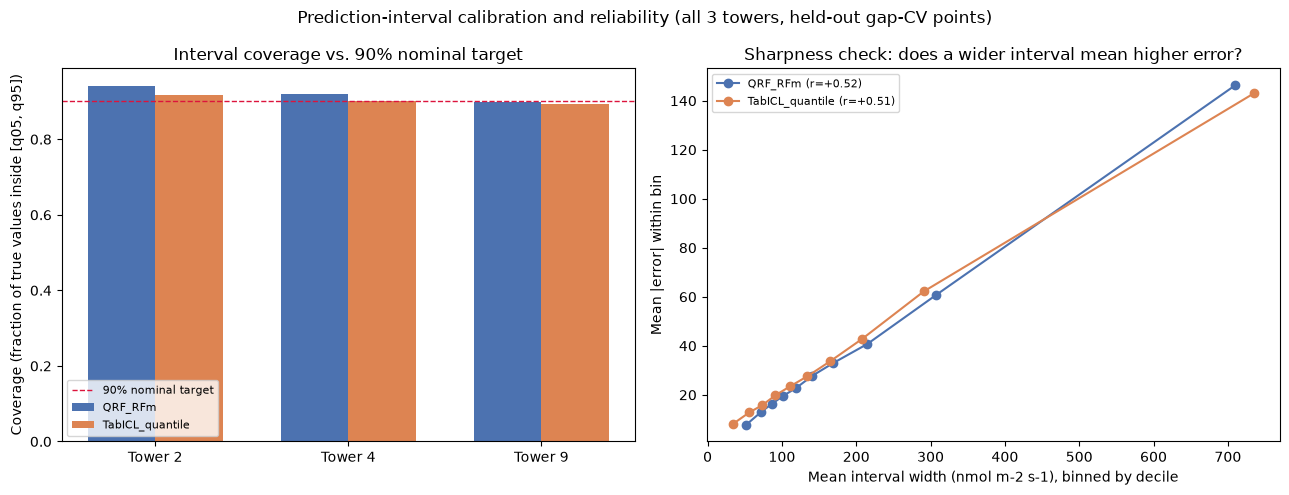

Saved C:\Users\Nicholas\Documents\COMP0191 MSc Artificial Intelligence for Sustainable Development Project\notebooks\03c_gap_filling_revisited\_figures\calibration_reliability.png


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- panel 1: coverage per tower x model vs the 90% nominal target ---
cov = PI_DETAIL.groupby(["tower", "model"])["covered"].mean().unstack("model")
xpos = np.arange(len(TOWERS))
width = 0.35
for i, model_name in enumerate(["QRF_RFm", "TabICL_quantile"]):
    vals = [cov.loc[t, model_name] for t in TOWERS]
    axes[0].bar(xpos + (i - 0.5) * width, vals, width, label=model_name, color=MODEL_COLORS_PI[model_name])
axes[0].axhline(0.90, color="crimson", ls="--", lw=1, label="90% nominal target")
axes[0].set_xticks(xpos); axes[0].set_xticklabels([f"Tower {t}" for t in TOWERS])
axes[0].set_ylabel("Coverage (fraction of true values inside [q05, q95])")
axes[0].set_title("Interval coverage vs. 90% nominal target")
axes[0].legend(fontsize=8)

# --- panel 2: mean abs error by interval-width decile, per model (pooled across towers) ---
for model_name in ["QRF_RFm", "TabICL_quantile"]:
    sub = PI_DETAIL[PI_DETAIL.model == model_name].copy()
    sub["width_decile"] = pd.qcut(sub["width"], 10, duplicates="drop")
    binned = sub.groupby("width_decile", observed=True).agg(mean_width=("width", "mean"), mean_abs_err=("abs_err", "mean"))
    corr = sub["width"].corr(sub["abs_err"])
    axes[1].plot(binned["mean_width"], binned["mean_abs_err"], "o-", color=MODEL_COLORS_PI[model_name],
                 label=f"{model_name} (r={corr:+.2f})")
axes[1].set_xlabel("Mean interval width (nmol m-2 s-1), binned by decile")
axes[1].set_ylabel("Mean |error| within bin")
axes[1].set_title("Sharpness check: does a wider interval mean higher error?")
axes[1].legend(fontsize=8)

fig.suptitle("Prediction-interval calibration and reliability (all 3 towers, held-out gap-CV points)")
fig.tight_layout()
fig.savefig(FIG_DIR / "calibration_reliability.png", dpi=110)
plt.show()

print(f"Saved {FIG_DIR.resolve() / 'calibration_reliability.png'}")

## 22. Production prediction intervals (the real gap-filled series, not synthetic scenarios)

Section 21's intervals were built and scored entirely inside the *validation* mechanism -- 5
scenarios x 2 reps x 3 towers, each a fresh model fit on data with a synthetic gap withheld, used
only to characterize accuracy/calibration. **None of that carries over directly to the real
missing hours in the record** -- those were never assigned a "scenario" at all, that concept only
exists for testing. This section builds the actual thing: **one QRF model and one TabICL model per
tower, each fit once on every real observation (nothing withheld)**, applied to every genuinely
missing hour, exactly mirroring how `FCH4_GAPFILLED` (section 14) and `FCH4_GAPFILLED_WITH_UQ`
(section 17) were built for the point estimate and the DI flag respectively -- this is that same
pattern, extended to a real interval.

- **QRF production**: no new fitting needed -- reuses `rf_prod`/`imp_prod`/`trd_prod` (section 14)
  directly through `fit_predict_qrf`, since `fit()`'s cache key is identical to what section 14
  already computed.
- **TabICL production**: one new fit on `trd_prod` (same `FOUNDATION_MODEL_ROW_CAP=10,000`-row
  subsample convention as every other TabICL use in this notebook).
- **Direct test of the concern raised earlier in conversation**: does a real gap-filled point's
  interval width actually track how long its *surrounding real blackout* is, even though the
  model was never told that length explicitly? Computed via each point's contiguous-missing-run
  length, correlated against interval width.

In [66]:
def gap_run_length_hours(y_observed):
    """For every row where y_observed is NaN, the total length (hours) of its contiguous
    missing run -- e.g. every hour inside a 2-week blackout gets the value 336, not its
    position within it. Real observations get NaN (not applicable)."""
    is_gap = y_observed.isna()
    grp = (is_gap != is_gap.shift()).cumsum()
    run_len = is_gap.groupby(grp).transform("size")
    return run_len.where(is_gap)


t0 = time.time()
PROD_INTERVAL_ROWS = []

# one TabICL fit per tower on ALL real pooled data (no gap withheld) -- genuinely new, unlike QRF
# which reuses section 14's already-cached rf_prod/imp_prod through fit_predict_qrf.
trd_prod_sub = trd_prod.sample(n=min(FOUNDATION_MODEL_ROW_CAP, len(trd_prod)), random_state=42)
imp_tabicl_prod = SimpleImputer(strategy="mean")
tabicl_prod = TabICLRegressor(random_state=42)
tabicl_prod.fit(imp_tabicl_prod.fit_transform(trd_prod_sub[feat_prod].values), trd_prod_sub["target"].values)
print(f"TabICL production model fit on {len(trd_prod_sub):,} rows [{time.time()-t0:.0f}s elapsed]")

for t in TOWERS:
    g = frames_prod[t]; dm = dom_mask(g.index, t)
    X_all_raw = g.loc[dm, feat_prod].values

    qrf_preds = fit_predict_qrf(feat_prod, trd_prod, X_all_raw)
    tabicl_preds_arr = tabicl_prod.predict(imp_tabicl_prod.transform(X_all_raw), output_type="quantiles", alphas=QUANTILES)

    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].reset_index(drop=True).copy()
    sub["qrf_q05"] = qrf_preds[0.05]; sub["qrf_q50"] = qrf_preds[0.5]; sub["qrf_q95"] = qrf_preds[0.95]
    sub["tabicl_q05"] = tabicl_preds_arr[:, 0]; sub["tabicl_q50"] = tabicl_preds_arr[:, 1]; sub["tabicl_q95"] = tabicl_preds_arr[:, 2]
    sub["gap_run_length_h"] = gap_run_length_hours(sub["y_observed"])
    PROD_INTERVAL_ROWS.append(sub)
    print(f"Tower {t}: production intervals for {len(sub):,} hours [{time.time()-t0:.0f}s elapsed]", flush=True)

FCH4_GAPFILLED_WITH_INTERVALS = pd.concat(PROD_INTERVAL_ROWS, ignore_index=True)
FCH4_GAPFILLED_WITH_INTERVALS.to_csv(DATA_DIR / "fch4_gapfilled_with_intervals.csv", index=False)
print(f"\nSaved {DATA_DIR/'fch4_gapfilled_with_intervals.csv'}  ({len(FCH4_GAPFILLED_WITH_INTERVALS):,} rows)  "
      f"[{time.time()-t0:.0f}s elapsed]")

# does interval width track how long the real surrounding blackout is?
gf_only = FCH4_GAPFILLED_WITH_INTERVALS[FCH4_GAPFILLED_WITH_INTERVALS["y_observed"].isna()].copy()
gf_only["qrf_width"] = gf_only["qrf_q95"] - gf_only["qrf_q05"]
gf_only["tabicl_width"] = gf_only["tabicl_q95"] - gf_only["tabicl_q05"]
print("\nDoes interval width scale with the real gap's own length? (corr with gap_run_length_h)")
for t in TOWERS:
    s = gf_only[gf_only.tower == t]
    print(f"  Tower {t}: QRF r={s['gap_run_length_h'].corr(s['qrf_width']):+.3f}   "
          f"TabICL r={s['gap_run_length_h'].corr(s['tabicl_width']):+.3f}   (n={len(s):,})")
overall_qrf = gf_only["gap_run_length_h"].corr(gf_only["qrf_width"])
overall_tabicl = gf_only["gap_run_length_h"].corr(gf_only["tabicl_width"])
print(f"  Pooled all towers: QRF r={overall_qrf:+.3f}   TabICL r={overall_tabicl:+.3f}")

TabICL production model fit on 10,000 rows [0s elapsed]


Tower 2: production intervals for 15,289 hours [13s elapsed]


Tower 4: production intervals for 54,769 hours [43s elapsed]


Tower 9: production intervals for 34,297 hours [65s elapsed]



Saved _data\fch4_gapfilled_with_intervals.csv  (104,355 rows)  [65s elapsed]

Does interval width scale with the real gap's own length? (corr with gap_run_length_h)
  Tower 2: QRF r=-0.060   TabICL r=+0.029   (n=10,399)
  Tower 4: QRF r=-0.135   TabICL r=-0.072   (n=35,304)
  Tower 9: QRF r=-0.136   TabICL r=+0.100   (n=23,066)
  Pooled all towers: QRF r=-0.093   TabICL r=+0.077


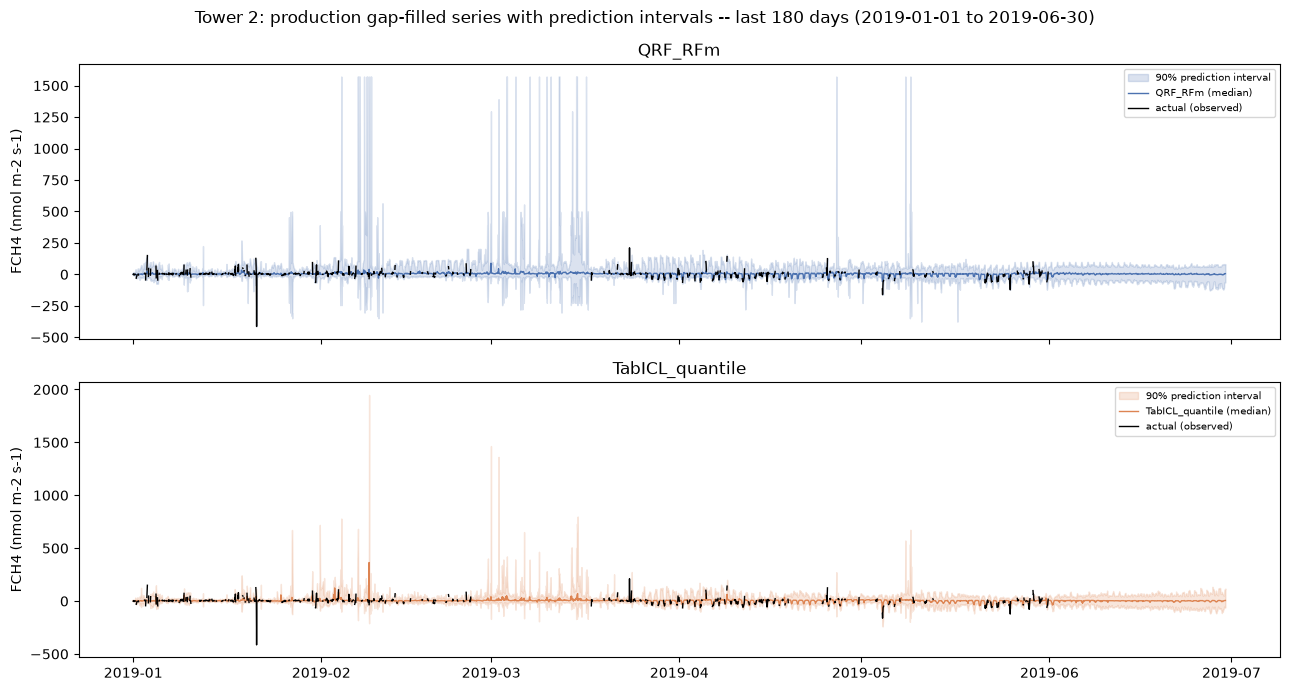

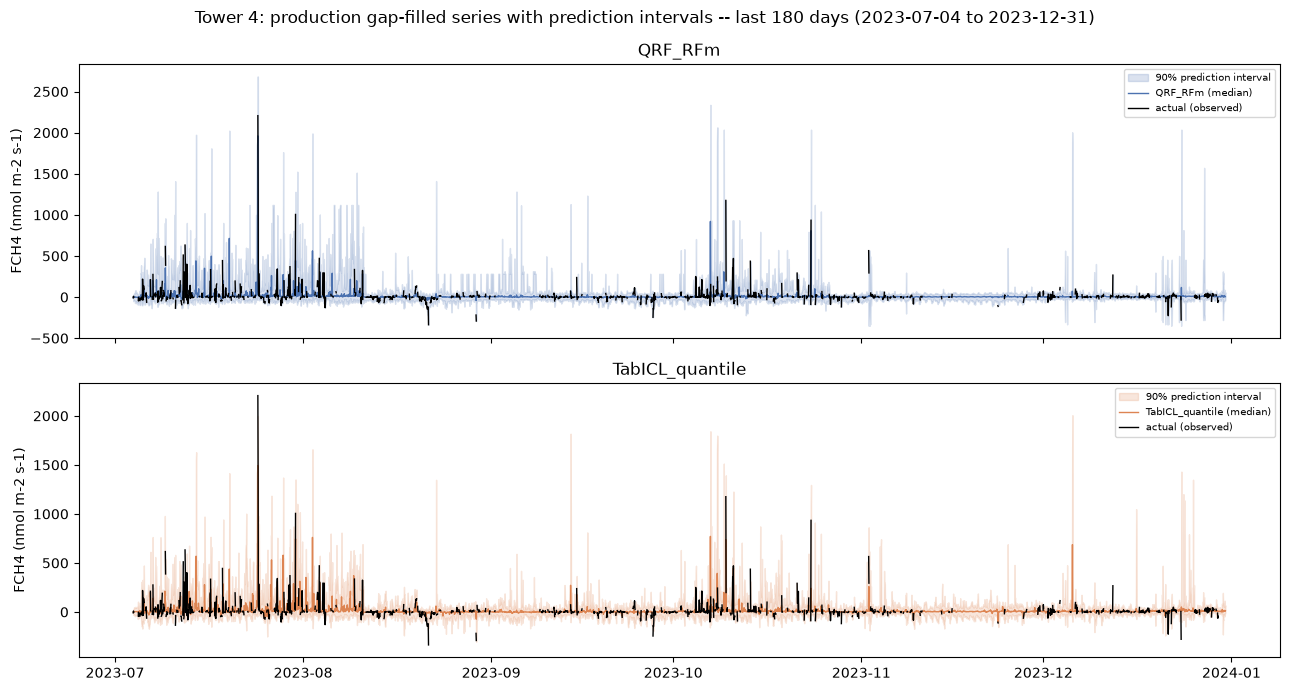

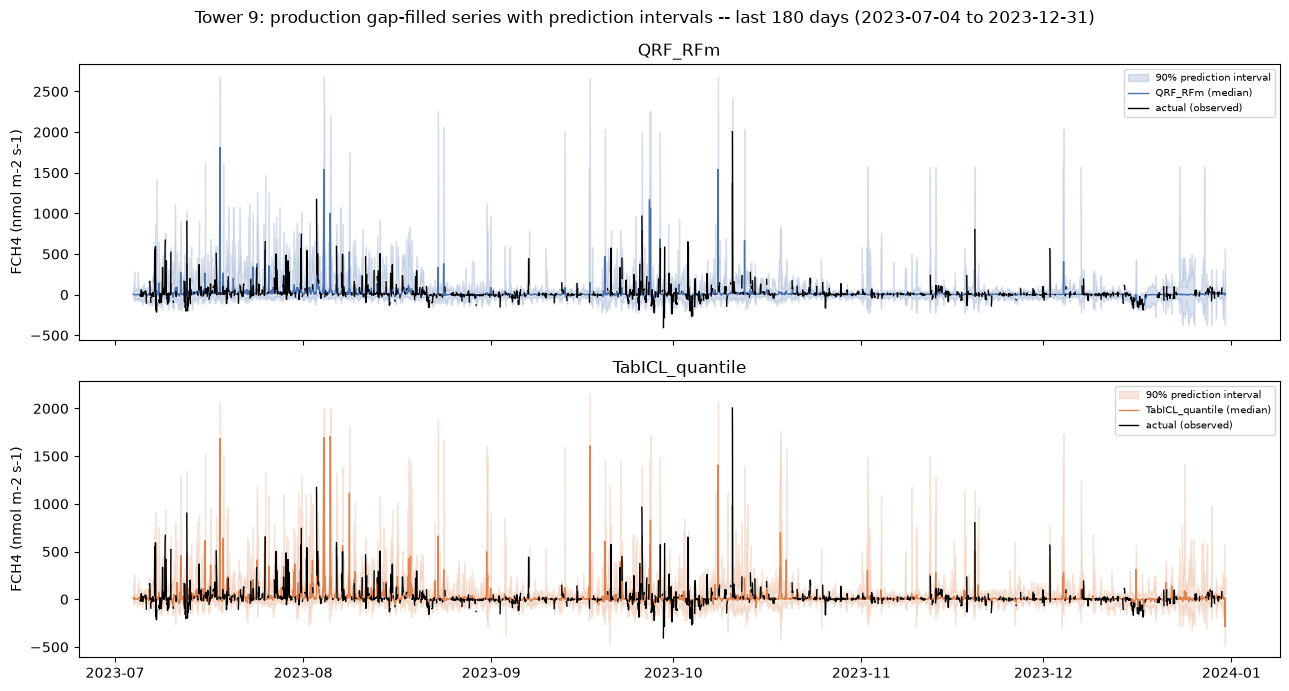

Saved 3 production-interval charts to C:\Users\Nicholas\Documents\COMP0191 MSc Artificial Intelligence for Sustainable Development Project\notebooks\03c_gap_filling_revisited\_figures


In [67]:
for t in TOWERS:
    sub = FCH4_GAPFILLED_WITH_INTERVALS[FCH4_GAPFILLED_WITH_INTERVALS.tower == t].set_index("Datetime")
    window = sub.loc[sub.index.max() - pd.Timedelta(days=180):]

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    for ax, model_name, qcol_lo, qcol_hi, qcol_med, color in [
        (axes[0], "QRF_RFm", "qrf_q05", "qrf_q95", "qrf_q50", MODEL_COLORS_PI["QRF_RFm"]),
        (axes[1], "TabICL_quantile", "tabicl_q05", "tabicl_q95", "tabicl_q50", MODEL_COLORS_PI["TabICL_quantile"]),
    ]:
        ax.fill_between(window.index, window[qcol_lo], window[qcol_hi], color=color, alpha=0.2,
                        label="90% prediction interval")
        ax.plot(window.index, window[qcol_med], "-", color=color, lw=1, label=f"{model_name} (median)")
        ax.plot(window.index, window["y_observed"], "-", color="black", lw=1, label="actual (observed)")
        ax.set_ylabel("FCH4 (nmol m-2 s-1)")
        ax.set_title(model_name)
        ax.legend(fontsize=7, loc="upper right")
    fig.suptitle(f"Tower {t}: production gap-filled series with prediction intervals -- "
                 f"last 180 days ({window.index.min().date()} to {window.index.max().date()})")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"production_interval_T{t}.png", dpi=110)
    plt.show()

print(f"Saved {len(TOWERS)} production-interval charts to {FIG_DIR.resolve()}")

## 23. Gap-length-stratified conformal calibration (fixing section 22's finding)

Section 22 found that raw interval width does **not** reliably widen for longer real gaps (QRF:
consistently negative correlation at every tower; TabICL: inconsistent, near-zero) -- the model
sees smoothed, unremarkable-looking covariates during long blackouts and stays falsely confident.
This section fixes the *symptom* (interval sharpness/calibration), not the root cause (still
worth stating plainly): **Conformalized Quantile Regression (CQR, Romano et al. 2019), stratified
by gap-length bucket**, mirroring this project's own established convention (U-02's per-lead-time-
bin conformal margins, `notebooks/06_interpretability_uq/U02_uncertainty_rollout.ipynb`) applied
here per gap-length bucket instead of per lead-time bin.

- **Calibration source**: section 21's validation set (`PI_DETAIL`) -- real ground truth at each of
  the 4 discrete scenario gap-lengths (`vs`=1h, `s`=4h, `m`=32h, `l`=288h; `m1`/mixed excluded from
  calibration since it conflates lengths and has no single characteristic value).
- **Split-conformal, not the same data twice**: each `(model, tower, scenario)` group is randomly
  split 50/50 into a calibration half (computes the margin) and a genuinely held-out test half
  (verifies the resulting coverage) -- avoids the circularity of calibrating and evaluating on the
  identical points, which would trivially show ~90% coverage by construction.
- **Margin**: `max(q05 - y_true, y_true - q95)` (the CQR conformity score) across the calibration
  half, its 90th percentile becomes the margin; calibrated interval = `[q05 - margin, q95 + margin]`
  -- can *shrink* the raw interval too, wherever the raw interval was already wide enough (not a
  one-directional "always widen" rule).
- **Production application**: every gap-filled hour's real `gap_run_length_h` (section 22) is
  mapped to the nearest of the 4 scenario buckets (geometric-midpoint thresholds: 2h/11.3h/96h),
  and that `(model, tower, bucket)`'s margin is applied.

In [68]:
GAP_BUCKETS = ["vs", "s", "m", "l"]
GAP_BUCKET_EDGES = [2.0, 11.3, 96.0]  # geometric midpoints between the 1/4/32/288h scenario lengths


def assign_gap_bucket(hours):
    edges = GAP_BUCKET_EDGES
    return np.select([hours <= edges[0], hours <= edges[1], hours <= edges[2]], ["vs", "s", "m"], default="l")


rng_cal = np.random.default_rng(42)
CONFORMAL_MARGINS = {}
CONFORMAL_TEST_ROWS = []

for model_name in ["QRF_RFm", "TabICL_quantile"]:
    for t in TOWERS:
        for sc in GAP_BUCKETS:
            sub = PI_DETAIL[(PI_DETAIL.model == model_name) & (PI_DETAIL.tower == t) & (PI_DETAIL.scenario == sc)]
            if len(sub) < 20:
                continue
            idx = rng_cal.permutation(len(sub))
            half = len(idx) // 2
            cal, test = sub.iloc[idx[:half]], sub.iloc[idx[half:]]

            conformity = np.maximum(cal["q05"] - cal["y_true"], cal["y_true"] - cal["q95"])
            margin = float(np.quantile(conformity, 0.90))
            CONFORMAL_MARGINS[(model_name, t, sc)] = margin

            cal_lo_test = test["q05"] - margin
            cal_hi_test = test["q95"] + margin
            covered_cal = (test["y_true"] >= cal_lo_test) & (test["y_true"] <= cal_hi_test)
            CONFORMAL_TEST_ROWS.append({
                "model": model_name, "tower": t, "scenario": sc, "n_cal": len(cal), "n_test": len(test),
                "margin": round(margin, 2),
                "raw_coverage_test": round(test["covered"].mean(), 3),
                "calibrated_coverage_test": round(covered_cal.mean(), 3),
                "raw_width_test": round(test["width"].mean(), 1),
                "calibrated_width_test": round((cal_hi_test - cal_lo_test).mean(), 1),
            })

CONFORMAL_SUMMARY = pd.DataFrame(CONFORMAL_TEST_ROWS)
CONFORMAL_SUMMARY.to_csv(DATA_DIR / "conformal_calibration_summary.csv", index=False)
print(f"Saved {DATA_DIR/'conformal_calibration_summary.csv'} ({len(CONFORMAL_SUMMARY)} rows)\n")
print("Held-out test-half coverage, raw vs. calibrated (target 0.90):")
print(CONFORMAL_SUMMARY.groupby("model")[["raw_coverage_test", "calibrated_coverage_test"]].mean().round(3).to_string())
CONFORMAL_SUMMARY

Saved _data\conformal_calibration_summary.csv (24 rows)

Held-out test-half coverage, raw vs. calibrated (target 0.90):
                 raw_coverage_test  calibrated_coverage_test
model                                                       
QRF_RFm                      0.919                     0.899
TabICL_quantile              0.902                     0.898


,model,tower,scenario,n_cal,n_test,margin,raw_coverage_test,calibrated_coverage_test,raw_width_test,calibrated_width_test
0,QRF_RFm,2,vs,1222,1222,-7.18,0.932,0.886,152.0,137.7
1,QRF_RFm,2,s,1223,1224,-6.70,0.929,0.876,167.1,153.7
2,QRF_RFm,2,m,1231,1232,-8.63,0.936,0.899,158.9,141.7
3,QRF_RFm,2,l,1282,1283,-9.97,0.956,0.911,177.3,157.4
4,QRF_RFm,4,vs,4866,4866,-6.70,0.925,0.898,185.4,172.0
5,QRF_RFm,4,s,4867,4868,-6.69,0.920,0.895,194.2,180.9
6,QRF_RFm,4,m,4873,4874,-2.18,0.911,0.906,198.4,194.0
7,QRF_RFm,4,l,4877,4877,-3.06,0.910,0.903,206.4,200.3
8,QRF_RFm,9,vs,2807,2807,-4.69,0.916,0.901,213.7,204.3
9,QRF_RFm,9,s,2807,2808,-1.71,0.905,0.898,223.0,219.6


In [69]:
gf = FCH4_GAPFILLED_WITH_INTERVALS.copy()
is_gf = gf["y_observed"].isna()
gf["gap_bucket"] = pd.Series(assign_gap_bucket(gf["gap_run_length_h"].fillna(0).values), index=gf.index).where(is_gf)

margin_df = pd.DataFrame([{"model": k[0], "tower": k[1], "gap_bucket": k[2], "margin": v} for k, v in CONFORMAL_MARGINS.items()])
qrf_m = margin_df[margin_df.model == "QRF_RFm"].rename(columns={"margin": "qrf_margin"})[["tower", "gap_bucket", "qrf_margin"]]
tabicl_m = margin_df[margin_df.model == "TabICL_quantile"].rename(columns={"margin": "tabicl_margin"})[["tower", "gap_bucket", "tabicl_margin"]]
gf = gf.merge(qrf_m, on=["tower", "gap_bucket"], how="left").merge(tabicl_m, on=["tower", "gap_bucket"], how="left")

gf["qrf_q05_cal"] = gf["qrf_q05"] - gf["qrf_margin"]
gf["qrf_q95_cal"] = gf["qrf_q95"] + gf["qrf_margin"]
gf["tabicl_q05_cal"] = gf["tabicl_q05"] - gf["tabicl_margin"]
gf["tabicl_q95_cal"] = gf["tabicl_q95"] + gf["tabicl_margin"]

FCH4_GAPFILLED_WITH_INTERVALS_CAL = gf
FCH4_GAPFILLED_WITH_INTERVALS_CAL.to_csv(DATA_DIR / "fch4_gapfilled_with_intervals_calibrated.csv", index=False)
print(f"Saved {DATA_DIR/'fch4_gapfilled_with_intervals_calibrated.csv'} ({len(gf):,} rows)")

gf_only = gf[is_gf].copy()
gf_only["qrf_width_cal"] = gf_only["qrf_q95_cal"] - gf_only["qrf_q05_cal"]
gf_only["tabicl_width_cal"] = gf_only["tabicl_q95_cal"] - gf_only["tabicl_q05_cal"]
print("\nAfter calibration -- does interval width now scale with the real gap's own length?")
for t in TOWERS:
    s = gf_only[gf_only.tower == t]
    print(f"  Tower {t}: QRF r={s['gap_run_length_h'].corr(s['qrf_width_cal']):+.3f}  "
          f"(was {s['gap_run_length_h'].corr(s['qrf_q95'] - s['qrf_q05']):+.3f})   "
          f"TabICL r={s['gap_run_length_h'].corr(s['tabicl_width_cal']):+.3f}  "
          f"(was {s['gap_run_length_h'].corr(s['tabicl_q95'] - s['tabicl_q05']):+.3f})")

Saved _data\fch4_gapfilled_with_intervals_calibrated.csv (104,355 rows)

After calibration -- does interval width now scale with the real gap's own length?
  Tower 2: QRF r=-0.068  (was -0.060)   TabICL r=+0.014  (was +0.029)
  Tower 4: QRF r=-0.129  (was -0.135)   TabICL r=-0.088  (was -0.072)
  Tower 9: QRF r=-0.120  (was -0.136)   TabICL r=+0.081  (was +0.100)


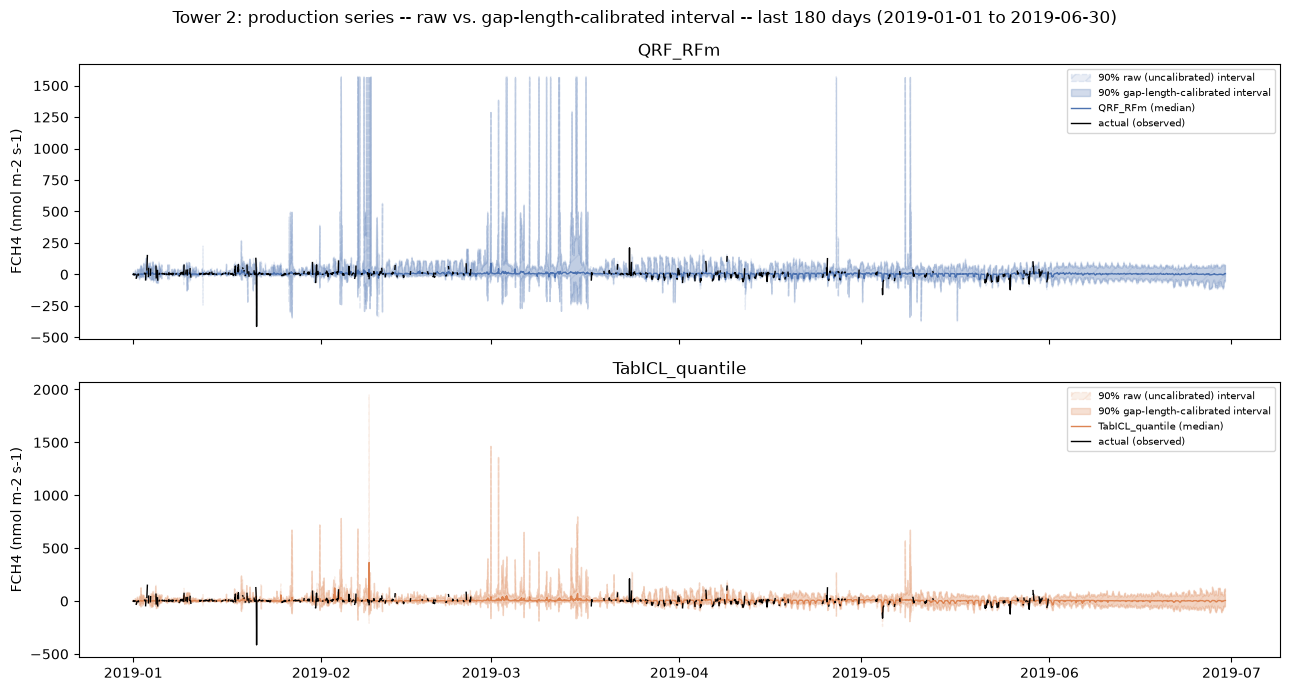

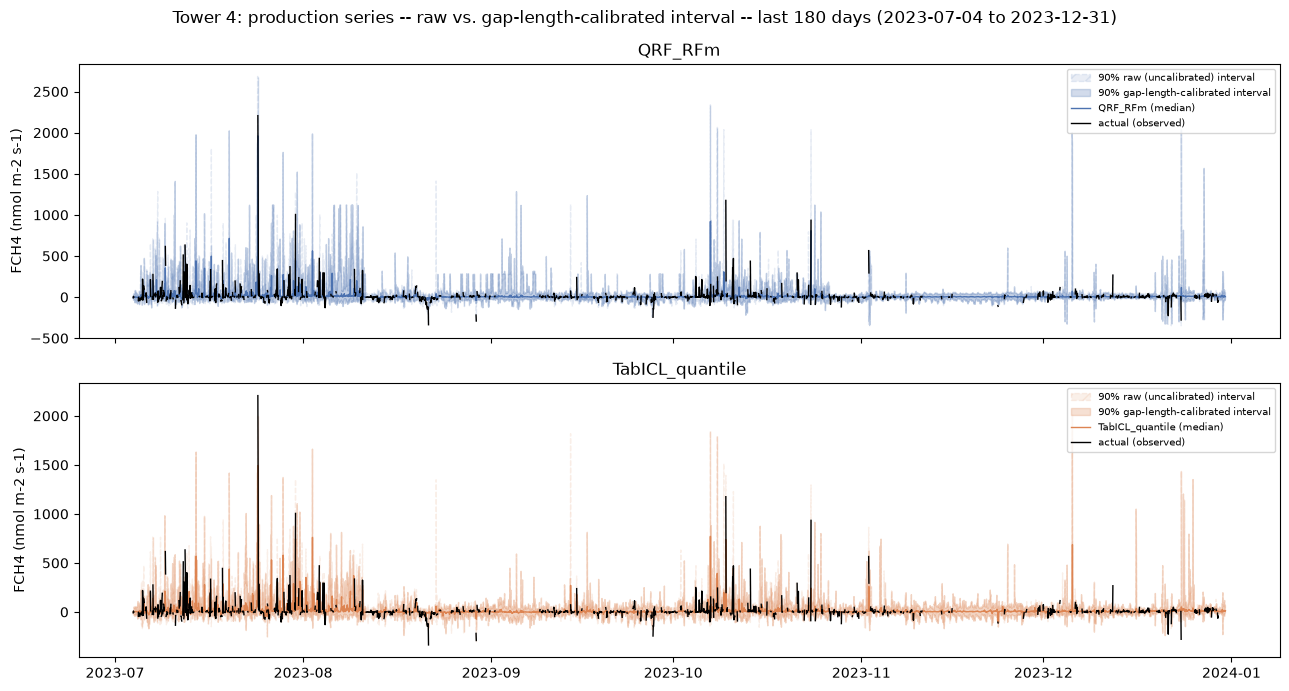

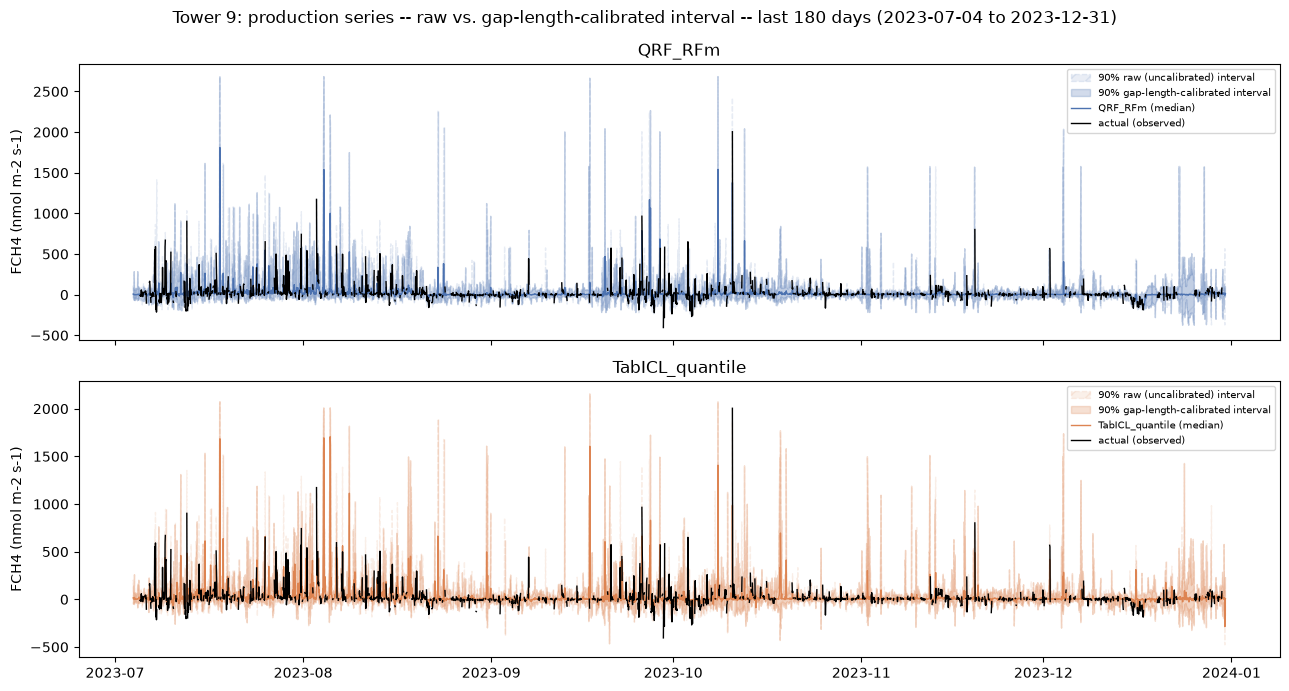

Updated 3 production-interval charts (raw + calibrated bands) in C:\Users\Nicholas\Documents\COMP0191 MSc Artificial Intelligence for Sustainable Development Project\notebooks\03c_gap_filling_revisited\_figures


In [70]:
for t in TOWERS:
    sub = FCH4_GAPFILLED_WITH_INTERVALS_CAL[FCH4_GAPFILLED_WITH_INTERVALS_CAL.tower == t].set_index("Datetime")
    window = sub.loc[sub.index.max() - pd.Timedelta(days=180):]

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    panels = [
        (axes[0], "QRF_RFm", "qrf_q05", "qrf_q95", "qrf_q05_cal", "qrf_q95_cal", "qrf_q50", MODEL_COLORS_PI["QRF_RFm"]),
        (axes[1], "TabICL_quantile", "tabicl_q05", "tabicl_q95", "tabicl_q05_cal", "tabicl_q95_cal", "tabicl_q50", MODEL_COLORS_PI["TabICL_quantile"]),
    ]
    for ax, model_name, raw_lo, raw_hi, cal_lo, cal_hi, med_col, color in panels:
        ax.fill_between(window.index, window[raw_lo], window[raw_hi], color=color, alpha=0.12,
                        hatch="//", linestyle="--", edgecolor=color, label="90% raw (uncalibrated) interval")
        ax.fill_between(window.index, window[cal_lo], window[cal_hi], color=color, alpha=0.25,
                        label="90% gap-length-calibrated interval")
        ax.plot(window.index, window[med_col], "-", color=color, lw=1, label=f"{model_name} (median)")
        ax.plot(window.index, window["y_observed"], "-", color="black", lw=1, label="actual (observed)")
        ax.set_ylabel("FCH4 (nmol m-2 s-1)")
        ax.set_title(model_name)
        ax.legend(fontsize=7, loc="upper right")
    fig.suptitle(f"Tower {t}: production series -- raw vs. gap-length-calibrated interval -- "
                 f"last 180 days ({window.index.min().date()} to {window.index.max().date()})")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"production_interval_T{t}.png", dpi=110)
    plt.show()

print(f"Updated {len(TOWERS)} production-interval charts (raw + calibrated bands) in {FIG_DIR.resolve()}")

## 24. Structural fix: distance-to-real-observation as an actual model feature

Section 23's conformal calibration fixed aggregate coverage but left per-point sharpness
unchanged -- a coarse 4-bucket step correction can't reshape a continuous relationship. This
section attacks the root cause instead: **give the model the "how far is this point from real
data" signal directly**, as a genuine input feature, rather than patching the interval after the
fact.

- **`dist_to_real_obs`**: for every timestamp, the number of hours to the *nearest* real (currently
  unmasked) target observation, in either direction -- computed via `ffill`/`bfill` on a
  NaT-riddled timestamp index, so it's O(n) and fully vectorized. Symmetric by design (gap-filling
  can look both ways, unlike forecasting), unlike section 22's `gap_run_length_h` which only
  captured the *total* length of a point's surrounding blackout uniformly for every point inside
  it -- this captures *position within* the gap too (edge of a long gap = small distance = should
  be more confident; middle of it = large distance = should be less).
- **Leakage-safe by the same pattern as section 20's target lag/lead**: mask the target at the
  current fold's held-out timestamps *first*, then compute `dist_to_real_obs` from that masked
  series -- a held-out point's distance correctly skips past any *neighbouring* held-out point to
  the next genuinely-real observation, so it reveals only structural distance, never a masked
  neighbour's true value.
- **Two-stage validation, cheapest/most-diagnostic first** (same staging convention as every other
  new lever this session): (1) does adding this feature to the champion's own architecture hurt
  point-estimate R²? (2) if not, does QRF's interval width now actually correlate with this
  distance, checked directly and continuously in the controlled gap-CV harness (not just the
  coarser production proxy)? Full 3-tower throughout. Production application is a deliberate
  follow-up, gated on these results rather than built blind.

In [71]:
def dist_to_real_obs(target_masked):
    """Hours to the nearest real (non-NaN) observation in target_masked, in either direction.
    Vectorized via forward/backward-filling the timestamp itself through a NaT-masked index --
    correctly skips past any masked (held-out or naturally missing) neighbours to the next
    genuinely-real point, so it can never leak a neighbour's true value, only structural distance."""
    idx = target_masked.index
    valid_ts = pd.Series(idx.where(target_masked.notna()), index=idx)
    fwd = valid_ts.ffill()
    bwd = valid_ts.bfill()
    dist_fwd = (idx - fwd).dt.total_seconds() / 3600
    dist_bwd = (bwd - idx).dt.total_seconds() / 3600
    dist = np.fmin(dist_fwd.fillna(np.inf), dist_bwd.fillna(np.inf))
    return pd.Series(np.where(np.isinf(dist), np.nan, dist), index=idx)


def run_rf_gapdist(t, pooled):
    """Point-estimate R2 check: champion architecture + one new feature. Mirrors
    run_rf_target_laglead's per-fold masking structure exactly."""
    feat = FEATURES + ["dist_to_real_obs"] + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame(tt, pooled, d_all) for tt in towers}

    others_list = []
    if pooled:
        for tt in towers:
            if tt == t:
                continue
            gg = base_frames[tt]; dmt = dom_mask(gg.index, tt)
            gg_valid = gg[dmt & gg["target"].notna().values].copy()
            gg_valid["dist_to_real_obs"] = dist_to_real_obs(gg["target"]).reindex(gg_valid.index)
            others_list.append(gg_valid)

    g_base = base_frames[t]; idx = g_base.index; out = {}; dm = dom_mask(idx, t)
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(g_base, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)
            g = g_base.copy()
            target_masked = g["target"].copy(); target_masked.loc[target_masked.index.isin(gt_ts)] = np.nan
            g["dist_to_real_obs"] = dist_to_real_obs(target_masked)

            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            assert not gt_ts.isin(trd.index).any(), f"leakage: held-out timestamps present in training index (tower={t}, scenario={sc})"
            if pooled:
                trd = pd.concat([trd] + others_list, ignore_index=True)
            rf, imp = fit(feat, trd)
            yp = rf.predict(imp.transform(g.loc[gt, feat].values))
            rr.append(mets(g.loc[gt, "target"].values, yp))
        out[sc] = med_metrics(rr)
    return out


t0 = time.time()
GAPDIST_R2_ROWS = []
for t in TOWERS:
    champion_r2 = R.loc[(R.tower == t) & (R.model == "RFm_pool"), "R2_overall"].iloc[0]
    scn = run_rf_gapdist(t, pooled=True)
    ov = {k: np.nanmedian([scn[s][k] for s in SCENARIOS]) for k in ["R2", "RMSE", "MAE", "MBE"]}
    delta = ov["R2"] - champion_r2
    GAPDIST_R2_ROWS.append({"tower": t, "R2_overall": round(ov["R2"], 3), "champion_R2": champion_r2, "delta": round(delta, 3)})
    print(f"RFm+dist_to_real_obs  Tower {t}: R2={ov['R2']:+.3f}  (champion={champion_r2:+.3f}, delta={delta:+.3f})  "
          f"[{time.time()-t0:.0f}s elapsed]", flush=True)

GAPDIST_R2_SUMMARY = pd.DataFrame(GAPDIST_R2_ROWS)
GAPDIST_R2_SUMMARY.to_csv(DATA_DIR / "gapdist_feature_r2_check.csv", index=False)
print(f"\nSaved {DATA_DIR/'gapdist_feature_r2_check.csv'}")
GAPDIST_R2_SUMMARY

RFm+dist_to_real_obs  Tower 2: R2=+0.576  (champion=+0.576, delta=+0.000)  [5s elapsed]


RFm+dist_to_real_obs  Tower 4: R2=+0.404  (champion=+0.404, delta=-0.000)  [9s elapsed]


RFm+dist_to_real_obs  Tower 9: R2=+0.426  (champion=+0.426, delta=-0.000)  [14s elapsed]



Saved _data\gapdist_feature_r2_check.csv


,tower,R2_overall,champion_R2,delta
0,2,0.576,0.576,0.0
1,4,0.404,0.404,-0.0
2,9,0.426,0.426,-0.0


In [72]:
def run_quantile_model_gapdist(t, pooled):
    """Same fold structure as run_rf_gapdist, but scored for interval width vs. dist_to_real_obs
    directly and continuously -- the actual test of whether the structural fix works."""
    feat = FEATURES + ["dist_to_real_obs"] + (DUM if pooled else [])
    towers = TOWERS if pooled else [t]
    base_frames = {tt: frame(tt, pooled, d_all) for tt in towers}

    others_list = []
    if pooled:
        for tt in towers:
            if tt == t:
                continue
            gg = base_frames[tt]; dmt = dom_mask(gg.index, tt)
            gg_valid = gg[dmt & gg["target"].notna().values].copy()
            gg_valid["dist_to_real_obs"] = dist_to_real_obs(gg["target"]).reindex(gg_valid.index)
            others_list.append(gg_valid)

    g_base = base_frames[t]; dm = dom_mask(g_base.index, t)
    rows = []
    for sc, gh in SCENARIOS.items():
        for gt in insert_calendar_gaps(g_base, "target", dm, gh):
            if len(gt) < 5:
                continue
            gt_ts = pd.DatetimeIndex(gt)
            g = g_base.copy()
            target_masked = g["target"].copy(); target_masked.loc[target_masked.index.isin(gt_ts)] = np.nan
            g["dist_to_real_obs"] = dist_to_real_obs(target_masked)

            base = g[dm & g["target"].notna().values]; trd = base.drop(index=gt, errors="ignore")
            if pooled:
                trd = pd.concat([trd] + others_list, ignore_index=True)
            preds = fit_predict_qrf(feat, trd, g.loc[gt, feat].values)
            y_true = g.loc[gt, "target"].values
            lo, med, hi = preds[0.05], preds[0.5], preds[0.95]
            covered = (y_true >= lo) & (y_true <= hi); width = hi - lo; abs_err = np.abs(med - y_true)
            dist_vals = g.loc[gt, "dist_to_real_obs"].values
            for j in range(len(y_true)):
                rows.append({"scenario": sc, "y_true": float(y_true[j]), "width": float(width[j]),
                             "abs_err": float(abs_err[j]), "covered": bool(covered[j]),
                             "dist_to_real_obs": float(dist_vals[j])})
    return pd.DataFrame(rows)


t0 = time.time()
GAPDIST_QRF_PARTS = []
for t in TOWERS:
    df_t = run_quantile_model_gapdist(t, pooled=True)
    df_t.insert(0, "tower", t)
    GAPDIST_QRF_PARTS.append(df_t)
    coverage = df_t["covered"].mean()
    corr = df_t["dist_to_real_obs"].corr(df_t["width"])
    print(f"Tower {t}: coverage={coverage:.3f}  corr(dist_to_real_obs, width)={corr:+.3f}  "
          f"[{time.time()-t0:.0f}s elapsed]", flush=True)

GAPDIST_QRF_DETAIL = pd.concat(GAPDIST_QRF_PARTS, ignore_index=True)
GAPDIST_QRF_DETAIL.to_csv(DATA_DIR / "gapdist_feature_interval_check.csv", index=False)
overall_corr = GAPDIST_QRF_DETAIL["dist_to_real_obs"].corr(GAPDIST_QRF_DETAIL["width"])
print(f"\nPooled all towers: coverage={GAPDIST_QRF_DETAIL['covered'].mean():.3f}  "
      f"corr(dist_to_real_obs, width)={overall_corr:+.3f}  (section 22's production proxy was -0.093 pooled QRF)")
print(f"Saved {DATA_DIR/'gapdist_feature_interval_check.csv'}")

Tower 2: coverage=0.941  corr(dist_to_real_obs, width)=+0.025  [18s elapsed]


Tower 4: coverage=0.919  corr(dist_to_real_obs, width)=+0.003  [48s elapsed]


Tower 9: coverage=0.898  corr(dist_to_real_obs, width)=-0.018  [72s elapsed]



Pooled all towers: coverage=0.915  corr(dist_to_real_obs, width)=-0.000  (section 22's production proxy was -0.093 pooled QRF)
Saved _data\gapdist_feature_interval_check.csv


## 25. Consolidated UQ export (one row per hour, scenario assigned by real gap length)

Every UQ artifact so far lives in a separate file (DI/AoA in section 17, raw intervals in section
22, calibrated intervals in section 23). This section merges them into **one tidy CSV**, and adds
the piece that was implicit before but never an explicit column: each gap-filled hour's
`gap_run_length_h` (section 22) mapped to the nearest tested scenario (`vs`/`s`/`m`/`l`, section
23's `assign_gap_bucket` thresholds) -- i.e. "which of the 4 gap-length regimes this real point's
own blackout most resembles," made explicit rather than left implicit in a bucket-keyed margin
lookup. Real observations get no scenario (the concept only applies to gap-filled hours).

In [73]:
uq_base = FCH4_GAPFILLED_WITH_UQ[["Datetime", "tower", "y_observed", "y_gapfilled", "dissimilarity_index", "outside_aoa"]].copy()
intervals_cal = FCH4_GAPFILLED_WITH_INTERVALS_CAL[["Datetime", "tower", "gap_run_length_h", "gap_bucket",
    "qrf_q05", "qrf_q50", "qrf_q95", "qrf_q05_cal", "qrf_q95_cal",
    "tabicl_q05", "tabicl_q50", "tabicl_q95", "tabicl_q05_cal", "tabicl_q95_cal"]].copy()

UQ_CONSOLIDATED = uq_base.merge(intervals_cal, on=["Datetime", "tower"], how="left")
assert len(UQ_CONSOLIDATED) == len(uq_base), "merge changed row count -- (Datetime, tower) key mismatch between UQ sources"

SCENARIO_LABELS = {"vs": "vs (~1h)", "s": "s (~4h)", "m": "m (~32h)", "l": "l (~288h)"}
UQ_CONSOLIDATED["scenario_assigned"] = UQ_CONSOLIDATED["gap_bucket"].map(SCENARIO_LABELS)
UQ_CONSOLIDATED = UQ_CONSOLIDATED.rename(columns={"gap_bucket": "scenario_code"})

UQ_CONSOLIDATED.to_csv(DATA_DIR / "fch4_uq_consolidated.csv", index=False)
n_gapfilled = UQ_CONSOLIDATED["y_observed"].isna().sum()
n_scenario_assigned = UQ_CONSOLIDATED["scenario_code"].notna().sum()
print(f"Saved {DATA_DIR/'fch4_uq_consolidated.csv'}  ({len(UQ_CONSOLIDATED):,} rows, {UQ_CONSOLIDATED.shape[1]} cols)")
print(f"Gap-filled hours: {n_gapfilled:,}  |  scenario assigned: {n_scenario_assigned:,}")
print("\nScenario distribution among gap-filled hours (by tower):")
print(UQ_CONSOLIDATED[UQ_CONSOLIDATED["y_observed"].isna()].groupby(["tower", "scenario_assigned"], observed=True).size().unstack(fill_value=0))
UQ_CONSOLIDATED.head()

Saved _data\fch4_uq_consolidated.csv  (104,355 rows, 19 cols)
Gap-filled hours: 68,769  |  scenario assigned: 68,769

Scenario distribution among gap-filled hours (by tower):
scenario_assigned  l (~288h)  m (~32h)  s (~4h)  vs (~1h)
tower                                                    
2                       3892      2031     2674      1802
4                       8454      9119    10621      7110
9                       8258      4722     5998      4088


,Datetime,tower,y_observed,y_gapfilled,dissimilarity_index,outside_aoa,gap_run_length_h,scenario_code,qrf_q05,qrf_q50,qrf_q95,qrf_q05_cal,qrf_q95_cal,tabicl_q05,tabicl_q50,tabicl_q95,tabicl_q05_cal,tabicl_q95_cal,scenario_assigned
0,2017-10-01 00:00:00,2,NaN,17.973340,3.276476,True,132.0,l,-39.929800,2.600175,69.101822,-29.962748,59.134770,-25.597063,3.780599,51.944111,-20.145530,46.492578,l (~288h)
1,2017-10-01 01:00:00,2,NaN,17.545792,3.199887,True,132.0,l,-44.292815,1.911839,65.587500,-34.325763,55.620448,-38.087852,3.376920,53.355934,-32.636320,47.904401,l (~288h)
2,2017-10-01 02:00:00,2,NaN,16.802216,3.126413,True,132.0,l,-44.089085,1.884326,66.936304,-34.122033,56.969252,-34.820381,3.059896,50.651711,-29.368848,45.200178,l (~288h)
3,2017-10-01 03:00:00,2,NaN,15.068316,3.022668,True,132.0,l,-48.125950,1.526000,65.111600,-38.158898,55.144548,-38.645813,2.334964,48.124489,-33.194280,42.672956,l (~288h)
4,2017-10-01 04:00:00,2,NaN,15.035892,3.075253,True,132.0,l,-46.689550,1.464662,63.988969,-36.722498,54.021917,-33.928482,2.569563,47.990810,-28.476949,42.539278,l (~288h)


## 26. Daily-resolution prediction intervals (direct calibration on real daily residuals, not propagated from hourly)

Sections 21-24 built and validated **hourly** prediction intervals (QRF/TabICL). This section
builds a genuinely calibrated **daily**-resolution interval for downstream daily-level forecasting
use, following an explicit design constraint: **do not mathematically propagate the hourly
`q05`/`q95` bands up to daily resolution** -- doing so would require an unproven assumption about
how hourly errors correlate within a day. Instead, mirroring section 13/14's own precedent for
point estimates (`groupby(index.normalize()).mean()` / `.resample("D").mean()`), this section
aggregates **point predictions** to daily, measures **genuine daily-level residuals from held-out
data**, and applies **split-conformal calibration directly on those real daily residuals** -- the
same mechanism as this project's own `conformal_margins_by_bin` (U-02,
`src/models/recursive_rollout.py`), adapted here from "lead-time bin" to "tower", and reimplemented
locally below (this notebook's zero-`src/`-dependency convention, same pattern as
`dissimilarity_index()` in section 17).

**Scope: "l" (288h) scenario only.** Matching section 13's own precedent and reasoning exactly. The
next cell checks empirically whether "m" (32h) should also be included, since 32h nominally spans
more than one calendar day.

**Aggregation: daily mean (primary; no daily-sum variant here).** Matches section 14.1's own
"primary" designation, and is the resolution this project's downstream daily forecasting track
actually consumes -- unlike sum, mean stays comparable across days regardless of how many real
hours happen to fall on them (section 14.2's own caveat about sum), which matters for days that are
entirely gap-filled.

**Reused without modification:** `HELD_OUT_PAIRS_L`, `DAILY_R2` (section 13), `FCH4_GAPFILLED`
(section 14), `TOWERS`, `DATA_DIR`, `FIG_DIR`. No new Random Forest is fit anywhere in this section
-- this reuses the exact same "l"-scenario held-out points section 13 already validated, so there
is no new randomness or scope creep relative to the champion's own established evaluation.

In [74]:
# Empirical check backing the scope decision above: does a 32h ("m") gap actually cover full
# calendar days, or mostly partial ones -- unlike "l" (288h), which section 13 already uses?
# Cheap, no model fitting -- just the gap-placement mechanism itself (insert_calendar_gaps,
# section 6.3), reusing DOMAIN/dom_mask/frame exactly as section 13's own held-out mechanism does.
def frac_fully_masked_days(t, gap_hours, n_reps=1, seed=0):
    g = frame(t, pooled=True, d=d_all)
    dm = dom_mask(g.index, t)
    gt = insert_calendar_gaps(g, "target", dm, gap_hours, n_reps=n_reps, seed=seed)[0]
    if len(gt) == 0:
        return np.nan, 0
    hours_per_day = pd.DatetimeIndex(gt).normalize().value_counts()
    return (hours_per_day == 24).mean(), len(hours_per_day)


print("Fraction of touched calendar days that are FULLY (24/24h) masked, per scenario:")
for sc_label, gh in [("m (32h)", 32), ("l (288h, used below)", 288)]:
    for t in TOWERS:
        frac_full, n_days = frac_fully_masked_days(t, gh)
        print(f"  {sc_label:22s} Tower {t}: {frac_full:.1%} of {n_days} touched days fully masked")

Fraction of touched calendar days that are FULLY (24/24h) masked, per scenario:
  m (32h)                Tower 2: 0.0% of 176 touched days fully masked


  m (32h)                Tower 4: 0.0% of 676 touched days fully masked
  m (32h)                Tower 9: 0.0% of 407 touched days fully masked


  l (288h, used below)   Tower 2: 0.0% of 122 touched days fully masked
  l (288h, used below)   Tower 4: 0.0% of 517 touched days fully masked


  l (288h, used below)   Tower 9: 0.0% of 291 touched days fully masked


### 26.1 Validation: split-conformal calibration on genuinely held-out daily residuals

Reuses `HELD_OUT_PAIRS_L` (section 13) directly, aggregated to one row per `(tower, calendar day)`
via the same `groupby(index.normalize()).mean()` convention section 13 already uses --
`resid = actual - pred` at daily resolution. Per tower (not pooled, not scenario-binned -- only one
scenario is in scope here), each tower's held-out days are split 50/50 into a calibration half
(computes the margin) and a genuinely held-out test half (verifies the resulting coverage),
mirroring section 23's split-conformal mechanism exactly, to avoid the circularity of validating on
the same days used to build the margin. The margin is the standard split-conformal finite-sample-
corrected quantile of the calibration half's absolute residuals (Lei et al. 2018 / Romano et al.
2019 -- same formula as `conformal_margins_by_bin`, `src/models/recursive_rollout.py`,
reimplemented locally per this notebook's zero-`src/`-dependency convention); the resulting
calibrated interval for a point prediction `p` is `[p - margin, p + margin]`. Coverage/width on the
test half are scored with local `picp`/`mpiw` reimplementations (`src/evaluation/metrics.py`, same
reasoning). A naive Gaussian-approximation band (`1.645 x calibration-half daily RMSE`) is reported
alongside purely as a sanity comparison -- FCH4 is a known heavy-tailed, episodic-spike variable, so
a parametric-normal band is not expected to calibrate as well as the distribution-free conformal
one.

In [75]:
DAILY_ALPHA = 0.10  # 90% target, matches QUANTILES=[0.05,0.5,0.95]'s nominal interval throughout this notebook


def conformal_margin_abs_residual(residuals, alpha=0.10):
    """Standard split-conformal (Lei et al. 2018 / Romano et al. 2019) finite-sample-corrected
    quantile of absolute residuals -- reimplemented locally, mirroring src/models/recursive_rollout.py's
    conformal_margins_by_bin() (this notebook's zero-src-dependency convention, same pattern as
    section 17's dissimilarity_index()). Calibrated interval for a point prediction p is
    [p - margin, p + margin]."""
    res = np.asarray(residuals, float)
    res = res[np.isfinite(res)]
    n = len(res)
    if n == 0:
        return np.nan
    level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    return float(np.quantile(np.abs(res), level))


def picp_local(y, lo, hi):
    """Prediction Interval Coverage Probability -- reimplemented locally, mirroring
    src/evaluation/metrics.py's picp()."""
    y = np.asarray(y, float); lo = np.asarray(lo, float); hi = np.asarray(hi, float)
    m = np.isfinite(y) & np.isfinite(lo) & np.isfinite(hi)
    return float(np.mean((y[m] >= lo[m]) & (y[m] <= hi[m]))) if m.sum() > 0 else np.nan


def mpiw_local(lo, hi):
    """Mean Prediction Interval Width -- reimplemented locally, mirroring
    src/evaluation/metrics.py's mpiw()."""
    lo = np.asarray(lo, float); hi = np.asarray(hi, float)
    m = np.isfinite(lo) & np.isfinite(hi)
    return float(np.mean(hi[m] - lo[m])) if m.sum() > 0 else np.nan


rng_daily = np.random.default_rng(44)  # distinct from section 23's rng_cal (seed=42)
DAILY_CONFORMAL_MARGINS = {}
daily_conformal_rows = []
DAILY_PAIRS_PARTS = []

for t in TOWERS:
    sub = HELD_OUT_PAIRS_L[HELD_OUT_PAIRS_L.tower == t].set_index("Datetime")
    daily = sub.groupby(sub.index.normalize())[["actual", "pred"]].mean()
    daily["resid"] = daily["actual"] - daily["pred"]
    daily = daily.reset_index()
    daily["tower"] = t
    DAILY_PAIRS_PARTS.append(daily)

    idx = rng_daily.permutation(len(daily))
    half = len(idx) // 2
    cal, test = daily.iloc[idx[:half]], daily.iloc[idx[half:]]
    assert set(cal.index) & set(test.index) == set(), "calibration/test split overlap"
    assert len(cal) + len(test) == len(daily), "calibration/test split lost rows"

    margin = conformal_margin_abs_residual(cal["resid"].values, alpha=DAILY_ALPHA)
    DAILY_CONFORMAL_MARGINS[t] = margin

    test_lo = test["pred"] - margin
    test_hi = test["pred"] + margin
    picp_test = picp_local(test["actual"].values, test_lo.values, test_hi.values)
    mpiw_test = mpiw_local(test_lo.values, test_hi.values)

    naive_margin = 1.645 * np.sqrt(np.mean(cal["resid"].values ** 2))
    naive_lo = test["pred"] - naive_margin
    naive_hi = test["pred"] + naive_margin
    picp_naive = picp_local(test["actual"].values, naive_lo.values, naive_hi.values)

    daily_conformal_rows.append({
        "tower": t, "n_cal_days": len(cal), "n_test_days": len(test),
        "conformal_margin": round(margin, 2),
        "PICP_test_conformal": round(picp_test, 3), "MPIW_test_conformal": round(mpiw_test, 2),
        "naive_normal_margin": round(naive_margin, 2), "PICP_test_naive_normal": round(picp_naive, 3),
    })
    print(f"Tower {t}: {len(daily)} held-out days ({len(cal)} cal / {len(test)} test) | "
          f"conformal margin=+/-{margin:.2f}  PICP={picp_test:.3f} (target 0.90)  MPIW={mpiw_test:.2f} | "
          f"naive normal margin=+/-{naive_margin:.2f}  PICP={picp_naive:.3f}")

DAILY_CONFORMAL_SUMMARY = pd.DataFrame(daily_conformal_rows)
DAILY_PAIRS_L = pd.concat(DAILY_PAIRS_PARTS, ignore_index=True)
DAILY_CONFORMAL_SUMMARY.to_csv(DATA_DIR / "daily_conformal_calibration_summary.csv", index=False)
print(f"\nSaved {DATA_DIR/'daily_conformal_calibration_summary.csv'} ({len(DAILY_CONFORMAL_SUMMARY)} rows)")
DAILY_CONFORMAL_SUMMARY

Tower 2: 224 held-out days (112 cal / 112 test) | conformal margin=+/-52.36  PICP=0.866 (target 0.90)  MPIW=104.72 | naive normal margin=+/-50.51  PICP=0.866
Tower 4: 860 held-out days (430 cal / 430 test) | conformal margin=+/-80.76  PICP=0.923 (target 0.90)  MPIW=161.52 | naive normal margin=+/-83.28  PICP=0.935
Tower 9: 490 held-out days (245 cal / 245 test) | conformal margin=+/-62.34  PICP=0.861 (target 0.90)  MPIW=124.67 | naive normal margin=+/-79.46  PICP=0.910

Saved _data\daily_conformal_calibration_summary.csv (3 rows)


,tower,n_cal_days,n_test_days,conformal_margin,PICP_test_conformal,MPIW_test_conformal,naive_normal_margin,PICP_test_naive_normal
0,2,112,112,52.36,0.866,104.72,50.51,0.866
1,4,430,430,80.76,0.923,161.52,83.28,0.935
2,9,245,245,62.34,0.861,124.67,79.46,0.910


### 26.2 Figure: daily coverage vs. the 90% nominal target, conformal vs. naive-normal

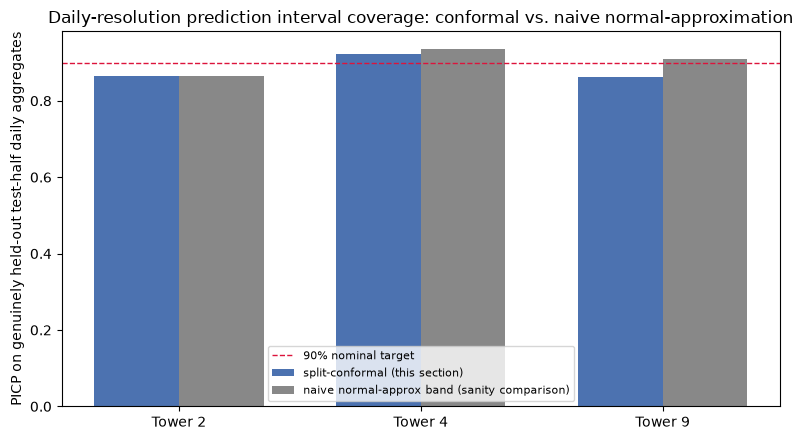

Saved _figures\daily_calibration_reliability.png


In [76]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xpos = np.arange(len(TOWERS)); width = 0.35
conformal_vals = [DAILY_CONFORMAL_SUMMARY.loc[DAILY_CONFORMAL_SUMMARY.tower == t, "PICP_test_conformal"].iloc[0] for t in TOWERS]
naive_vals = [DAILY_CONFORMAL_SUMMARY.loc[DAILY_CONFORMAL_SUMMARY.tower == t, "PICP_test_naive_normal"].iloc[0] for t in TOWERS]
ax.bar(xpos - width / 2, conformal_vals, width, label="split-conformal (this section)", color="#4C72B0")
ax.bar(xpos + width / 2, naive_vals, width, label="naive normal-approx band (sanity comparison)", color="#888888")
ax.axhline(0.90, color="crimson", ls="--", lw=1, label="90% nominal target")
ax.set_xticks(xpos); ax.set_xticklabels([f"Tower {t}" for t in TOWERS])
ax.set_ylabel("PICP on genuinely held-out test-half daily aggregates")
ax.set_title("Daily-resolution prediction interval coverage: conformal vs. naive normal-approximation")
ax.legend(fontsize=8)
plt.tight_layout()
fig_path = FIG_DIR / "daily_calibration_reliability.png"
plt.savefig(fig_path, dpi=110)
plt.show()
print(f"Saved {fig_path}")

### 26.3 Production: calibrated daily interval on the real gap-filled series

Applies the **same** per-tower margins computed from the calibration half in 26.1
(`DAILY_CONFORMAL_MARGINS`) to the already-built daily-mean production series (section 14.1's
`.resample("D").mean()` views of `FCH4_GAPFILLED`) -- mirroring section 22->23's own validation-
margin-reused-in-production pattern exactly, no separate production-only refit. Each day is also
tagged with `n_real_hours` (how many of its 24 hours are real observations), so fully-real,
fully-gap-filled, and partially-observed days are distinguishable -- the daily-resolution analogue
of section 22's `gap_run_length_h`. **Caveat carried over from section 14, restated:** for any day
with real hours present, the point estimate is not out-of-sample; the coverage claim validated in
26.1/26.2 is a statement about the *method* (verified on genuinely held-out days), not a fresh
accuracy claim about every day shown here.

In [77]:
FCH4_DAILY_INTERVALS_CAL_PARTS = []
for t in TOWERS:
    sub = FCH4_GAPFILLED[FCH4_GAPFILLED.tower == t].set_index("Datetime")
    daily_pred = sub["y_gapfilled"].resample("D").mean()
    daily_obs = sub["y_observed"].resample("D").mean()
    n_real_hours = sub["y_observed"].notna().resample("D").sum()

    margin = DAILY_CONFORMAL_MARGINS[t]
    part = pd.DataFrame({
        "tower": t,
        "y_gapfilled_daily_mean": daily_pred,
        "y_observed_daily_mean": daily_obs,
        "n_real_hours": n_real_hours,
        "daily_q05_cal": daily_pred - margin,
        "daily_q95_cal": daily_pred + margin,
    })
    part["is_fully_gapfilled_day"] = part["n_real_hours"] == 0
    FCH4_DAILY_INTERVALS_CAL_PARTS.append(part.reset_index())

FCH4_DAILY_INTERVALS_CAL = pd.concat(FCH4_DAILY_INTERVALS_CAL_PARTS, ignore_index=True)
FCH4_DAILY_INTERVALS_CAL.to_csv(DATA_DIR / "fch4_daily_gapfilled_with_intervals.csv", index=False)
print(f"Saved {DATA_DIR/'fch4_daily_gapfilled_with_intervals.csv'}  ({len(FCH4_DAILY_INTERVALS_CAL):,} rows)")

print("\nApplied per-tower conformal margins (from 26.1's calibration half):")
for t in TOWERS:
    print(f"  Tower {t}: +/-{DAILY_CONFORMAL_MARGINS[t]:.2f}")

n_fully_gf = FCH4_DAILY_INTERVALS_CAL["is_fully_gapfilled_day"].sum()
print(f"\n{n_fully_gf:,} / {len(FCH4_DAILY_INTERVALS_CAL):,} days are fully gap-filled (zero real hourly observations).")
FCH4_DAILY_INTERVALS_CAL.head()

Saved _data\fch4_daily_gapfilled_with_intervals.csv  (4,351 rows)

Applied per-tower conformal margins (from 26.1's calibration half):
  Tower 2: +/-52.36
  Tower 4: +/-80.76
  Tower 9: +/-62.34

949 / 4,351 days are fully gap-filled (zero real hourly observations).


,Datetime,tower,y_gapfilled_daily_mean,y_observed_daily_mean,n_real_hours,daily_q05_cal,daily_q95_cal,is_fully_gapfilled_day
0,2017-10-01,2,16.386483,NaN,0,-35.971571,68.744536,True
1,2017-10-02,2,13.864358,NaN,0,-38.493696,66.222411,True
2,2017-10-03,2,17.381642,NaN,0,-34.976411,69.739695,True
3,2017-10-04,2,1.372773,NaN,0,-50.985280,53.730827,True
4,2017-10-05,2,31.703169,NaN,0,-20.654884,84.061223,True


### 26.4 Figure: production daily series with the calibrated interval

Unlike the hourly production charts (sections 22/23), which zoom to a 90/180-day window for
readability, the **full domain** is shown here at daily resolution -- the same choice section 14.1
already made for its own daily-mean plot, since daily aggregation compresses a multi-year record to
a readable width.

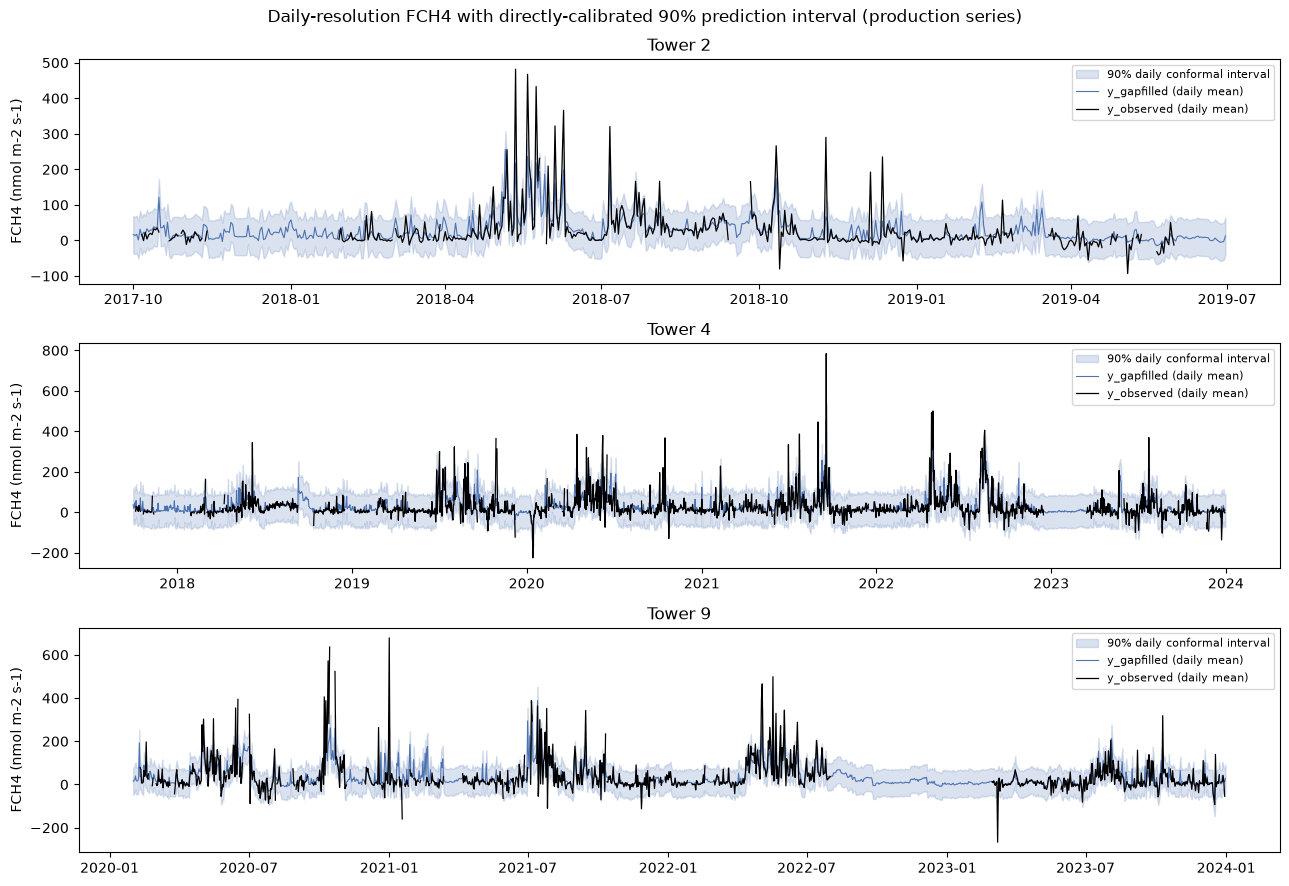

Saved _figures\daily_production_intervals.png


In [78]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
for ax, t in zip(axes, TOWERS):
    sub = FCH4_DAILY_INTERVALS_CAL[FCH4_DAILY_INTERVALS_CAL.tower == t].set_index("Datetime")
    ax.fill_between(sub.index, sub["daily_q05_cal"], sub["daily_q95_cal"], color="#4C72B0", alpha=0.2,
                     label="90% daily conformal interval")
    ax.plot(sub.index, sub["y_gapfilled_daily_mean"], color="#4C72B0", lw=0.8, label="y_gapfilled (daily mean)")
    ax.plot(sub.index, sub["y_observed_daily_mean"], color="black", lw=0.9, label="y_observed (daily mean)")
    ax.set_title(f"Tower {t}"); ax.set_ylabel("FCH4 (nmol m-2 s-1)"); ax.legend(fontsize=8, loc="upper right")
plt.suptitle("Daily-resolution FCH4 with directly-calibrated 90% prediction interval (production series)")
plt.tight_layout()
fig_path = FIG_DIR / "daily_production_intervals.png"
plt.savefig(fig_path, dpi=110)
plt.show()
print(f"Saved {fig_path}")

## 27. Daily R2, full scenario scope (extending section 13 from "l"-only to all 5 scenarios)

Section 13 computed a genuine daily R2, but restricted to the "l" (288h) scenario only, so it is
**not** directly comparable to the champion's own headline R2 (0.576/0.404/0.426), which is the
median across all 5 scenarios at hourly resolution. This section closes that gap: extends section
13's exact method (`run_rf_capture` -> `groupby(index.normalize()).mean()` -> `r2_score`) to every
scenario in `SCENARIOS`, then takes the median across scenarios the same way the champion's own
headline number is computed -- giving a true daily-resolution counterpart to 0.576/0.404/0.426,
not just the hardest-scenario slice.

**Expected to be fast**: `run_rf_capture` calls the exact same `fit()` with the exact same
`(feat, trd)` folds the champion's own `run_rf` (section 11) already used for all 5 scenarios --
essentially every RF fit needed here should already be sitting in `_model_cache/`. No new
randomness, no new methodology, purely an extension of what section 13 already validated.

**Caveat carried over from section 13's own reasoning, not resolved here**: for the shortest
scenarios (`vs`=1h, `s`=4h), a "day" may be built from just 1-4 masked hours rather than a fuller
sample -- reported as-is, with the per-scenario breakdown shown so this isn't hidden inside a
single blended number.

In [79]:
DAILY_R2_FULL_ROWS = []
DAILY_PAIRS_ALL_SCENARIOS_PARTS = []
t0 = time.time()

for t in TOWERS:
    per_scenario_daily_r2 = {}
    for sc, gh in SCENARIOS.items():
        pairs = run_rf_capture(t, pooled=True, gap_hours=gh, n_reps=N_REPS)
        if len(pairs) < 5:
            per_scenario_daily_r2[sc] = np.nan
            continue
        daily = pairs.groupby(pairs.index.normalize()).mean()
        daily_r2 = r2_score(daily["actual"], daily["pred"]) if len(daily) > 1 else np.nan
        per_scenario_daily_r2[sc] = daily_r2
        DAILY_PAIRS_ALL_SCENARIOS_PARTS.append(
            pairs.assign(tower=t, scenario=sc).reset_index().rename(columns={"index": "Datetime"})
        )

    median_daily_r2 = float(np.nanmedian(list(per_scenario_daily_r2.values())))
    row = {"tower": t, "R2_daily_median": round(median_daily_r2, 3)}
    row.update({f"R2_daily_{sc}": (round(v, 3) if pd.notna(v) else np.nan) for sc, v in per_scenario_daily_r2.items()})
    DAILY_R2_FULL_ROWS.append(row)
    print(f"Tower {t}: daily R2 median (all 5 scenarios) = {median_daily_r2:+.3f}  "
          f"[{time.time()-t0:.0f}s elapsed]")
    print(f"    per-scenario: " + ", ".join(f"{sc}={v:+.3f}" if pd.notna(v) else f"{sc}=n/a" for sc, v in per_scenario_daily_r2.items()))

DAILY_R2_FULL = pd.DataFrame(DAILY_R2_FULL_ROWS).set_index("tower")
DAILY_PAIRS_ALL_SCENARIOS = pd.concat(DAILY_PAIRS_ALL_SCENARIOS_PARTS, ignore_index=True)
DAILY_R2_FULL.to_csv(DATA_DIR / "daily_r2_full_scope.csv")
print(f"\nSaved {DATA_DIR/'daily_r2_full_scope.csv'}")
print(f"\nFor comparison -- champion hourly headline R2 (median across 5 scenarios): "
      f"T2={R.loc[(R.tower==2)&(R.model=='RFm_pool'),'R2_overall'].iloc[0]:+.3f}  "
      f"T4={R.loc[(R.tower==4)&(R.model=='RFm_pool'),'R2_overall'].iloc[0]:+.3f}  "
      f"T9={R.loc[(R.tower==9)&(R.model=='RFm_pool'),'R2_overall'].iloc[0]:+.3f}")
DAILY_R2_FULL

Tower 2: daily R2 median (all 5 scenarios) = +0.698  [5s elapsed]
    per-scenario: vs=+0.698, s=+0.805, m=+0.788, l=+0.207, m1=+0.697


Tower 4: daily R2 median (all 5 scenarios) = +0.504  [11s elapsed]
    per-scenario: vs=+0.504, s=+0.571, m=+0.359, l=+0.321, m1=+0.532


Tower 9: daily R2 median (all 5 scenarios) = +0.485  [16s elapsed]
    per-scenario: vs=+0.524, s=+0.336, m=+0.377, l=+0.504, m1=+0.485

Saved _data\daily_r2_full_scope.csv

For comparison -- champion hourly headline R2 (median across 5 scenarios): T2=+0.576  T4=+0.404  T9=+0.426


,R2_daily_median,R2_daily_vs,R2_daily_s,R2_daily_m,R2_daily_l,R2_daily_m1
tower,,,,,,
2,0.698,0.698,0.805,0.788,0.207,0.697
4,0.504,0.504,0.571,0.359,0.321,0.532
9,0.485,0.524,0.336,0.377,0.504,0.485


### 27.1 Sensitivity to daily coverage: unweighted vs. >=50% threshold vs. hour-count weighted

Section 27's `DAILY_R2_FULL` treats every day identically regardless of how many real, held-out
hours built its daily mean -- a day represented by 1 hour counts the same as a day represented by
24. This subsection checks how sensitive that number is to that choice, using the standard
FLUXNET/AmeriFlux-style completeness convention (a daily aggregate is only considered valid with
>=50% of sub-daily values present) alongside a softer, sample-size-weighted alternative
(`sklearn.metrics.r2_score`'s own `sample_weight` argument, weighting each day's contribution by
how many real hours it was built from -- no hand-rolled formula needed).

**Purely additive**: `DAILY_R2_FULL`/`daily_r2_full_scope.csv` (section 27) are left completely
untouched. This produces a *new* table, `DAILY_R2_VARIANTS`, reporting all three variants side by
side -- unweighted/unfiltered (identical to section 27's own number, reproduced here only for
direct comparison), >=50%-coverage-only, and hour-count-weighted -- plus how many days survive the
coverage threshold per scenario (expected to matter most for the shortest scenarios, `vs`/`s`,
where a single held-out block is far shorter than a day).

In [80]:
COVERAGE_THRESHOLD = 0.5  # standard FLUXNET/AmeriFlux completeness convention (>=50% of hours present)
MIN_HOURS = int(24 * COVERAGE_THRESHOLD)  # 12

daily_r2_variants_rows = []
t0 = time.time()

for t in TOWERS:
    unweighted_per_sc, hardthresh_per_sc, weighted_per_sc = {}, {}, {}
    n_days_total_per_sc, n_days_surviving_per_sc = {}, {}

    for sc, gh in SCENARIOS.items():
        pairs = run_rf_capture(t, pooled=True, gap_hours=gh, n_reps=N_REPS)
        if len(pairs) < 5:
            unweighted_per_sc[sc] = hardthresh_per_sc[sc] = weighted_per_sc[sc] = np.nan
            n_days_total_per_sc[sc] = n_days_surviving_per_sc[sc] = 0
            continue

        daily_mean = pairs.groupby(pairs.index.normalize())[["actual", "pred"]].mean()
        n_hours = pairs.groupby(pairs.index.normalize()).size()
        daily = daily_mean.join(n_hours.rename("n_hours"))
        n_days_total_per_sc[sc] = len(daily)

        # (a) unweighted, unfiltered -- identical calculation to section 27's own DAILY_R2_FULL
        unweighted_per_sc[sc] = r2_score(daily["actual"], daily["pred"]) if len(daily) > 1 else np.nan

        # (b) hard threshold -- FLUXNET/AmeriFlux-style >=50% coverage requirement
        daily_thresh = daily[daily["n_hours"] >= MIN_HOURS]
        n_days_surviving_per_sc[sc] = len(daily_thresh)
        hardthresh_per_sc[sc] = r2_score(daily_thresh["actual"], daily_thresh["pred"]) if len(daily_thresh) > 1 else np.nan

        # (c) weighted -- every day kept, weighted by how many real hours built it (sklearn's
        # own sample_weight support -- weighted SS_res / weighted SS_tot, no hand-rolled formula)
        weighted_per_sc[sc] = (r2_score(daily["actual"], daily["pred"], sample_weight=daily["n_hours"])
                                if len(daily) > 1 else np.nan)

    row = {
        "tower": t,
        "R2_unweighted_median": round(float(np.nanmedian(list(unweighted_per_sc.values()))), 3),
        "R2_hardthreshold50_median": round(float(np.nanmedian(list(hardthresh_per_sc.values()))), 3),
        "R2_weighted_median": round(float(np.nanmedian(list(weighted_per_sc.values()))), 3),
    }
    daily_r2_variants_rows.append(row)

    print(f"Tower {t}  [{time.time()-t0:.0f}s elapsed]")
    print(f"  unweighted/unfiltered : median={row['R2_unweighted_median']:+.3f}  "
          + ", ".join(f"{sc}={v:+.3f}" if pd.notna(v) else f"{sc}=n/a" for sc, v in unweighted_per_sc.items()))
    print(f"  >=50% coverage only   : median={row['R2_hardthreshold50_median']:+.3f}  "
          + ", ".join(f"{sc}={v:+.3f}" if pd.notna(v) else f"{sc}=n/a" for sc, v in hardthresh_per_sc.items()))
    print(f"  hour-count weighted   : median={row['R2_weighted_median']:+.3f}  "
          + ", ".join(f"{sc}={v:+.3f}" if pd.notna(v) else f"{sc}=n/a" for sc, v in weighted_per_sc.items()))
    print(f"  days surviving >=50% threshold per scenario: "
          + ", ".join(f"{sc}={n_days_surviving_per_sc[sc]}/{n_days_total_per_sc[sc]}" for sc in SCENARIOS))
    print()

DAILY_R2_VARIANTS = pd.DataFrame(daily_r2_variants_rows).set_index("tower")
DAILY_R2_VARIANTS.to_csv(DATA_DIR / "daily_r2_coverage_sensitivity.csv")
print(f"Saved {DATA_DIR/'daily_r2_coverage_sensitivity.csv'}")
DAILY_R2_VARIANTS

Tower 2  [5s elapsed]
  unweighted/unfiltered : median=+0.698  vs=+0.698, s=+0.805, m=+0.788, l=+0.207, m1=+0.697
  >=50% coverage only   : median=+0.638  vs=+0.568, s=+0.898, m=+0.922, l=+0.547, m1=+0.638
  hour-count weighted   : median=+0.721  vs=+0.687, s=+0.804, m=+0.842, l=+0.429, m1=+0.721
  days surviving >=50% threshold per scenario: vs=12/457, s=29/431, m=77/290, l=96/224, m1=95/258



Tower 4  [11s elapsed]
  unweighted/unfiltered : median=+0.504  vs=+0.504, s=+0.571, m=+0.359, l=+0.321, m1=+0.532
  >=50% coverage only   : median=+0.446  vs=+0.703, s=+0.315, m=+0.638, l=+0.405, m1=+0.446
  hour-count weighted   : median=+0.528  vs=+0.554, s=+0.579, m=+0.498, l=+0.398, m1=+0.528
  days surviving >=50% threshold per scenario: vs=50/1826, s=121/1707, m=285/1119, l=374/860, m1=346/1043



Tower 9  [16s elapsed]
  unweighted/unfiltered : median=+0.485  vs=+0.524, s=+0.336, m=+0.377, l=+0.504, m1=+0.485
  >=50% coverage only   : median=+0.586  vs=+0.753, s=+0.586, m=+0.661, l=+0.372, m1=+0.576
  hour-count weighted   : median=+0.498  vs=+0.575, s=+0.498, m=+0.492, l=+0.487, m1=+0.563
  days surviving >=50% threshold per scenario: vs=22/1023, s=72/967, m=180/648, l=219/490, m1=224/606

Saved _data\daily_r2_coverage_sensitivity.csv


,R2_unweighted_median,R2_hardthreshold50_median,R2_weighted_median
tower,,,
2,0.698,0.638,0.721
4,0.504,0.446,0.528
9,0.485,0.586,0.498


## 28. Summary and caveats

**What this notebook reproduced, end to end, with zero `src/` dependencies:**
1. Loaded the raw 1-hour consolidated dataset and surfaced 7 concrete data-quality issues (index integrity, target quality flags/outliers, spatial-alignment traps, Tower 4's soil-temperature undercoverage, USTAR/VPD sensor contamination, Tower 2's livestock regime shift, and FC's own gappiness) -- each tied to the fix actually implemented downstream.
2. Reconstructed a complete FCO2 (FC) feature via a met-driven Random Forest, **before** touching the FCH4 target -- FC is this project's strongest single FCH4 predictor (D-22/D-26).
3. Built the external-sourced (Site MET + per-catchment SMS) driver variant (F-08, D-35), replacing both the EC tower's SWIN/TA/WS and the old cross-tower soil-temperature proxy.
4. Gap-filled every meteorological driver (REddyProc-style: interpolate -> mean-diurnal-course -> robust fallback), with the D-48 plausibility-filter + median-fallback fix applied and validated directly (section 6.1's before/after).
5. Derived u*-threshold flags and partitioned NEE into GPP/Reco (F-06, D-33) -- GPP is a genuine productivity driver, not redundant with the rest of the feature set.
6. Built management-event recency (pruned to the two channels that survive overfitting, F-05/D-32) and livestock stocking density (this project's #1 FCH4 driver, F-01/D-27).
7. Assembled the full per-tower feature frame (11 met drivers, FC, cyclical time, LSU density, soil moisture/temperature lags, management recency, GPP/Reco, optional tower dummies for partial pooling).
8. Ran the exact full-period gap-CV harness (F-08/F-09a methodology, D-35/D-48/D-49) that produces this project's headline gap-filling result -- see section 12 for the reproduced numbers against the `BEST_RESULTS.md` target.
9. Checked whether accuracy looks different at **daily** resolution using the same held-out mechanism (section 13) -- daily aggregation of the "l"-scenario held-out pairs, still genuinely out-of-sample.
10. Fit a **final production model** on all real data (no gaps withheld) and produced a continuous per-tower gap-filled series, `FCH4_GAPFILLED` (section 14) -- the notebook's output dataframe, with hourly/daily-mean/daily-sum visualizations, clearly caveated as illustrative rather than an accuracy claim.
11. Saved the key artifacts (`FCH4_GAPFILLED`, the engineered feature matrix, the hourly and daily-resolution gap-CV results, and the raw out-of-sample held-out pairs) to `_data/` (section 14.4) for reuse outside the notebook.

**Caveats (also true of the original F-08/F-09a experiments, not new to this notebook):**
- **Full-period gap-CV is an interpolation benchmark, not a forecasting one.** Every synthetic gap has real observations on both sides available to train on -- this measures "can the model reconstruct a missing chunk given the surrounding record," which is exactly gap-filling's actual use case, but is a fundamentally easier task than genuine future forecasting (the subject of `05_benchmarking` onward).
- **MDS's window search is O(gap_size x archive_size)** and the RF grid is 150 separate fits -- this notebook is intentionally scoped to the external-sourced variant only (the winning config) to keep runtime tractable; F-08's original EC-vs-external comparison is not reproduced here (see `F08_results.md` for that side-by-side).
- **Tower 2's R2 reflects a genuinely easier discrimination task** (livestock-on vs. livestock-off, a near-binary regime) than Towers 4/9's continuous variation -- not directly comparable in difficulty despite the shared metric, a caveat already flagged at F-07 (D-34).
- **GPP/Reco partitioning and the u* threshold are pragmatic simplifications** of the full REddyProc/Papale 2006 methods (documented inline in section 7) -- adequate for feature engineering, not a substitute for canonical REddyProc if that were ever needed for a different purpose.
- Random Forest hyperparameters (`n_estimators=500, min_samples_leaf=5, random_state=42`) and the gap-CV random seeds (`seed=0` for gap placement) are fixed throughout, matching the original F-08 harness, for reproducibility.

---

## Extended exploration (this session, additive -- nothing above this line was modified)

Starting from the reproduced champion (0.576/0.404/0.426, +0.002/+0.002/+0.008 over the recorded
`BEST_RESULTS.md` numbers after a real `mdc_gapfill` bugfix -- section 6's extended-interpolation
fix for low-diurnal-structure variables, validated end-to-end), this session ran a further battery
of tests. **The champion (`RFm_pool`, section 11) was never modified and remains the standing
recommendation at every tower** -- every result below is a separately-labeled, additive comparison.

**Feature-space diagnostics (sections 15-16, not accuracy improvements):**
- **PCA/TICA** (section 15): unsupervised feature-space embeddings, useful for characterizing
  *what* the feature space looks like (dominant variance/slow-dynamics directions) and as a
  foundation for area-of-applicability UQ -- not a lever for improving R² on a tree-based model,
  and not used that way here.
- **Kalman filter demo** (section 16): applied to soil-moisture gap-filling. The initially
  striking result (beating `mdc_gapfill` badly on long gaps) turned out, on direct inspection, to
  be numerically indistinguishable from plain linear interpolation (MLE hadn't converged) -- the
  real finding is that `mdc_gapfill`'s per-hour-of-day design is a poor fit for low-diurnal-structure
  variables like soil moisture, not that Kalman filtering specifically is the fix.

**Uncertainty quantification (section 17) -- validated, ready to use:**
- Area-of-Applicability dissimilarity index (Meyer & Pebesma-style, replicated from this project's
  own `scenario_hybrid.py`), applied to the production gap-filled series. Validated against
  genuinely held-out points: **weak but real correlation with error** (Pearson +0.11 to +0.16,
  consistent positive direction at all 3 towers; flagged points show 50-80% higher mean error).

**Additional models tested (section 18) -- full 3-tower, none beat the champion outright:**

| Model | T2 | T4 | T9 | Verdict |
|---|---|---|---|---|
| LightGBM | 0.522 | **0.410** | 0.422 | Edges champion at T4 only (+0.006) |
| XGBoost | 0.551 | 0.349 | 0.369 | Loses everywhere |
| TabPFN | 0.459 | 0.401 | 0.402 | Loses everywhere; extremely slow (~3.7h for 60 folds vs. TabICL's ~2 min) |
| TabICL | 0.558 | **0.423** | 0.364 | Edges champion at T4 only (+0.019) |
| SAITS | 0.358 | 0.293 | 0.285 | Loses everywhere; F-11's own best config, substantially improved by this session's feature fix (was 0.192/0.225/0.110) but still short |
| BI-LSTM | 0.237 | 0.155 | 0.146 | Loses everywhere, weakest of all tested models |

**Lag/lead feature expansion (sections 19-20) -- both negative:**

| Experiment | T2 | T4 | T9 | Verdict |
|---|---|---|---|---|
| Soil-lag bidir | 0.561 | 0.410 | 0.415 | Reproduces F-12's null result almost exactly on corrected features |
| Soil-lag leadonly | 0.564 | 0.412 | 0.411 | Same as above |
| Target (FCH4) lag/lead | 0.495 | 0.329 | 0.353 | New (never tested before); clear regression, larger than any other variant tested |

**Overall verdict:** the RFm champion remains the best pooled gap-filling model at every tower.
TabICL and LightGBM are the only challengers that beat it anywhere, and only at Tower 4
specifically (+0.019 and +0.006 respectively) -- not enough to unseat the champion as the
project-wide recommendation. The UQ layer (section 17) is validated and additive to the existing
production pipeline. All comparison artifacts are saved to `_data/` (`model_comparison.csv`,
`soil_lag_results.csv`, `target_laglead_results.csv`) alongside the original gap-filling outputs.